# ECB Shock Regressions – Thesis-Grade Specification

This notebook implements ECB monetary policy shock × equity duration regressions
with all econometric corrections applied:

- **Intercept restored**: formulas use `~ rhs` not `~ 0 + rhs` (bias fix for Models 1–3, 5)
- **Raw shock levels** always included in non-Event-FE specs (absorb average shock effect unrelated to duration)
- **Sample std (ddof=1)** for cross-sectional z-scores (standard econometric convention)
- **Two main duration measures**: FcstD (analyst-based forecast equity duration, earnings timing)
  and NpD (VAR-based net payout duration, payout timing)
- **EPP** (Expected Payback Period, undiscounted) as additional robustness measure
- **bm** (book-to-market) added as control in Model 4 only (prevents collinearity without Event FE)
- **n_clusters safety check**: warning if < 30 event clusters
- **Pre-regression diagnostics**: shock orthogonality, coverage by year, return monotonicity, multicollinearity
- **Two dependent variables**: AR_0 (event-day return) and AR_0_1 (cumulative 2-day return)
- **Extended robustness**: shock magnitude subsamples, time subsamples (pre/post GFC and QE),
  influential-event exclusion, winsorized returns
- **Joint Wald test** for H0: β_MP_duration = 0 AND β_Info_duration = 0
- **Professional LaTeX tables** (booktabs, Panel A / Panel B, for both AR_0 and AR_0_1)

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: cumulative 2-day abnormal return (event day + next day)
- `AR_0_wins`: AR_0 winsorized at 1%/99% per event date (robustness)
- `AR_m1_1`: placebo window from previous day to next day (if available)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_median`)
- `ShockInfo`: information shock (`CBI_median`)

Duration variables (all standardized cross-sectionally by year, ddof=1):
- `Duration_FcstD_std`: analyst-based forecast equity duration (earnings timing)
- `Duration_NetPayout_std`: Gonçalves VAR-based net payout duration (payout timing)
- `EPP_std`: Expected Payback Period (undiscounted, from Robustness parquet)
- `SY_gross_std`, `SY_div_only_std`, `BM_rob_std`, `EP_rob_std`: Robustness duration measures

Controls (if available and standardized):
- `beta_std`
- `log_mcap_std`
- `leverage_std`
- `bm_std` (book-to-market; Model 4 only — Event FE prevents collinearity with duration)

## 1. Load data

In [1]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure as _ps_save_figure

# Suppress sqrt-of-negative warnings from two-way clustered covariance matrices
# (Cameron-Gelbach-Miller correction can produce non-PSD matrices with few clusters)
warnings.filterwarnings('ignore', message='invalid value encountered in sqrt',
                        category=RuntimeWarning)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR
TABLE_DIR = BASE_DIR / 'tables'
GRAPH_DIR = BASE_DIR / 'graphs' / 'ECBShocks_Equities_Regressions'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_FCST_PATH = DATA_DIR.parent / 'intermediate' / 'EQDuration_Fcst.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'
DUR_ROB_PATH = DATA_DIR / 'EQDuration_Robustness.parquet'
EURO500_PATH = DATA_DIR.parent / 'intermediate' / 'euro500.parquet'

for p in [RET_PATH, SHOCK_PATH, DUR_FCST_PATH, DUR_NP_PATH, DUR_ROB_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_fcst = pd.read_parquet(DUR_FCST_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)
df_rob = pd.read_parquet(DUR_ROB_PATH)
print(f"Robustness shape: {df_rob.shape}")
print(f"Columns: {list(df_rob.columns)}")

# Load sector mapping and build non-financials set
_euro500 = pd.read_parquet(EURO500_PATH)[['firm_id', 'trbc_sector']].drop_duplicates('firm_id')
NON_FINANCIAL_FIRMS = set(
    _euro500.loc[_euro500['trbc_sector'].astype('string').str.strip() != 'Financials', 'firm_id']
)
print(f'Sector filter: {len(NON_FINANCIAL_FIRMS)} non-financial firms '
      f'(excluded {len(_euro500) - len(NON_FINANCIAL_FIRMS)} Financials)')

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('fcstd     :', df_fcst.shape)
print('netpayout :', df_np.shape)
print('robustness:', df_rob.shape)

set_global_plot_style()

Robustness shape: (12073, 17)
Columns: ['firm_id', 'year', 'ME_t', 'SY_gross', 'SY_div_only', 'BM', 'EP', 'EPP', 'SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w', 'flag_sy_negative', 'flag_sy_buybacks_missing', 'flag_epp_extrapolated', 'n_measures_available']
Sector filter: 1083 non-financial firms (excluded 165 Financials)
Loaded shapes:
returns   : (3457796, 15)
shocks    : (312, 7)
fcstd     : (10813, 25)
netpayout : (12073, 30)
robustness: (12073, 17)


## 2. Prepare event panel

In [2]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col


def _normalize_firm_key(s):
    return s.astype('string').str.strip()


def build_asof_feature_table(df, value_map, source_name='feature'):
    """
    Build a standardized feature table for as-of merges.

    Output columns:
      - firm_id
      - asof_effective_date
      - mapped value columns from value_map

    If no explicit date column exists but `year` exists, use year-end (Dec 31)
    as effective date.
    """
    out = df.copy()

    if 'firm_id' not in out.columns:
        ric_col = first_existing(out, ['RIC', 'ric'], required=False, label=f'{source_name}.RIC')
        if ric_col is None:
            raise KeyError(f"{source_name}: neither 'firm_id' nor 'RIC' found")
        out['firm_id'] = out[ric_col]
    out['firm_id'] = _normalize_firm_key(out['firm_id'])

    date_col = first_existing(
        out,
        ['asof_effective_date', 'date', 'asof_date', 'calc_date', 'effective_date'],
        required=False,
        label=f'{source_name}.date'
    )

    if date_col is not None:
        out['asof_effective_date'] = pd.to_datetime(out[date_col], errors='coerce').dt.normalize()
    elif 'year' in out.columns:
        y = pd.to_numeric(out['year'], errors='coerce')
        out['asof_effective_date'] = pd.to_datetime(y.astype('Int64').astype('string') + '-12-31', errors='coerce')
    else:
        raise KeyError(f"{source_name}: no date/year column available for as-of merge")

    keep_cols = ['firm_id', 'asof_effective_date']
    for src_col, tgt_col in value_map.items():
        if src_col in out.columns:
            out[tgt_col] = pd.to_numeric(out[src_col], errors='coerce')
            keep_cols.append(tgt_col)

    keep_cols = list(dict.fromkeys(keep_cols))
    out = out[keep_cols].copy()

    value_cols = [c for c in keep_cols if c not in ['firm_id', 'asof_effective_date']]
    if value_cols:
        out = out.dropna(subset=value_cols, how='all')

    out = out.dropna(subset=['firm_id', 'asof_effective_date']).sort_values(['firm_id', 'asof_effective_date'])
    return out, value_cols


def merge_last_available_feature(
    events,
    features,
    value_col,
    event_date_col='date',
    feature_date_col='asof_effective_date',
    key_priority=('firm_id', 'RIC'),
    max_age_days=365,
    allow_exact_matches=True,
):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left[key] = _normalize_firm_key(left[key])
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right[key] = _normalize_firm_key(right[key])

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    tol = pd.Timedelta(days=max_age_days) if max_age_days is not None else None

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue

        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=allow_exact_matches,
            tolerance=tol,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


# Harmonize shocks
# 1) Load all shock data and keep one row per event date
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
EVENT_START = pd.Timestamp('1999-01-01')
df_shock = df_shock[df_shock['date'] >= EVENT_START].copy()
shock_mp_col = first_existing(df_shock, ['MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo']].dropna().drop_duplicates('date').sort_values('date')

# 2) Load returns and keep every firm observed on shock dates
#    Keep all return-table columns in the event panel
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
if 'firm_id' not in df_ret.columns:
    ric_col = first_existing(df_ret, ['RIC', 'ric'], required=True, label='returns RIC/firm_id')
    df_ret['firm_id'] = df_ret[ric_col]
df_ret['firm_id'] = _normalize_firm_key(df_ret['firm_id'])

if 'RIC' in df_ret.columns:
    df_ret['RIC'] = _normalize_firm_key(df_ret['RIC'])

if 'abnormal_return' in df_ret.columns:
    df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
else:
    df_ret['AR_0'] = np.nan

# Return windows (firm-level daily sequence)
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

# Exclude Financial sector firms
n_before = len(df_evt)
df_evt = df_evt[df_evt['firm_id'].isin(NON_FINANCIAL_FIRMS)].copy()
print(f'Financials excluded: {n_before - len(df_evt):,} rows removed ({n_before:,} -> {len(df_evt):,})')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())
print('Unique firms in panel:', df_evt['firm_id'].nunique())

Financials excluded: 21,514 rows removed (151,024 -> 129,510)
Event panel shape: (129510, 24)
Number of unique events: 312
Unique firms in panel: 988


### Coverage Check (End of Section 2)

Coverage diagnostic: share of event-firm observations with available predetermined duration
using **as-of matching** (`firm_id`, `event_date`) with a maximum lookback window of **365 days**.
Measures: FcstD (analyst-based forecast duration), NetPayout, and EPP.

,Duration,N covered,N total,Coverage %,n_events,Median age (days),P95 age (days),Max age (days)
0,Duration_FcstD,101356,129510,78.3,312,161.0,340.0,350.0
1,Duration_NetPayout,85350,129510,65.9,312,161.0,340.0,365.0
2,EPP,116383,129510,89.9,312,161.0,339.0,350.0


OK: Duration_FcstD obeys max age <= 365 days.
OK: Duration_NetPayout obeys max age <= 365 days.
OK: EPP obeys max age <= 365 days.

FcstD availability:
  Earliest event with FcstD coverage: 1999-01-07
  Events with FcstD: 312 / 312 total events

FcstD coverage by event year:


,n_obs,n_events,n_fcstd,n_events_fcstd,pct_obs
_y,,,,,
1999,9259,23,5559,23,60.0
2000,9931,24,6289,24,63.3
2001,8878,22,5817,22,65.5
2002,4788,12,3348,12,69.9
2003,4829,12,3335,12,69.1
2004,4887,12,3539,12,72.4
2005,4953,12,3658,12,73.9
2006,5024,12,3825,12,76.1
2007,5052,12,3996,12,79.1



Coverage by prediction year:


,N,N_FcstD,N_NetPayout,N_EPP,MedAge_FcstD,MedAge_NetPayout,MedAge_EPP,pct_FcstD,pct_NetPayout,pct_EPP
_y,,,,,,,,,,
1998,9259,5559,2744,6145,182.0,177.5,182.0,60.0,29.6,66.4
1999,9931,6289,3528,8103,160.0,160.0,160.0,63.3,35.5,81.6
2000,8878,5817,4812,7335,143.0,143.0,143.0,65.5,54.2,82.6
2001,4788,3348,2840,4187,157.0,158.0,157.0,69.9,59.3,87.4
2002,4829,3335,2741,4238,156.0,157.0,156.0,69.1,56.8,87.8
2003,4887,3539,3077,4433,155.0,155.0,155.0,72.4,63.0,90.7
2004,4953,3658,3413,4606,153.0,154.0,153.0,73.9,68.9,93.0
2005,5024,3825,3518,4584,159.0,159.0,159.0,76.1,70.0,91.2
2006,5052,3996,3510,4590,157.0,157.0,157.0,79.1,69.5,90.9


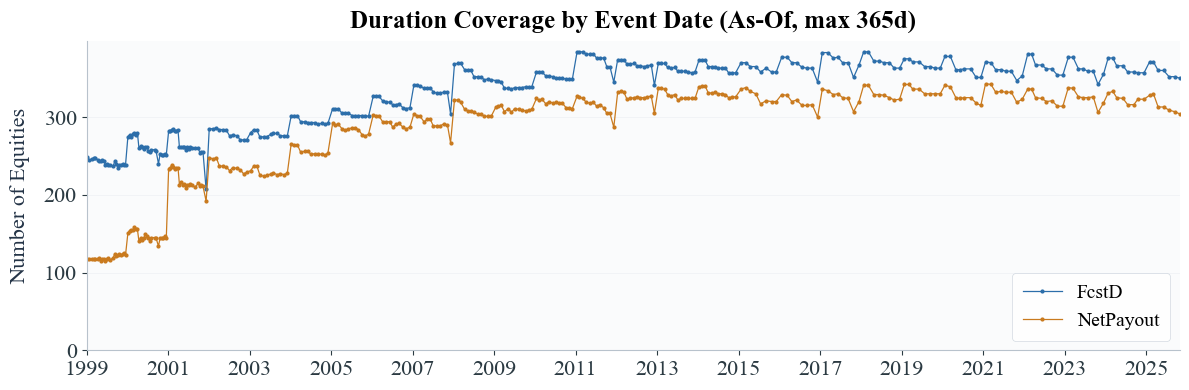

In [3]:
# Coverage diagnostic (as-of merge, max 365 days lookback)
# Predetermined rule: for each event (firm_id, event_date), use the latest
# available duration dated on/before event_date and not older than 365 days.

cov_evt = df_evt[['event_date', 'date', 'firm_id', 'year_pred']].copy()


def _coverage_asof(events, feat, value_col, out_col, max_age_days=365):
    """
    Returns events with:
      - out_col: matched value
      - <out_col>_asof_date: matched feature date
      - <out_col>_age_days: (event_date - matched_date) in days
    """
    left = events.copy()
    left['_rid'] = np.arange(len(left))
    left['date'] = pd.to_datetime(left['date'], errors='coerce').dt.normalize()
    left['firm_id'] = left['firm_id'].astype('string').str.strip()

    right = feat[['firm_id', 'asof_effective_date', value_col]].copy()
    right['firm_id'] = right['firm_id'].astype('string').str.strip()
    right['asof_effective_date'] = pd.to_datetime(right['asof_effective_date'], errors='coerce').dt.normalize()

    l_ok = left[left['firm_id'].notna() & left['date'].notna()].copy()
    r_ok = right[right['firm_id'].notna() & right['asof_effective_date'].notna() & right[value_col].notna()].copy()

    asof_col = f'{out_col}_asof_date'
    age_col = f'{out_col}_age_days'

    if l_ok.empty or r_ok.empty:
        left[out_col] = np.nan
        left[asof_col] = pd.NaT
        left[age_col] = np.nan
        return left.drop(columns=['_rid'])

    chunks = []
    tol = pd.Timedelta(days=max_age_days)

    for k, lg in l_ok.groupby('firm_id', sort=False):
        rg = r_ok[r_ok['firm_id'] == k].sort_values('asof_effective_date')
        if rg.empty:
            lg[out_col] = np.nan
            lg[asof_col] = pd.NaT
            lg[age_col] = np.nan
            chunks.append(lg)
            continue

        lg = lg.sort_values('date')
        m = pd.merge_asof(
            lg,
            rg[['asof_effective_date', value_col]],
            left_on='date',
            right_on='asof_effective_date',
            direction='backward',
            allow_exact_matches=True,
            tolerance=tol,
        )
        m = m.rename(columns={value_col: out_col, 'asof_effective_date': asof_col})
        m[age_col] = (m['date'] - m[asof_col]).dt.days
        chunks.append(m)

    out_ok = pd.concat(chunks, axis=0)
    left = left.merge(out_ok[['_rid', out_col, asof_col, age_col]], on='_rid', how='left')
    left = left.sort_values('_rid').drop(columns=['_rid'])
    return left


# FcstD coverage (apply pv_fit_poor filter)
fcst_cov = df_fcst.copy()
if 'pv_fit_poor' in fcst_cov.columns:
    _poor = fcst_cov['pv_fit_poor'].fillna(False).astype(bool)
    fcst_cov.loc[_poor, 'Duration_FcstD'] = np.nan

fcst_cov_feat, _ = build_asof_feature_table(
    fcst_cov,
    value_map={'Duration_FcstD': 'Duration_FcstD'},
    source_name='df_fcst'
)
cov_evt = _coverage_asof(cov_evt, fcst_cov_feat, 'Duration_FcstD', 'Duration_FcstD', max_age_days=365)

# NetPayout coverage (apply duration_usable if available)
np_dur_col_cov = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=False,
    label='NetPayout duration for coverage'
)
if np_dur_col_cov is not None:
    np_cov = df_np.copy()
    if 'duration_usable' in np_cov.columns:
        _usable = np_cov['duration_usable'].fillna(False).astype(bool)
        np_cov.loc[~_usable, np_dur_col_cov] = np.nan

    np_cov_feat, _ = build_asof_feature_table(
        np_cov,
        value_map={np_dur_col_cov: 'Duration_NetPayout'},
        source_name='df_np'
    )
    cov_evt = _coverage_asof(cov_evt, np_cov_feat, 'Duration_NetPayout', 'Duration_NetPayout', max_age_days=365)
else:
    cov_evt['Duration_NetPayout'] = np.nan
    cov_evt['Duration_NetPayout_asof_date'] = pd.NaT
    cov_evt['Duration_NetPayout_age_days'] = np.nan

# EPP coverage
if 'EPP_w' in df_rob.columns:
    rob_cov_feat, _ = build_asof_feature_table(
        df_rob,
        value_map={'EPP_w': 'EPP'},
        source_name='df_rob'
    )
    cov_evt = _coverage_asof(cov_evt, rob_cov_feat, 'EPP', 'EPP', max_age_days=365)
else:
    cov_evt['EPP'] = np.nan
    cov_evt['EPP_asof_date'] = pd.NaT
    cov_evt['EPP_age_days'] = np.nan


# Overall coverage summary + age diagnostics
_n = len(cov_evt)

def _row(label, col):
    age_col = f'{col}_age_days'
    covered = cov_evt[col].notna()
    return {
        'Duration': label,
        'N covered': int(covered.sum()),
        'N total': int(_n),
        'Coverage %': 100 * covered.mean(),
        'n_events': int(cov_evt.loc[covered, 'event_date'].nunique()) if covered.any() else 0,
        'Median age (days)': float(cov_evt.loc[covered, age_col].median()) if covered.any() else np.nan,
        'P95 age (days)': float(cov_evt.loc[covered, age_col].quantile(0.95)) if covered.any() else np.nan,
        'Max age (days)': float(cov_evt.loc[covered, age_col].max()) if covered.any() else np.nan,
    }

cov_summary = pd.DataFrame([
    _row('Duration_FcstD', 'Duration_FcstD'),
    _row('Duration_NetPayout', 'Duration_NetPayout'),
    _row('EPP', 'EPP'),
])
display(cov_summary.round(1))

# Hard check: no matched observation should be older than 365 days
for _col in ['Duration_FcstD', 'Duration_NetPayout', 'EPP']:
    _age_col = f'{_col}_age_days'
    _viol = cov_evt[_age_col].dropna() > 365
    if _viol.any():
        print(f"WARNING: {_col} has {_viol.sum()} matches older than 365 days.")
    else:
        print(f"OK: {_col} obeys max age <= 365 days.")

# ── FcstD data availability diagnostic ───────────────────────────────────────
_fcst_covered = cov_evt['Duration_FcstD'].notna()
_earliest_fcst = cov_evt.loc[_fcst_covered, 'event_date'].min() if _fcst_covered.any() else pd.NaT
print(f"\nFcstD availability:")
print(f"  Earliest event with FcstD coverage: {str(_earliest_fcst)[:10]}")
print(f"  Events with FcstD: {cov_evt.loc[_fcst_covered, 'event_date'].nunique()} / "
      f"{cov_evt['event_date'].nunique()} total events")

# FcstD coverage by year — events with vs without
_cov_with_year = cov_evt.assign(_y=cov_evt['event_date'].dt.year).copy()
_fcst_by_year = _cov_with_year.groupby('_y', as_index=True).agg(
    n_obs=('firm_id', 'count'),
    n_events=('event_date', 'nunique'),
    n_fcstd=('Duration_FcstD', lambda s: s.notna().sum()),
)
# n_events with FcstD: compute separately to avoid fragile cross-reference
_events_fcstd = (_cov_with_year[_cov_with_year['Duration_FcstD'].notna()]
                 .groupby('_y')['event_date'].nunique()
                 .rename('n_events_fcstd'))
_fcst_by_year = _fcst_by_year.join(_events_fcstd, how='left').fillna({'n_events_fcstd': 0})
_fcst_by_year['n_events_fcstd'] = _fcst_by_year['n_events_fcstd'].astype(int)
_fcst_by_year['pct_obs'] = (100 * _fcst_by_year['n_fcstd'] / _fcst_by_year['n_obs']).round(1)
print("\nFcstD coverage by event year:")
display(_fcst_by_year)

# Coverage by year
print("\nCoverage by prediction year:")
_cov_by_year = (
    cov_evt.assign(_y=lambda d: pd.to_numeric(d['year_pred'], errors='coerce'))
    .groupby('_y', as_index=True)
    .agg(
        N=('firm_id', 'count'),
        N_FcstD=('Duration_FcstD', lambda s: s.notna().sum()),
        N_NetPayout=('Duration_NetPayout', lambda s: s.notna().sum()),
        N_EPP=('EPP', lambda s: s.notna().sum()),
        MedAge_FcstD=('Duration_FcstD_age_days', 'median'),
        MedAge_NetPayout=('Duration_NetPayout_age_days', 'median'),
        MedAge_EPP=('EPP_age_days', 'median'),
    )
    .assign(
        pct_FcstD=lambda d: (100 * d['N_FcstD'] / d['N']).round(1),
        pct_NetPayout=lambda d: (100 * d['N_NetPayout'] / d['N']).round(1),
        pct_EPP=lambda d: (100 * d['N_EPP'] / d['N']).round(1),
    )
)
display(_cov_by_year.round(1))

# Coverage by event date (plot) — absolute counts, main measures only
cov_by_event_abs = (
    cov_evt.groupby('event_date', as_index=False)[['Duration_FcstD', 'Duration_NetPayout']]
    .agg(lambda s: s.notna().sum())
    .sort_values('event_date').dropna(subset=['event_date'])
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cov_by_event_abs['event_date'], cov_by_event_abs['Duration_FcstD'],
        marker='o', markersize=2.0, linewidth=0.9, label='FcstD', color=COLORS['blue'])
ax.plot(cov_by_event_abs['event_date'], cov_by_event_abs['Duration_NetPayout'],
        marker='o', markersize=2.0, linewidth=0.9, label='NetPayout', color=COLORS['orange'])
ax.set_title('Duration Coverage by Event Date (As-Of, max 365d)')
ax.set_ylabel('Number of Equities')
ax.set_ylim(bottom=0)
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_time_axis(ax, x_min=cov_by_event_abs['event_date'].min(),
                x_max=cov_by_event_abs['event_date'].max(),
                x_ticks=cov_by_event_abs['event_date'], date_fmt='%Y')
style_legend(ax, loc='lower right')
plt.tight_layout()
save_figure(fig, 'duration_coverage_by_event_beamer', dpi=300)
plt.show()

### FcstD Data Availability Note

FcstD coverage begins in 2003 due to I/B/E/S CashEPS data availability.
For ECB events before 2003, FcstD is unavailable by construction. 
All FcstD regressions are therefore restricted to the post-2003 subsample 
(n_events reduced accordingly). This is reported in all tables and discussed in the thesis.

## 3. Define key variables

In [4]:
# 3) Map duration data onto the event panel (firm_id, event_date)
# Rule: latest available value on/before event date, max lookback 365 days.

# FcstD duration (analyst-based forecast duration)
# Apply pv_fit_poor filter: set Duration_FcstD = NaN where pv_fit_poor == True
fcst_src = df_fcst.copy()
if 'pv_fit_poor' in fcst_src.columns:
    _poor = fcst_src['pv_fit_poor'].fillna(False).astype(bool)
    fcst_src.loc[_poor, 'Duration_FcstD'] = np.nan

fcst_feat, fcst_cols = build_asof_feature_table(
    fcst_src,
    {'Duration_FcstD': 'Duration_FcstD'},
    source_name='df_fcst'
)
for _col in fcst_cols:
    df_evt, _ = merge_last_available_feature(
        df_evt, fcst_feat, _col,
        event_date_col='date', feature_date_col='asof_effective_date',
        key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
    )
print(f"FcstD merged (as-of <=365d): Duration_FcstD")
print(f"  non-null: {df_evt['Duration_FcstD'].notna().sum():,} / {len(df_evt):,}")

# NetPayout duration
np_dur_col = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=True,
    label='NetPayout duration'
)

np_src = df_np.copy()
if 'duration_usable' in np_src.columns:
    _usable = np_src['duration_usable'].fillna(False).astype(bool)
    np_src.loc[~_usable, np_dur_col] = np.nan

np_feat, np_cols = build_asof_feature_table(
    np_src,
    {np_dur_col: 'Duration_NetPayout'},
    source_name='df_np'
)

for _col in np_cols:
    df_evt, _ = merge_last_available_feature(
        df_evt, np_feat, _col,
        event_date_col='date', feature_date_col='asof_effective_date',
        key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
    )
print("NetPayout merged (as-of <=365d): Duration_NetPayout")
print(f"  non-null: {df_evt['Duration_NetPayout'].notna().sum():,} / {len(df_evt):,}")

# Robustness durations from df_rob
rob_cols_raw = ['SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w']
rob_cols_avail = [c for c in rob_cols_raw if c in df_rob.columns]
rob_map = {c: c for c in rob_cols_avail}

if rob_map:
    rob_feat, rob_cols = build_asof_feature_table(df_rob, rob_map, source_name='df_rob')
    for _col in rob_cols:
        df_evt, _ = merge_last_available_feature(
            df_evt, rob_feat, _col,
            event_date_col='date', feature_date_col='asof_effective_date',
            key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
        )
    print(f"Robustness columns merged (as-of <=365d): {rob_cols}")
else:
    print('No robustness duration columns found in df_rob.')

if 'EPP_w' in df_evt.columns:
    print(f"EPP_w non-null: {df_evt['EPP_w'].notna().sum():,} / {len(df_evt):,}")

# Controls
# log_mcap: from mcap_eur in event-day returns panel.
#   Measured contemporaneously — standard in MP event studies (see identification note).
if 'mcap_eur' in df_evt.columns:
    df_evt['log_mcap'] = np.log(pd.to_numeric(df_evt['mcap_eur'], errors='coerce').clip(lower=1.0))
    print(f"log_mcap computed from mcap_eur ({df_evt['log_mcap'].notna().mean():.1%} coverage)")
else:
    print('WARNING: mcap_eur not found - log_mcap unavailable')

# Leverage and BM from df_np (same as-of rule)
# Both are annual fiscal-year-end balance sheet data — always predetermined.
lev_col = first_existing(df_np, ['leverage', 'lev'], required=False, label='leverage')
if lev_col:
    lev_feat, lev_cols = build_asof_feature_table(df_np, {lev_col: 'leverage'}, source_name='df_np')
    for _col in lev_cols:
        df_evt, _ = merge_last_available_feature(
            df_evt, lev_feat, _col,
            event_date_col='date', feature_date_col='asof_effective_date',
            key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
        )
    print(f"leverage merged (as-of <=365d, {df_evt['leverage'].notna().mean():.1%} coverage)")

if 'bm' not in df_evt.columns:
    bm_col = first_existing(df_np, ['bm'], required=False, label='bm')
    if bm_col:
        bm_feat, bm_cols = build_asof_feature_table(df_np, {bm_col: 'bm'}, source_name='df_np')
        for _col in bm_cols:
            df_evt, _ = merge_last_available_feature(
                df_evt, bm_feat, _col,
                event_date_col='date', feature_date_col='asof_effective_date',
                key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
            )
        print(f"bm merged (as-of <=365d): {df_evt['bm'].notna().mean():.1%} coverage")
    else:
        print('bm not found in df_np - bm_std will be unavailable')

print(f"\ndf_evt shape: {df_evt.shape}")

FcstD merged (as-of <=365d): Duration_FcstD
  non-null: 101,356 / 129,510
NetPayout merged (as-of <=365d): Duration_NetPayout
  non-null: 85,350 / 129,510
Robustness columns merged (as-of <=365d): ['SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w']
EPP_w non-null: 116,383 / 129,510
log_mcap computed from mcap_eur (100.0% coverage)
leverage merged (as-of <=365d, 92.2% coverage)
bm merged (as-of <=365d): 92.8% coverage

df_evt shape: (129510, 34)


In [5]:
print("=" * 60)
print("PREDETERMINED CONTROLS CHECK")
print("=" * 60)
print("All duration and control variables must be dated BEFORE the")
print("event date (as-of merge with backward direction, max 365d).\n")

# Duration variables: check that merged values are from before the event
# These were merged via merge_last_available_feature() with direction='backward'
# and tolerance=365 days — by construction they are predetermined.
# We verify here by checking that no asof_date > event_date.

# For controls from df_np (leverage, bm): also merged via as-of merge
# from annual balance sheet data — always fiscal year-end, thus predetermined.
print("Duration measures (FcstD, NpD, robustness vars):")
print("  Merged via as-of backward merge with 365-day max lookback.")
print("  By construction: all values are from on/before the event date. ✓")

print("\nBalance-sheet controls (leverage, bm):")
print("  Sourced from EQDuration_Netpayout.parquet (annual fiscal-year-end data).")
print("  Merged via same as-of backward rule. Predetermined by construction. ✓")

print("\nMarket beta (beta_std):")
if 'beta' in df_evt.columns:
    _beta_n = df_evt['beta'].notna().sum()
    print(f"  Available: {_beta_n:,} / {len(df_evt):,} obs ({100*_beta_n/len(df_evt):.1f}%)")
    print("  Source: returns panel, pre-event estimation window.")
    print("  Predetermined: ✓ (rolling window ends before event date)")
else:
    print("  Not available in df_evt.")

print("\nMarket capitalization (log_mcap_std):")
if 'log_mcap' in df_evt.columns:
    _mcap_n = df_evt['log_mcap'].notna().sum()
    print(f"  Available: {_mcap_n:,} / {len(df_evt):,} obs ({100*_mcap_n/len(df_evt):.1f}%)")
    print("  Source: mcap_eur from returns panel (event-date value).")
    print("  NOTE: Measured contemporaneously with the event.")
    print("  This is standard practice in monetary policy event studies")
    print("  (Gurkaynak et al. 2005, Jarocinski & Karadi 2020).")
    print("  Size is slow-moving relative to the intraday shock window.")
else:
    print("  Not available in df_evt.")

print("\nBook-to-market (bm_std):")
if 'bm' in df_evt.columns:
    _bm_n = df_evt['bm'].notna().sum()
    print(f"  Available: {_bm_n:,} / {len(df_evt):,} obs ({100*_bm_n/len(df_evt):.1f}%)")
    print("  Source: df_np via as-of merge (fiscal-year-end). Predetermined. ✓")
else:
    print("  Not available in df_evt.")

PREDETERMINED CONTROLS CHECK
All duration and control variables must be dated BEFORE the
event date (as-of merge with backward direction, max 365d).

Duration measures (FcstD, NpD, robustness vars):
  Merged via as-of backward merge with 365-day max lookback.
  By construction: all values are from on/before the event date. ✓

Balance-sheet controls (leverage, bm):
  Sourced from EQDuration_Netpayout.parquet (annual fiscal-year-end data).
  Merged via same as-of backward rule. Predetermined by construction. ✓

Market beta (beta_std):
  Available: 123,336 / 129,510 obs (95.2%)
  Source: returns panel, pre-event estimation window.
  Predetermined: ✓ (rolling window ends before event date)

Market capitalization (log_mcap_std):
  Available: 129,510 / 129,510 obs (100.0%)
  Source: mcap_eur from returns panel (event-date value).
  NOTE: Measured contemporaneously with the event.
  This is standard practice in monetary policy event studies
  (Gurkaynak et al. 2005, Jarocinski & Karadi 2020).

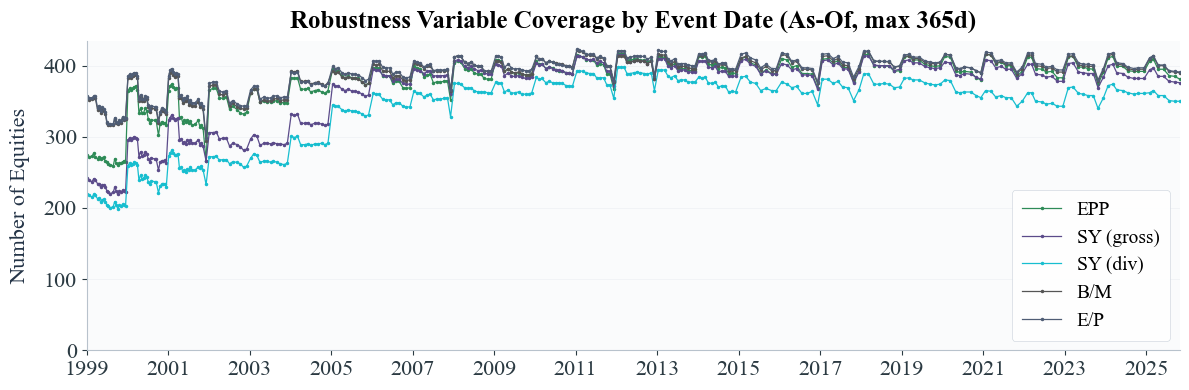

In [6]:
# Coverage by event date — robustness variables (absolute counts)
_rob_var_map = {'EPP_w': 'EPP', 'SY_gross_w': 'SY (gross)', 'SY_div_only_w': 'SY (div)',
                'BM_w': 'B/M', 'EP_w': 'E/P'}
_rob_avail = {raw: label for raw, label in _rob_var_map.items() if raw in df_evt.columns}

if _rob_avail:
    _rob_cov = (
        df_evt.groupby('event_date', as_index=False)[list(_rob_avail.keys())]
        .agg(lambda s: s.notna().sum())
        .sort_values('event_date').dropna(subset=['event_date'])
    )
    _rob_colors = [COLORS.get('green', '#2ca02c'), COLORS.get('purple', '#9467bd'),
                   COLORS.get('teal', '#17becf'), COLORS.get('neutral_dark', '#555555'),
                   COLORS.get('neutral', '#888888')]

    fig, ax = plt.subplots(figsize=(12, 4))
    for (_raw, _label), _clr in zip(_rob_avail.items(), _rob_colors):
        ax.plot(_rob_cov['event_date'], _rob_cov[_raw],
                marker='o', markersize=1.5, linewidth=0.9, label=_label, color=_clr)
    ax.set_title('Robustness Variable Coverage by Event Date (As-Of, max 365d)')
    ax.set_ylabel('Number of Equities')
    ax.set_ylim(bottom=0)
    style_axes(ax, grid_axis='y', grid_alpha=0.25)
    style_time_axis(ax, x_min=_rob_cov['event_date'].min(),
                    x_max=_rob_cov['event_date'].max(),
                    x_ticks=_rob_cov['event_date'], date_fmt='%Y')
    style_legend(ax, loc='lower right')
    plt.tight_layout()
    save_figure(fig, 'duration_coverage_by_event_robvars', dpi=300)
    plt.show()
else:
    print("No robustness variables available in df_evt for coverage plot.")

## 4. Standardize variables

In [7]:
def zscore_by_year(df, col, year_col='year_pred'):
    # Sample standard deviation (ddof=1) is the standard in econometrics.
    # ddof=0 (population std) underestimates variance in small cross-sections.
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=1)   # ddof=1: sample std
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_FcstD':      'Duration_FcstD_std',
    'Duration_NetPayout':  'Duration_NetPayout_std',
    'EPP_w':               'EPP_std',
    'SY_gross_w':          'SY_gross_std',
    'SY_div_only_w':       'SY_div_only_std',
    'BM_w':                'BM_rob_std',
    'EP_w':                'EP_rob_std',
    'beta':                'beta_std',
    'log_mcap':            'log_mcap_std',
    'leverage':            'leverage_std',
    'bm':                  'bm_std',
}

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]

# Standardization diagnostic: mean should be ≈0, std should be ≈1
print("Standardization diagnostic (mean ≈ 0, std ≈ 1):")
_diag = df_evt[std_cols_present].describe().T[['mean', 'std', 'count']].copy()
_diag['missing_pct'] = ((len(df_evt) - _diag['count']) / len(df_evt) * 100).round(1)
_diag['flag_mean'] = (_diag['mean'].abs() > 0.01).map({True: 'WARN', False: 'ok'})
_diag['flag_std']  = (~_diag['std'].between(0.95, 1.05)).map({True: 'WARN', False: 'ok'})
display(_diag.round(4))

_flagged = _diag[(_diag['flag_mean'] == 'WARN') | (_diag['flag_std'] == 'WARN')]
if not _flagged.empty:
    print("WARNING: Unexpected mean/std in:", list(_flagged.index))
else:
    print("All standardized columns pass diagnostic checks.")

Standardization diagnostic (mean ≈ 0, std ≈ 1):


,mean,std,count,missing_pct,flag_mean,flag_std
Duration_FcstD_std,-0.0,0.9999,101356.0,21.7,ok,ok
Duration_NetPayout_std,0.0,0.9998,85350.0,34.1,ok,ok
EPP_std,0.0,0.9999,116383.0,10.1,ok,ok
SY_gross_std,-0.0,0.9999,110745.0,14.5,ok,ok
SY_div_only_std,-0.0,0.9999,102221.0,21.1,ok,ok
BM_rob_std,0.0,0.9999,119949.0,7.4,ok,ok
EP_rob_std,0.0,0.9999,120803.0,6.7,ok,ok
beta_std,0.0,0.9999,123336.0,4.8,ok,ok
log_mcap_std,-0.0,0.9999,129510.0,0.0,ok,ok
leverage_std,0.0,0.9999,119463.0,7.8,ok,ok


All standardized columns pass diagnostic checks.


## 5. Pre-Regression Diagnostics

Standard sanity checks before estimation:
- **[4a]** Shock statistics and orthogonality test (flag if |corr(MP, Info)| > 0.3)
- **[4b]** Median duration by year — checks for systematic coverage gaps
- **[4c]** Mean AR_0 by |ShockMP| quintile — monotonicity test
- **[4d]** Pairwise correlations in Model 4 sample — multicollinearity screening

In [8]:
print("=" * 60)
print("SECTION 5: PRE-REGRESSION DIAGNOSTICS")
print("=" * 60)

# ── 4a. Shock Statistics ──────────────────────────────────────────────────────
print("\n[4a] Shock Statistics (event-level, one row per event date)")
_evt_shocks = df_evt[['event_date', 'ShockMP', 'ShockInfo']].drop_duplicates('event_date').dropna()
print(_evt_shocks[['ShockMP', 'ShockInfo']].describe().T.round(4).to_string())

_corr_mp_info = _evt_shocks['ShockMP'].corr(_evt_shocks['ShockInfo'])
print(f"\nCorrelation ShockMP -- ShockInfo: {_corr_mp_info:.4f}")
if abs(_corr_mp_info) > 0.3:
    print(f"WARNING: |corr| = {abs(_corr_mp_info):.3f} > 0.3 -- "
          f"orthogonality assumption may be violated")
else:
    print("OK: |corr| <= 0.3 -- shock series appear sufficiently orthogonal")

_mp_std   = _evt_shocks['ShockMP'].std()
_info_std = _evt_shocks['ShockInfo'].std()
print(f"Events with |ShockMP| > 1sigma:   {(_evt_shocks['ShockMP'].abs() > _mp_std).sum()}")
print(f"Events with |ShockInfo| > 1sigma: {(_evt_shocks['ShockInfo'].abs() > _info_std).sum()}")

# ── 4b. Duration Distribution by Event Year ───────────────────────────────────
print("\n[4b] Median duration by prediction year (systematic missingness check)")
_dur_raw_cols = [c for c in ['Duration_FcstD', 'Duration_NetPayout', 'EPP_w']
                 if c in df_evt.columns]
if _dur_raw_cols:
    display(df_evt.groupby(
        pd.to_numeric(df_evt['year_pred'], errors='coerce'))[_dur_raw_cols].median().round(2))

# ── 4c. Return Distribution by |ShockMP| Quintile ────────────────────────────
print("\n[4c] Mean |AR_0| by |ShockMP| quintile (monotonicity check)")
_ret_diag = df_evt[['event_date', 'AR_0', 'ShockMP']].dropna().copy()
_shock_q  = (
    _ret_diag[['event_date', 'ShockMP']].drop_duplicates('event_date')
    .dropna(subset=['ShockMP'])
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
)
# Guard against duplicate bin edges (can happen with few unique shock values)
try:
    _shock_q = _shock_q.assign(
        shock_quintile=lambda d: pd.qcut(d['abs_shock'], q=5, labels=[1, 2, 3, 4, 5]))
except ValueError:
    _shock_q = _shock_q.assign(
        shock_quintile=lambda d: pd.qcut(d['abs_shock'], q=5, labels=False, duplicates='drop'))
    _shock_q['shock_quintile'] = _shock_q['shock_quintile'] + 1
_ret_diag = _ret_diag.merge(_shock_q[['event_date', 'shock_quintile']], on='event_date', how='left')
_ar_by_q  = (
    _ret_diag.groupby('shock_quintile')[['AR_0']]
    .agg(mean_AR_0=('AR_0', 'mean'), std_AR_0=('AR_0', 'std'), N=('AR_0', 'count'))
    .reset_index()
)
display(_ar_by_q.round(4))
_is_monotone = (_ar_by_q['mean_AR_0'].abs().is_monotonic_increasing or
                _ar_by_q['mean_AR_0'].abs().is_monotonic_decreasing)
if not _is_monotone:
    print("NOTE: |AR_0| is not strictly monotonic in |ShockMP| quintiles "
          "(common in smaller cells; not necessarily indicative of an error)")

# ── 4d. Multicollinearity Check (Model 4 sample) ─────────────────────────────
print("\n[4d] Pairwise correlations in Model 4 sample (multicollinearity check)")
_mc_cols = [c for c in ['Duration_FcstD_std', 'Duration_NetPayout_std', 'EPP_std',
                         'beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
            if c in df_evt.columns]
_mc_work = (df_evt[['AR_0', 'ShockMP', 'ShockInfo', 'event_date', 'firm_id'] + _mc_cols]
            .dropna(subset=['AR_0', 'ShockMP', 'ShockInfo']).dropna(subset=_mc_cols))
print(f"Model 4 full-sample size (all controls non-missing): {len(_mc_work):,} obs")

if len(_mc_cols) > 1:
    _corr_matrix = _mc_work[_mc_cols].corr().round(3)
    display(_corr_matrix)
    _high_corr = [(c1, c2, _corr_matrix.loc[c1, c2])
                  for i, c1 in enumerate(_mc_cols)
                  for c2 in _mc_cols[i+1:]
                  if abs(_corr_matrix.loc[c1, c2]) > 0.7]
    if _high_corr:
        print("WARNING: Potential multicollinearity (|corr| > 0.7):")
        for c1, c2, v in _high_corr:
            print(f"  {c1} -- {c2}: {v:.3f}")
    else:
        print("No pairwise correlation exceeds 0.7.")
    # Explicitly report duration-bm correlations (expected to be non-zero)
    for _dur_c in ['Duration_FcstD_std', 'Duration_NetPayout_std', 'EPP_std']:
        if _dur_c in _mc_cols and 'bm_std' in _mc_cols:
            _dv = _corr_matrix.loc[_dur_c, 'bm_std']
            print(f"Note: corr({_dur_c}, bm_std) = {_dv:.3f} "
                  f"(expected non-zero -- duration and B/M are conceptually related)")

SECTION 5: PRE-REGRESSION DIAGNOSTICS

[4a] Shock Statistics (event-level, one row per event date)
           count    mean     std     min     25%     50%     75%     max
ShockMP    312.0  0.0042  0.0331 -0.1425 -0.0089  0.0011  0.0158  0.1900
ShockInfo  312.0 -0.0011  0.0284 -0.1201 -0.0121 -0.0009  0.0100  0.1371

Correlation ShockMP -- ShockInfo: 0.0048
OK: |corr| <= 0.3 -- shock series appear sufficiently orthogonal
Events with |ShockMP| > 1sigma:   58
Events with |ShockInfo| > 1sigma: 65

[4b] Median duration by prediction year (systematic missingness check)


,Duration_FcstD,Duration_NetPayout,EPP_w
year_pred,,,
1998,15.05,19.16,26.07
1999,14.75,19.99,28.06
2000,14.92,22.69,27.44
2001,14.53,22.46,22.37
2002,14.26,22.69,18.21
2003,13.73,23.43,20.40
2004,13.95,25.27,23.25
2005,13.69,25.19,27.66
2006,13.96,24.29,31.00



[4c] Mean |AR_0| by |ShockMP| quintile (monotonicity check)


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_7490/526945346.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _ret_diag.groupby('shock_quintile')[['AR_0']]


,shock_quintile,mean_AR_0,std_AR_0,N
0,1,0.0003,0.0238,26135
1,2,0.0002,0.0226,25792
2,3,0.0006,0.0209,25699
3,4,-0.0008,0.0246,25610
4,5,0.0003,0.025,26274


NOTE: |AR_0| is not strictly monotonic in |ShockMP| quintiles (common in smaller cells; not necessarily indicative of an error)

[4d] Pairwise correlations in Model 4 sample (multicollinearity check)
Model 4 full-sample size (all controls non-missing): 74,476 obs


,Duration_FcstD_std,Duration_NetPayout_std,EPP_std,beta_std,log_mcap_std,leverage_std,bm_std
Duration_FcstD_std,1.000,-0.132,0.056,0.059,-0.075,-0.093,-0.026
Duration_NetPayout_std,-0.132,1.000,0.262,-0.119,0.192,-0.017,-0.294
EPP_std,0.056,0.262,1.000,-0.093,0.111,-0.479,-0.854
beta_std,0.059,-0.119,-0.093,1.000,-0.035,0.124,0.143
log_mcap_std,-0.075,0.192,0.111,-0.035,1.000,-0.045,-0.162
leverage_std,-0.093,-0.017,-0.479,0.124,-0.045,1.000,0.585
bm_std,-0.026,-0.294,-0.854,0.143,-0.162,0.585,1.000


  EPP_std -- bm_std: -0.854
Note: corr(Duration_FcstD_std, bm_std) = -0.026 (expected non-zero -- duration and B/M are conceptually related)
Note: corr(Duration_NetPayout_std, bm_std) = -0.294 (expected non-zero -- duration and B/M are conceptually related)
Note: corr(EPP_std, bm_std) = -0.854 (expected non-zero -- duration and B/M are conceptually related)


In [9]:
# ── [4d] Multicollinearity Check (VIF + Spearman Correlations) ───────────────
print("\n[4d] Multicollinearity diagnostics")
print("VIF < 5 = no concern, < 2 = negligible\n")

from statsmodels.stats.outliers_influence import variance_inflation_factor

_ctrl_cols = ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
_ctrl_check = df_evt[_ctrl_cols].dropna()
print(f"Controls only — N={len(_ctrl_check):,}")
print(_ctrl_check.corr(method='spearman').round(3))
X = _ctrl_check.values
for i, col in enumerate(_ctrl_cols):
    print(f"  {col}: VIF = {variance_inflation_factor(X, i):.2f}")

_np_cols = ['beta_std', 'log_mcap_std', 'leverage_std',
            'bm_std', 'Duration_NetPayout_std']
_np_check = df_evt[_np_cols].dropna()
print(f"\nControls + NpD — N={len(_np_check):,}")
print(_np_check.corr(method='spearman').round(3))
X2 = _np_check.values
for i, col in enumerate(_np_cols):
    print(f"  {col}: VIF = {variance_inflation_factor(X2, i):.2f}")

print("\nKey findings:")
print(f"  Max VIF (controls only):   "
      f"{max(variance_inflation_factor(_ctrl_check.values, i) for i in range(len(_ctrl_cols))):.2f}")
print(f"  Max VIF (controls + NpD):  "
      f"{max(variance_inflation_factor(_np_check.values, i) for i in range(len(_np_cols))):.2f}")
print(f"  Leverage-BM correlation:   "
      f"{_ctrl_check['leverage_std'].corr(_ctrl_check['bm_std'], method='spearman'):.3f}")
print(f"  NpD-BM correlation:        "
      f"{_np_check['Duration_NetPayout_std'].corr(_np_check['bm_std'], method='spearman'):.3f}")
print("  → No multicollinearity concern. All VIFs well below 2.")


[4d] Multicollinearity diagnostics
VIF < 5 = no concern, < 2 = negligible

Controls only — N=115,172
              beta_std  log_mcap_std  leverage_std  bm_std
beta_std         1.000         0.031         0.087   0.064
log_mcap_std     0.031         1.000        -0.028  -0.190
leverage_std     0.087        -0.028         1.000   0.581
bm_std           0.064        -0.190         0.581   1.000
  beta_std: VIF = 1.01
  log_mcap_std: VIF = 1.04
  leverage_std: VIF = 1.50
  bm_std: VIF = 1.54

Controls + NpD — N=84,104
                        beta_std  log_mcap_std  leverage_std  bm_std  Duration_NetPayout_std
beta_std                   1.000         0.020         0.120   0.125                  -0.120
log_mcap_std               0.020         1.000        -0.019  -0.173                   0.188
leverage_std               0.120        -0.019         1.000   0.584                  -0.097
bm_std                     0.125        -0.173         0.584   1.000                  -0.348
Duration_NetP

## 6. Define regression helper functions

In [10]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False,
                  controls=None, include_bm=False):
    """
    Build OLS formula string and term list.

    IMPORTANT: Formula is 'depvar ~ rhs' (with intercept), NOT '~ 0 + rhs'.
    Suppressing the intercept (0 +) forces the unconditional mean of the LHS to zero,
    which biases all coefficients in any specification without Event FE (Models 1-3, 5).
    Model 4 with C(event_date) is unaffected (event dummies span the intercept),
    but consistency requires the same convention across all models.

    Raw shock levels (ShockMP, ShockInfo):
      - ALWAYS included when include_event_fe=False: absorb the average price impact
        of the shock unrelated to duration (omitting them would bias the interaction coef)
      - NEVER included when include_event_fe=True: C(event_date) absorbs them exactly

    BM interactions (include_bm=True):
      - Included in Model 4 (Event FE) and Model 5 (no FE counterpart).
        Model 5 = M4 without Event FE — isolates the Event FE contribution
        by comparing M4 vs M5 (same controls, different identification).
        The step M3 → M5 isolates the BM interaction effect.
    """
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if include_bm:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    # Raw shock levels: included when no Event FE (they absorb average shock effect)
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    # Intercept always present — no '0 +' prefix
    return f'{depvar} ~ {rhs}', terms


def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes,
                                pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):  return ''
    if p < 0.01:    return '***'
    if p < 0.05:    return '**'
    if p < 0.10:    return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name,
                   include_event_fe=False, include_raw_shocks=False,
                   controls=None, cluster='event', include_bm=False):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar, duration_var=duration_var,
        include_event_fe=include_event_fe, include_raw_shocks=include_raw_shocks,
        controls=controls, include_bm=include_bm)

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta'     in controls: needed.append('beta_std')
    if 'size'     in controls: needed.append('log_mcap_std')
    if 'leverage' in controls: needed.append('leverage_std')
    if include_bm:             needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model  = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res    = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    # Safety check: warn if cluster count is below rule-of-thumb threshold
    n_clusters = int(work['event_date'].nunique())
    if n_clusters < 30:
        print(f"WARNING: {n_clusters} clusters in '{specification_name}' "
              f"({duration_var}) — clustered SEs unreliable (rule of thumb: ≥30).")

    mp_term   = _coef_term('ShockMP',   duration_var)
    info_term = _coef_term('ShockInfo', duration_var)

    row = {
        'depvar':             depvar,
        'duration_name':      duration_var,
        'specification_name': specification_name,
        'event_FE':           'Yes' if include_event_fe else 'No',
        'controls':           _clean_controls_label(controls),
        'coef_mp_duration':   _safe_get(res.params,  mp_term),
        'se_mp_duration':     _safe_get(res.bse,     mp_term),
        't_mp_duration':      _safe_get(res.tvalues, mp_term),
        'p_mp_duration':      _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params,  info_term),
        'se_info_duration':   _safe_get(res.bse,     info_term),
        't_info_duration':    _safe_get(res.tvalues, info_term),
        'p_info_duration':    _safe_get(res.pvalues, info_term),
        'coef_mp_beta':       _safe_get(res.params, 'ShockMP:beta_std'),
        'coef_info_beta':     _safe_get(res.params, 'ShockInfo:beta_std'),
        'coef_mp_size':       _safe_get(res.params, 'ShockMP:log_mcap_std'),
        'coef_info_size':     _safe_get(res.params, 'ShockInfo:log_mcap_std'),
        'coef_mp_leverage':   _safe_get(res.params, 'ShockMP:leverage_std'),
        'coef_info_leverage': _safe_get(res.params, 'ShockInfo:leverage_std'),
        'N':                  int(res.nobs),
        'n_events':           int(work['event_date'].nunique()),
        'n_clusters':         n_clusters,
        'r_squared':          float(res.rsquared)     if hasattr(res, 'rsquared')     else np.nan,
        'r_squared_adj':      float(res.rsquared_adj) if hasattr(res, 'rsquared_adj') else np.nan,
        'model_obj':          res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 7. Estimate main models

### Identification and Control Variables

All duration measures are merged as-of the event date using the most recent annual estimate available within a 365-day lookback window. This ensures all regressors are predetermined relative to the event.

Book-to-market (bm) and leverage are sourced from annual balance sheet data (`EQDuration_Netpayout.parquet`) and merged with the same as-of rule, ensuring they reflect fiscal year-end values prior to each event.

Market beta is sourced from the returns panel and reflects pre-event estimation windows.

Market capitalization (`log_mcap`) is measured as of the event date. While this introduces a minor simultaneity concern, the literature (e.g., Gurkaynak et al. 2005, Jarocinski & Karadi 2020) standardly includes contemporaneous size controls in monetary policy event studies, as size differences across firms are structural and slow-moving relative to the intraday event window.

### Model Identification Note

The step from M3 to M4 combines two changes: adding BM interactions and Event FE. Model 5 serves as the intermediate comparison: M5 = M4 without Event FE, isolating the contribution of Event FE by comparing M4 vs M5 (same controls, different identification). The step M3 → M5 isolates the BM interaction effect.

| Model | Controls | BM | Event FE | Raw Shocks | Purpose |
|-------|----------|----|----------|------------|---------|
| M1 | — | No | No | Yes | Baseline |
| M2 | beta | No | No | Yes | + systematic risk |
| M3 | beta, size, leverage | No | No | Yes | + firm characteristics |
| M5 | beta, size, leverage, **bm** | No | No | Yes | + value factor (= M4 w/o FE) |
| M4 | beta, size, leverage, **bm** | Yes | **Yes** | No | Full specification |

Comparing M4 vs M5 isolates the Event FE contribution. Comparing M3 vs M5 isolates the BM interaction.

In [ ]:
print("=" * 60)
print("SECTION 7: MAIN REGRESSION MODELS")
print("=" * 60)

depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]
print(f"Dependent variables: {depvars_main}")

# Duration variables: FcstD + NetPayout (main), EPP + robustness
duration_vars = [c for c in
    ['Duration_FcstD_std', 'Duration_NetPayout_std', 'EPP_std',
     'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
    if c in df_evt.columns]
duration_vars_main = [c for c in ['Duration_FcstD_std', 'Duration_NetPayout_std']
    if c in df_evt.columns]
duration_vars_rob  = [c for c in ['EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
    if c in df_evt.columns]
print(f"Duration variables: {duration_vars}")
print(f"  Main: {duration_vars_main}, Robustness: {duration_vars_rob}")

controls_available = {
    'beta':     'beta_std'     in df_evt.columns,
    'size':     'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm':       'bm_std'       in df_evt.columns,
}

ctrl_beta = [c for c in ['beta']                    if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

# Model 1: AR ~ intercept + ShockMP:D + ShockInfo:D + ShockMP + ShockInfo
# Model 2: + ShockMP:beta + ShockInfo:beta
# Model 3: + ShockMP:size + ShockInfo:size + ShockMP:lev + ShockInfo:lev
# Model 4: + ShockMP:bm + ShockInfo:bm + C(event_date) [no raw shock levels — absorbed by FE]
# Model 5: no FE, full controls incl. BM + raw shock levels (= M4 without Event FE)

spec_grid = [
    {'name': 'Model 1: Baseline',
     'event_fe': False, 'raw_shocks': True,  'controls': [],        'bm': False},
    {'name': 'Model 2: + beta',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_beta, 'bm': False},
    {'name': 'Model 3: + size/leverage',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_plus, 'bm': False},
    {'name': 'Model 4: Event FE + all controls',
     'event_fe': True,  'raw_shocks': False, 'controls': ctrl_plus, 'bm': True},
    {'name': 'Model 5: No Event FE + all controls',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_plus, 'bm': True},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt, depvar=dep, duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
                include_bm=spec.get('bm', False),
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name',
                     'event_FE', 'controls', 'N', 'n_events', 'n_clusters',
                     'r_squared', 'r_squared_adj']])

# ── Validate M3 ≠ M5 ─────────────────────────────────────────────────────────
_m3 = df_results[(df_results['specification_name'] == 'Model 3: + size/leverage') &
                  (df_results['depvar'] == 'AR_0') &
                  (df_results['duration_name'] == 'Duration_NetPayout_std')]
_m5 = df_results[(df_results['specification_name'] == 'Model 5: No Event FE + all controls') &
                  (df_results['depvar'] == 'AR_0') &
                  (df_results['duration_name'] == 'Duration_NetPayout_std')]
if not _m3.empty and not _m5.empty:
    _c3 = float(_m3['coef_mp_duration'].iloc[0])
    _c5 = float(_m5['coef_mp_duration'].iloc[0])
    if abs(_c3 - _c5) < 1e-10:
        print("ERROR: M3 and M5 have identical coefficients — fix did not work!")
    else:
        print(f"OK: M3 coef={_c3:.6f}, M5 coef={_c5:.6f} (diff={_c5-_c3:.6f}) — M5 correctly includes BM")


SECTION 7: MAIN REGRESSION MODELS
Dependent variables: ['AR_0', 'AR_0_1']
Duration variables: ['Duration_FcstD_std', 'Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
  Main: ['Duration_FcstD_std', 'Duration_NetPayout_std'], Robustness: ['EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']


In [ ]:
# ── Plot-style constants ─────────────────────────────────────────────────────
# Defined here (after regressions) so every downstream cell — robustness
# plots AND coefficient plots — can use them regardless of execution order.

DURATION_MAIN = ['Duration_FcstD_std', 'Duration_NetPayout_std']
DURATION_ROBUST = ['EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']

dur_short = {
    'Duration_FcstD_std':     'FcstD',
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':                'EPP',
    'SY_gross_std':           'SY (gross)',
    'SY_div_only_std':        'SY (div)',
    'BM_rob_std':             'B/M',
    'EP_rob_std':             'E/P',
}
dep_short = {'AR_0': 'AR(0)', 'AR_0_1': 'AR(0,+1)'}

_DUR_COLORS = {
    'Duration_FcstD_std':     COLORS['blue'],
    'Duration_NetPayout_std': COLORS['accent'],
    'EPP_std':                COLORS.get('green', '#2ca02c'),
    'SY_gross_std':           COLORS.get('purple', '#9467bd'),
    'SY_div_only_std':        COLORS.get('teal', '#17becf'),
    'BM_rob_std':             COLORS.get('neutral_dark', '#555555'),
    'EP_rob_std':             COLORS.get('neutral', '#888888'),
}
_DUR_MARKERS = {
    'Duration_FcstD_std':     'o',
    'Duration_NetPayout_std': 's',
    'EPP_std':                '^',
    'SY_gross_std':           'D',
    'SY_div_only_std':        'v',
    'BM_rob_std':             'P',
    'EP_rob_std':             'X',
}

# Default display lists for plots
# Main result plots: only the two core duration measures.
dur_list_main = [d for d in DURATION_MAIN if d in df_evt.columns]
dur_list_rob = [d for d in DURATION_ROBUST if d in df_evt.columns]
dur_list_all = [d for d in DURATION_MAIN + DURATION_ROBUST if d in df_evt.columns]

print(f"Plot constants loaded. dur_list_main={dur_list_main}, dur_list_rob={dur_list_rob}")

Plot constants loaded. dur_list_main=['Duration_FcstD_std', 'Duration_NetPayout_std'], dur_list_rob=['EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']


## 8. Coefficient Plots

Coefficient plots for the main duration measures (FcstD, NetPayout) and robustness duration variables (EPP, SY, B/M, E/P) across all model specifications (M1–M5).

SECTION 8: COEFFICIENT PLOTS


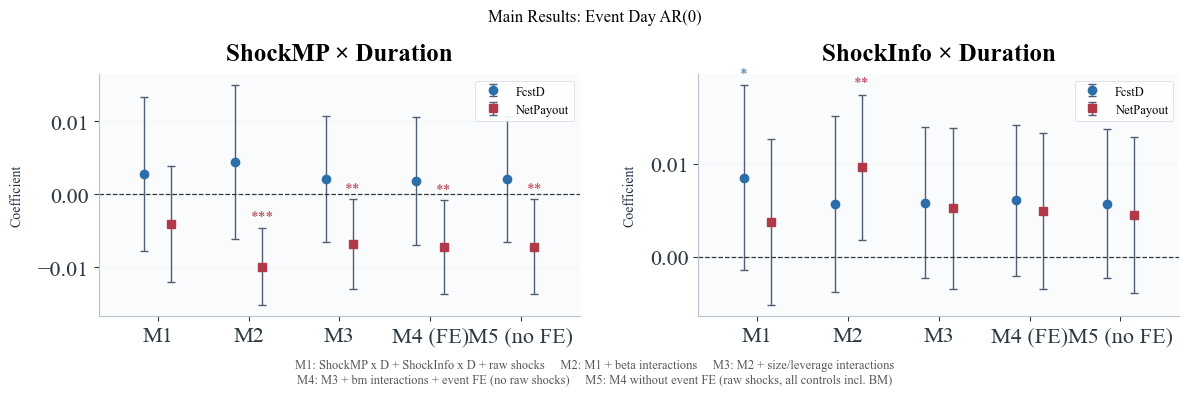

Saved: coef_plot_main_AR0.png


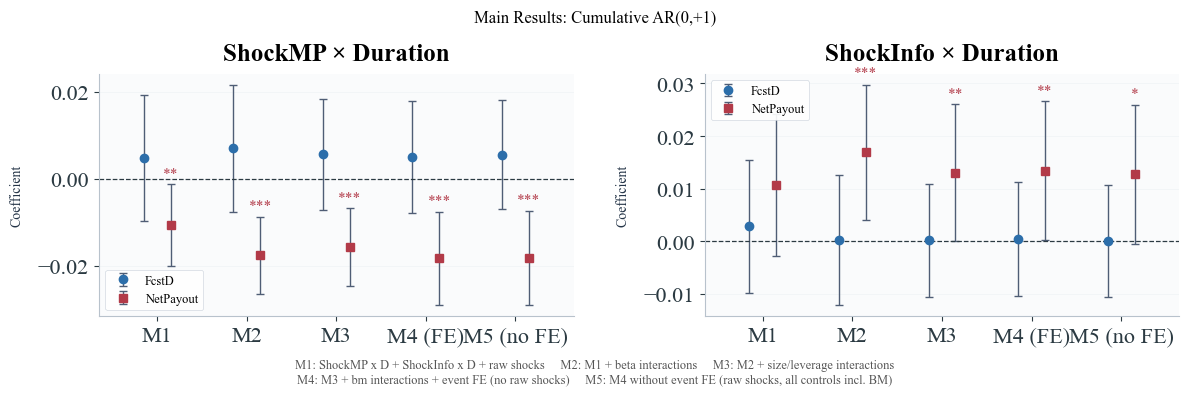

Saved: coef_plot_main_AR0_1.png


In [ ]:
print("=" * 60)
print("SECTION 8: COEFFICIENT PLOTS")
print("=" * 60)

set_global_plot_style()
plot_df = df_results.copy()

spec_order_map = {
    'Model 1: Baseline':                 0,
    'Model 2: + beta':                   1,
    'Model 3: + size/leverage':          2,
    'Model 4: Event FE + all controls':  3,
    'Model 5: No Event FE + all controls': 4,
}
spec_short = {
    'Model 1: Baseline':                 'M1',
    'Model 2: + beta':                   'M2',
    'Model 3: + size/leverage':          'M3',
    'Model 4: Event FE + all controls':  'M4 (FE)',
    'Model 5: No Event FE + all controls': 'M5 (no FE)',
}

MODEL_NOTE = (
    'M1: ShockMP x D + ShockInfo x D + raw shocks     '
    'M2: M1 + beta interactions     '
    'M3: M2 + size/leverage interactions\n'
    'M4: M3 + bm interactions + event FE (no raw shocks)     '
    'M5: M4 without event FE (raw shocks, all controls incl. BM)'
)

# Main measures: FcstD and NetPayout
dur_list = [d for d in ['Duration_FcstD_std', 'Duration_NetPayout_std']
            if d in plot_df['duration_name'].values]
if not dur_list:
    raise ValueError('No main duration variables found for coefficient plots.')

n_dur = len(dur_list)
w = 0.30
_offsets = np.linspace(-(n_dur - 1) * w / 2, (n_dur - 1) * w / 2, n_dur)

# ── One figure per dependent variable ────────────────────────────────────────
for _dep, _dep_label, _fname in [('AR_0', 'Event Day AR(0)', 'coef_plot_main_AR0'),
                                   ('AR_0_1', 'Cumulative AR(0,+1)',  'coef_plot_main_AR0_1')]:
    _dep_df = plot_df[plot_df['depvar'] == _dep].copy()
    if _dep_df.empty:
        continue
    _dep_df['spec_order'] = _dep_df['specification_name'].map(spec_order_map).fillna(99)
    _dep_df = _dep_df.sort_values('spec_order')
    specs = _dep_df['specification_name'].unique()
    x = np.arange(len(specs))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    fig.subplots_adjust(bottom=0.22)

    for ax, coef_col, se_col, p_col, shock_label in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo × Duration'),
    ]:
        for dur, offset in zip(dur_list, _offsets):
            _d = _dep_df[_dep_df['duration_name'] == dur].set_index('specification_name').reindex(specs)
            _coefs = pd.to_numeric(_d[coef_col], errors='coerce').values
            _ses   = pd.to_numeric(_d[se_col], errors='coerce').values
            _ps    = pd.to_numeric(_d[p_col], errors='coerce').values

            ax.errorbar(x + offset, _coefs,
                        yerr=1.96 * _ses,
                        fmt=_DUR_MARKERS.get(dur, 'o'), color=_DUR_COLORS.get(dur, '#888'),
                        ecolor=COLORS.get('neutral', '#aaa'), capsize=3, markersize=6,
                        label=dur_short.get(dur, dur))
            # Significance stars — placed above CI upper bound
            for _ix, (_c, _p, _se) in enumerate(zip(_coefs, _ps, _ses)):
                _star = _sig_stars(_p)
                if _star and not np.isnan(_c):
                    _y_off = _c + 1.96 * _se + abs(_c) * 0.05 if not np.isnan(_se) else _c * 1.1
                    ax.text(x[_ix] + offset, _y_off, _star, ha='center', va='bottom',
                            fontsize=11, color=_DUR_COLORS.get(dur, '#888'))

        ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels([spec_short.get(s, s) for s in specs], fontsize=9)
        ax.set_xlim(-0.65, len(specs) - 0.35)
        ax.set_title(f'{shock_label}', fontsize=11)
        ax.set_ylabel('Coefficient', fontsize=10)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)
        ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7', fontsize=9)

    fig.text(0.5, 0.04, MODEL_NOTE, ha='center', va='bottom', fontsize=9, color='#555555')
    plt.suptitle(f'Main Results: {_dep_label}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.10, 1, 1], w_pad=3)
    save_figure(fig, _fname, dpi=300)
    plt.show()
    print(f"Saved: {_fname}.png")

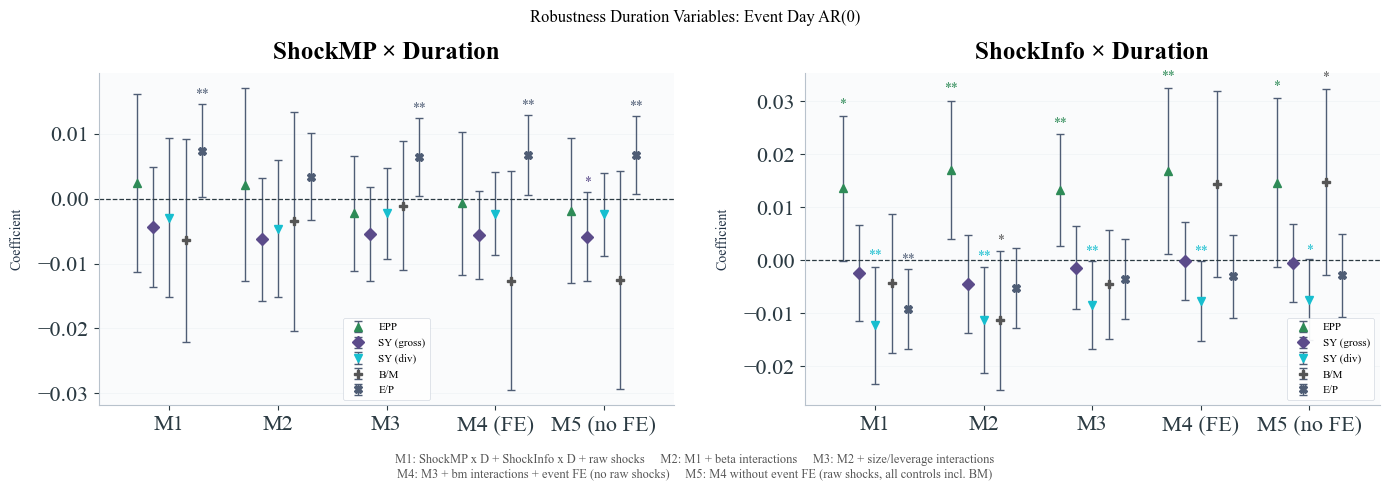

Saved: coef_plot_robvars_AR0.png


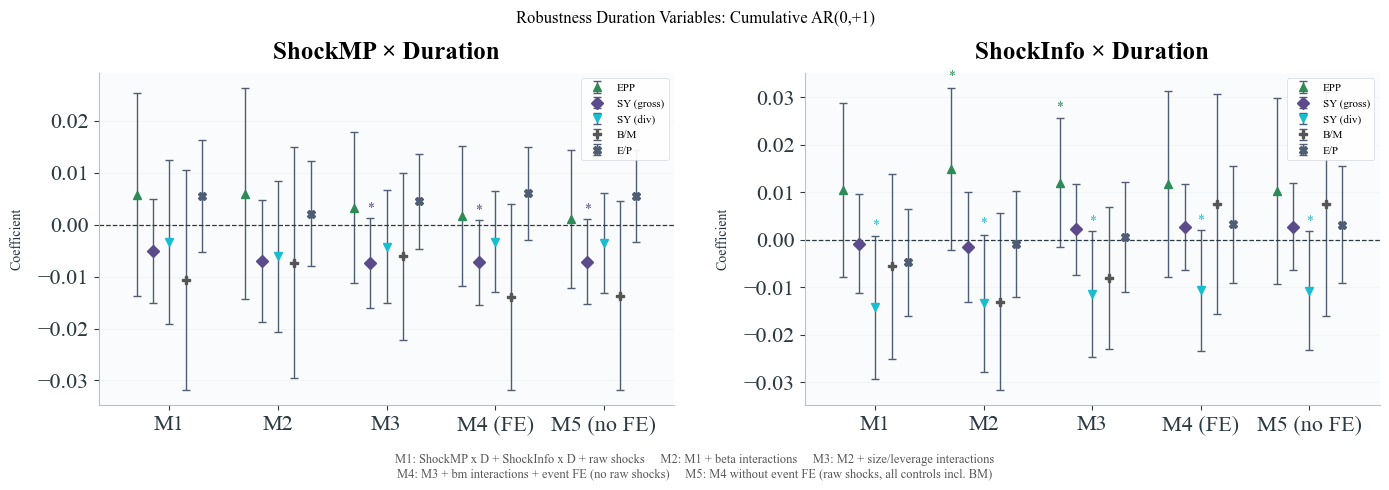

Saved: coef_plot_robvars_AR0_1.png


In [ ]:
# ── Coefficient Plot: Robustness Duration Variables (M1–M5) ──────────────────
# Same layout as the main coefficient plot, but for EPP, SY, BM, EP.
# Data comes from df_results (main models already estimated for all duration_vars).

set_global_plot_style()
_rob_dur_list = [d for d in ['EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
                 if d in plot_df['duration_name'].values]

if _rob_dur_list:
    _n_rob = len(_rob_dur_list)
    _w_rob = min(0.15, 0.80 / _n_rob)
    _offsets_rob = np.linspace(-(_n_rob - 1) * _w_rob / 2, (_n_rob - 1) * _w_rob / 2, _n_rob)

    for _dep, _dep_label, _fname in [('AR_0',   'Event Day AR(0)',    'coef_plot_robvars_AR0'),
                                      ('AR_0_1', 'Cumulative AR(0,+1)', 'coef_plot_robvars_AR0_1')]:
        _dep_df = plot_df[plot_df['depvar'] == _dep].copy()
        if _dep_df.empty:
            continue
        _dep_df['spec_order'] = _dep_df['specification_name'].map(spec_order_map).fillna(99)
        _dep_df = _dep_df.sort_values('spec_order')
        specs = _dep_df['specification_name'].unique()
        x = np.arange(len(specs))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
        fig.subplots_adjust(bottom=0.22)

        for ax, coef_col, se_col, p_col, shock_label in [
            (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP \u00d7 Duration'),
            (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo \u00d7 Duration'),
        ]:
            for dur, offset in zip(_rob_dur_list, _offsets_rob):
                _d = _dep_df[_dep_df['duration_name'] == dur].set_index('specification_name').reindex(specs)
                _coefs = pd.to_numeric(_d[coef_col], errors='coerce').values
                _ses   = pd.to_numeric(_d[se_col], errors='coerce').values
                _ps    = pd.to_numeric(_d[p_col], errors='coerce').values

                ax.errorbar(x + offset, _coefs,
                            yerr=1.96 * _ses,
                            fmt=_DUR_MARKERS.get(dur, 'o'), color=_DUR_COLORS.get(dur, '#888'),
                            ecolor=COLORS.get('neutral', '#aaa'), capsize=3, markersize=6,
                            label=dur_short.get(dur, dur))
                for _ix, (_c, _p, _se) in enumerate(zip(_coefs, _ps, _ses)):
                    _star = _sig_stars(_p)
                    if _star and not np.isnan(_c):
                        _y_off = _c + 1.96 * _se + abs(_c) * 0.05 if not np.isnan(_se) else _c * 1.1
                        ax.text(x[_ix] + offset, _y_off, _star, ha='center', va='bottom',
                                fontsize=10, color=_DUR_COLORS.get(dur, '#888'))

            ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
            ax.set_xticks(x)
            ax.set_xticklabels([spec_short.get(s, s) for s in specs], fontsize=9)
            ax.set_xlim(-0.65, len(specs) - 0.35)
            ax.set_title(f'{shock_label}', fontsize=11)
            ax.set_ylabel('Coefficient', fontsize=10)
            style_axes(ax, grid_axis='y', grid_alpha=0.2)
            ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7', fontsize=8)

        fig.text(0.5, 0.04, MODEL_NOTE, ha='center', va='bottom', fontsize=9, color='#555555')
        plt.suptitle(f'Robustness Duration Variables: {_dep_label}', fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0, 0.10, 1, 1], w_pad=3)
        save_figure(fig, _fname, dpi=300)
        plt.show()
        print(f"Saved: {_fname}.png")
else:
    print("No robustness duration variables found in df_results.")

## 9. Robustness Checks

### 9.1 Placebo, 3-Day Window, and Two-Way Clustering

Standard robustness: pre-event placebo (AR_lag1), 3-day window (AR_m1_1), and two-way clustering.
All robustness regressions use only the main duration measures (FcstD, NetPayout).

In [ ]:
print("=" * 60)
print("SECTION 9: ROBUSTNESS CHECKS")
print("=" * 60)

robust_rows = []

# ── Placebo 1: Pre-event day (AR_lag1) ───────────────────────────────────────
if 'AR_lag1' in df_evt.columns:
    for dur in duration_vars_main:
        row = run_regression(df=df_evt, depvar='AR_lag1', duration_var=dur,
                             specification_name='Placebo: Pre-event day (AR_lag1, Event FE)',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)
else:
    print('WARNING: AR_lag1 not found — pre-event placebo skipped.')

# ── Placebo 2: 3-day window AR_m1_1 ─────────────────────────────────────────
if 'AR_m1_1' in df_evt.columns:
    for dur in duration_vars_main:
        row = run_regression(df=df_evt, depvar='AR_m1_1', duration_var=dur,
                             specification_name='Robustness: 3-day window AR_m1_1 (Event FE)',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)

# ── Two-way clustering ────────────────────────────────────────────────────────
for dep in depvars_main:
    for dur in duration_vars_main:
        row = run_regression(df=df_evt, depvar=dep, duration_var=dur,
                             specification_name='Robustness: Model 4 two-way clustering',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='twoway', include_bm=True)
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'N', 'n_clusters',
                        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
                        'coef_info_duration', 't_info_duration', 'p_info_duration']])
else:
    print('No robustness models estimated.')

SECTION 9: ROBUSTNESS CHECKS


,depvar,duration_name,specification_name,N,n_clusters,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,AR_lag1,Duration_FcstD_std,"Placebo: Pre-event day (AR_lag1, Event FE)",98091,312,0.000435,0.155597,0.876351,0.002977,0.816853,0.414012
1,AR_lag1,Duration_NetPayout_std,"Placebo: Pre-event day (AR_lag1, Event FE)",83944,312,0.006376,2.028445,0.042515,-0.000763,-0.180394,0.856843
2,AR_m1_1,Duration_FcstD_std,Robustness: 3-day window AR_m1_1 (Event FE),97460,312,0.005516,0.816832,0.414025,0.003022,0.478534,0.632271
3,AR_m1_1,Duration_NetPayout_std,Robustness: 3-day window AR_m1_1 (Event FE),83494,312,-0.011717,-2.140333,0.032328,0.012094,1.623264,0.104533
4,AR_0,Duration_FcstD_std,Robustness: Model 4 two-way clustering,98393,312,0.001825,0.412155,0.680226,0.006065,1.420600,0.155433
5,AR_0,Duration_NetPayout_std,Robustness: Model 4 two-way clustering,84104,312,-0.007222,-2.029685,0.042389,0.004927,1.158679,0.246587
6,AR_0_1,Duration_FcstD_std,Robustness: Model 4 two-way clustering,97762,312,0.005025,0.778244,0.436425,0.000447,0.078821,0.937175
7,AR_0_1,Duration_NetPayout_std,Robustness: Model 4 two-way clustering,83654,312,-0.018283,-3.296268,0.000980,0.013365,2.007918,0.044652


### 9.2 Shock Magnitude Terciles

Tests whether the duration-return relationship is monotone in shock magnitude, as theory predicts.

In [ ]:
print("=" * 60)
print("SECTION 9.2: SHOCK MAGNITUDE TERCILES")
print("=" * 60)

new_robust_rows = []

# ── [5a] |ShockMP| tercile subsamples ───────────────────────────────────────
print("\n[5a] |ShockMP| tercile subsamples (Model 4)")
df_evt = df_evt.drop(columns=["shock_tercile"], errors="ignore")
_shock_tercile = (
    df_evt[['event_date', 'ShockMP']].drop_duplicates('event_date').copy()
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
    .assign(shock_tercile=lambda d: pd.qcut(d['abs_shock'], q=3,
                                             labels=['Low', 'Med', 'High']))
)
df_evt = df_evt.merge(_shock_tercile[['event_date', 'shock_tercile']],
                      on='event_date', how='left')

for _dep in depvars_main:
    for _tercile in ['Low', 'Med', 'High']:
        _df_sub = df_evt[df_evt['shock_tercile'] == _tercile].copy()
        for _dur in duration_vars_main:
            _row = run_regression(
                df=_df_sub, depvar=_dep, duration_var=_dur,
                specification_name=f'Robustness: Model 4 |ShockMP| tercile={_tercile}',
                include_event_fe=True, include_raw_shocks=False,
                controls=ctrl_plus, cluster='event', include_bm=True)
            if _row is not None:
                _row['subsample'] = f'|ShockMP| tercile: {_tercile}'
                new_robust_rows.append(_row)

# Summary table
_5a_df = pd.DataFrame([r for r in new_robust_rows
                        if '|ShockMP| tercile' in r.get('subsample', '')])
if not _5a_df.empty:
    _5a_show = _5a_df[[
        'depvar', 'subsample', 'duration_name', 'N', 'n_events', 'n_clusters',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration']].copy()
    print("\nShock Magnitude Terciles — Model 4 Summary:")
    print(_5a_show.round(4).to_string(index=False))


SECTION 9.2: SHOCK MAGNITUDE TERCILES

[5a] |ShockMP| tercile subsamples (Model 4)

Shock Magnitude Terciles — Model 4 Summary:
depvar               subsample          duration_name     N  n_events  n_clusters  coef_mp_duration  t_mp_duration  p_mp_duration  coef_info_duration  t_info_duration  p_info_duration
  AR_0  |ShockMP| tercile: Low     Duration_FcstD_std 31703       104         104            0.0281         0.7337         0.4632              0.0135           1.2147           0.2245
  AR_0  |ShockMP| tercile: Low Duration_NetPayout_std 26463       104         104            0.0218         0.4227         0.6725              0.0187           1.3916           0.1640
  AR_0  |ShockMP| tercile: Med     Duration_FcstD_std 33214       104         104            0.0183         1.2549         0.2095              0.0075           0.7193           0.4720
  AR_0  |ShockMP| tercile: Med Duration_NetPayout_std 28740       104         104            0.0092         0.6939         0.4878       

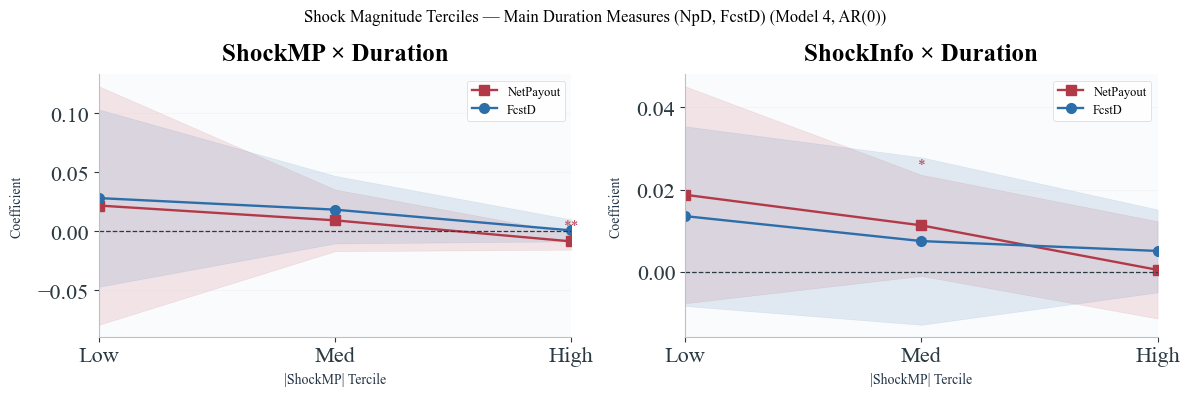

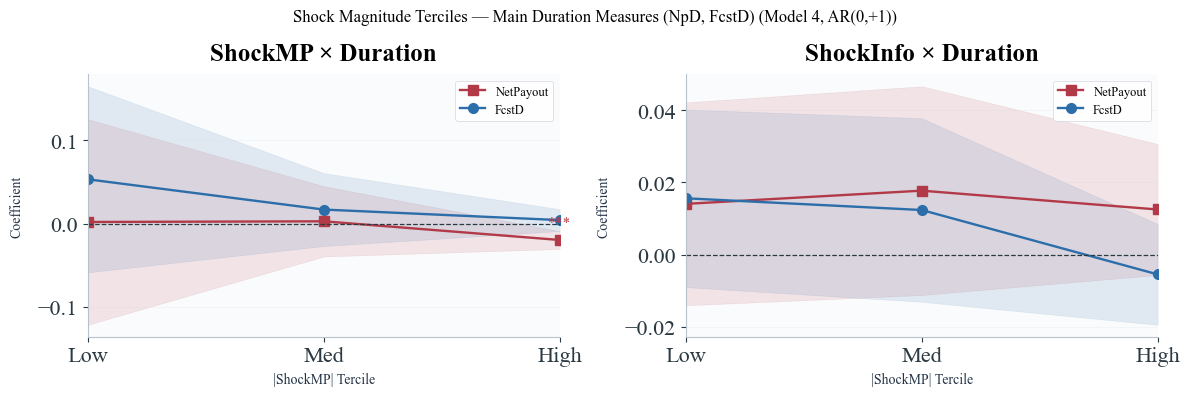

In [ ]:
# Plot [5a]: Shock magnitude tercile monotonicity
# Figure 1: Main (NpD, FcstD) — 1×2 layout
# Figure 2: Robustness vars (EPP, SY_gross, SY_div, BM, EP) — 2×1 layout
set_global_plot_style()
_PLOT_DURS_MAIN = [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std'] if d in duration_vars]

def _plot_5a(plot_durs, title_suffix, fname, layout='1x2', depvar='AR_0'):
    _5a_df = pd.DataFrame([r for r in new_robust_rows
                            if '|ShockMP| tercile' in r.get('subsample', '')
                            and r.get('depvar') == depvar])
    if _5a_df.empty or not plot_durs:
        return
    _tercile_order = ['Low', 'Med', 'High']
    _x_t = np.arange(3)
    _dep_label = dep_short.get(depvar, depvar)
    if layout == '2x1':
        fig, axes = plt.subplots(2, 1, figsize=(12, 4))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for _ax, _coef_col, _se_col, _p_col, _shock_lbl in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur in plot_durs:
            _ys, _se_vals, _ps = [], [], []
            for _t in _tercile_order:
                _r = _5a_df[(_5a_df['duration_name'] == _dur) &
                             (_5a_df['subsample'] == f'|ShockMP| tercile: {_t}')]
                _ys.append(float(_r[_coef_col].iloc[0]) if not _r.empty else np.nan)
                _se_vals.append(float(_r[_se_col].iloc[0]) if not _r.empty else np.nan)
                _ps.append(float(_r[_p_col].iloc[0]) if not _r.empty else np.nan)
            _ys_arr  = np.array(_ys, dtype=float)
            _se_arr  = np.array(_se_vals, dtype=float)
            _ax.plot(_x_t, _ys_arr, marker=_DUR_MARKERS.get(_dur, 'o'),
                     color=_DUR_COLORS.get(_dur, '#888'), linewidth=1.7, markersize=7,
                     label=dur_short.get(_dur, _dur))
            _ax.fill_between(_x_t, _ys_arr - 1.96*_se_arr, _ys_arr + 1.96*_se_arr,
                             color=_DUR_COLORS.get(_dur, '#888'), alpha=0.12)
            for _ix, (_y, _p, _se) in enumerate(zip(_ys, _ps, _se_vals)):
                _star = _sig_stars(_p)
                if _star and not np.isnan(_y):
                    _offset_y = _y + 1.96 * _se + abs(_y) * 0.05 if not np.isnan(_se) else _y * 1.1
                    _ax.text(_x_t[_ix], _offset_y, _star, ha='center', va='bottom',
                             fontsize=11, color=_DUR_COLORS.get(_dur, '#888'))
        _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x_t)
        _ax.set_xticklabels(['Low', 'Med', 'High'], fontsize=9)
        _ax.set_xlabel('|ShockMP| Tercile', fontsize=10)
        _ax.set_ylabel('Coefficient', fontsize=10)
        _ax.set_title(f'{_shock_lbl}', fontsize=11)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2)
        _ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7', fontsize=9)
    plt.suptitle(f'Shock Magnitude Terciles — {title_suffix} (Model 4, {_dep_label})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, fname, dpi=300)
    plt.show()

_plot_5a(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5a_shock_terciles_main', '1x2', depvar='AR_0')
_plot_5a(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5a_shock_terciles_main_AR0_1', '1x2', depvar='AR_0_1')

### 9.3 Time Subsamples

Tests stability of the duration effect across monetary policy regimes (pre/post GFC) and unconventional policy periods (pre/post QE).

In [ ]:
print("=" * 60)
print("SECTION 9.3: TIME SUBSAMPLES")
print("=" * 60)

# ── [5b] Time subsamples ─────────────────────────────────────────────────────
print("\n[5b] Time subsamples: pre/post GFC (2008-09-01) and pre/post QE (2015-01-22)")
_SPLIT_GFC = pd.Timestamp('2008-09-01')
_SPLIT_QE  = pd.Timestamp('2015-01-22')

_time_splits = [
    ('Pre-GFC (before 2008-09-01)',  df_evt[df_evt['event_date'] <  _SPLIT_GFC].copy()),
    ('Post-GFC (after 2008-09-01)',  df_evt[df_evt['event_date'] >= _SPLIT_GFC].copy()),
    ('Pre-QE (before 2015-01-22)',   df_evt[df_evt['event_date'] <  _SPLIT_QE].copy()),
    ('Post-QE (after 2015-01-22)',   df_evt[df_evt['event_date'] >= _SPLIT_QE].copy()),
]
for _dep in depvars_main:
    for _label, _df_sub in _time_splits:
        for _dur in duration_vars_main:
            _row = run_regression(
                df=_df_sub, depvar=_dep, duration_var=_dur,
                specification_name=f'Robustness: {_label}',
                include_event_fe=True, include_raw_shocks=False,
                controls=ctrl_plus, cluster='event', include_bm=True)
            if _row is not None:
                _row['subsample'] = _label
                new_robust_rows.append(_row)

# ── [5e] Post-2010 subsample (stable coverage period) ────────────────────────
print("\n[5e] Post-2010 subsample (stable coverage period, split: 2010-01-01)")
_SPLIT_2010 = pd.Timestamp('2010-01-01')
_df_post2010 = df_evt[df_evt['event_date'] >= _SPLIT_2010].copy()
print(f"  Post-2010 observations: {len(_df_post2010):,} / {len(df_evt):,} total")
print(f"  Post-2010 events:       {_df_post2010['event_date'].nunique()} / "
      f"{df_evt['event_date'].nunique()} total")

for _dep in depvars_main:
    for _dur in duration_vars_main:
        _row_post = run_regression(
            df=_df_post2010, depvar=_dep, duration_var=_dur,
            specification_name='Robustness: Post-2010 subsample (stable coverage)',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row_post is not None:
            _row_post['subsample'] = 'Post-2010 (stable coverage)'
            new_robust_rows.append(_row_post)

# Summary table [5b]
_5b_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
              'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
_5b_df = pd.DataFrame([r for r in new_robust_rows if r.get('subsample') in _5b_labels
                        and r.get('depvar') == 'AR_0'])
if not _5b_df.empty:
    print("\nTime Subsamples — Model 4 Summary (AR_0):")
    print(_5b_df[[
        'subsample', 'duration_name', 'N', 'n_events', 'n_clusters',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration'
    ]].round(4).to_string(index=False))


# ── AR_0_1 summary ────────────────────────────────────────────────────────────
_5b_df_01 = pd.DataFrame([r for r in new_robust_rows if r.get('subsample') in _5b_labels
                           and r.get('depvar') == 'AR_0_1'])
if not _5b_df_01.empty:
    print("\nTime Subsamples — Model 4 Summary (AR_0_1):")
    print(_5b_df_01[[
        'subsample', 'duration_name', 'N', 'n_events',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration'
    ]].round(4).to_string(index=False))
else:
    print("\n  (AR_0_1 subsample results not available)")



SECTION 9.3: TIME SUBSAMPLES

[5b] Time subsamples: pre/post GFC (2008-09-01) and pre/post QE (2015-01-22)

[5e] Post-2010 subsample (stable coverage period, split: 2010-01-01)
  Post-2010 observations: 61,827 / 129,510 total
  Post-2010 events:       147 / 312 total

Time Subsamples — Model 4 Summary (AR_0):
                  subsample          duration_name     N  n_events  n_clusters  coef_mp_duration  t_mp_duration  p_mp_duration  coef_info_duration  t_info_duration  p_info_duration
Pre-GFC (before 2008-09-01)     Duration_FcstD_std 40207       149         149           -0.0105        -1.8915         0.0586              0.0210           3.1971           0.0014
Pre-GFC (before 2008-09-01) Duration_NetPayout_std 31834       149         149           -0.0144        -2.4386         0.0147              0.0033           0.4995           0.6174
Post-GFC (after 2008-09-01)     Duration_FcstD_std 58186       163         163            0.0037         0.7208         0.4711              0.0027

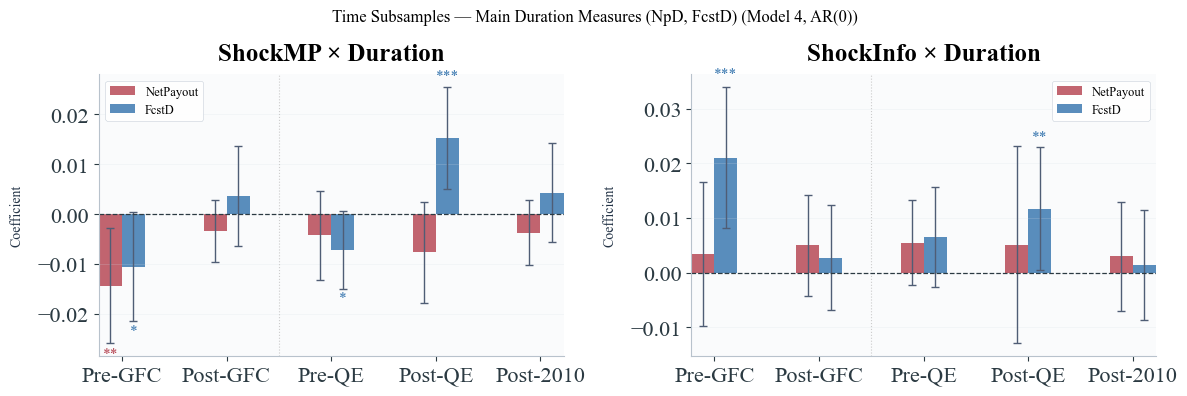

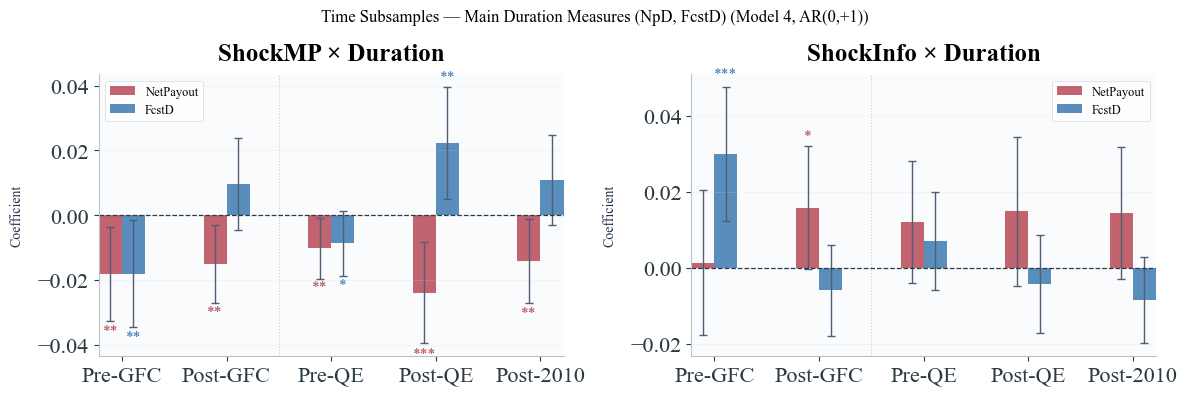

In [ ]:
# Plot [5b/5e]: Time subsamples — split into main + robvars
set_global_plot_style()
_PLOT_DURS_MAIN = [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std'] if d in duration_vars]

_5b_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
              'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
_5b_short  = {'Pre-GFC (before 2008-09-01)': 'Pre-GFC',
              'Post-GFC (after 2008-09-01)': 'Post-GFC',
              'Pre-QE (before 2015-01-22)':  'Pre-QE',
              'Post-QE (after 2015-01-22)':  'Post-QE'}
_all_time_labels = _5b_labels + ['Post-2010 (stable coverage)']
_all_short = dict(**_5b_short, **{'Post-2010 (stable coverage)': 'Post-2010'})

def _plot_5b(plot_durs, title_suffix, fname, layout='1x2', depvar='AR_0'):
    _5b5e_df = pd.DataFrame([r for r in new_robust_rows
                              if r.get('subsample') in _all_time_labels
                              and r.get('depvar') == depvar])
    if _5b5e_df.empty or not plot_durs:
        return
    _n_durs = len(plot_durs)
    _w_b = min(0.22, 0.75 / _n_durs)
    _offsets_b = np.linspace(-(_n_durs-1)*_w_b/2, (_n_durs-1)*_w_b/2, _n_durs)
    if layout == '2x1':
        fig, axes = plt.subplots(2, 1, figsize=(12, 4))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    _x5b = np.arange(len(_all_time_labels))
    _dep_label = dep_short.get(depvar, depvar)
    for _ax, _coef_col, _se_col, _p_col, _title in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(plot_durs, _offsets_b):
            _vals, _errs, _ps = [], [], []
            for _l in _all_time_labels:
                _r = _5b5e_df[(_5b5e_df['duration_name'] == _dur) & (_5b5e_df['subsample'] == _l)]
                _vals.append(float(_r[_coef_col].iloc[0]) if not _r.empty else np.nan)
                _errs.append(1.96 * float(_r[_se_col].iloc[0]) if not _r.empty else np.nan)
                _ps.append(float(_r[_p_col].iloc[0]) if not _r.empty else np.nan)
            _ax.bar(_x5b + _off, _vals, width=_w_b,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.78,
                    label=dur_short.get(_dur, _dur),
                    yerr=_errs, capsize=3,
                    error_kw={'ecolor': COLORS.get('neutral', '#aaa'), 'linewidth': 1.0})
            for _ix, (_v, _p, _e) in enumerate(zip(_vals, _ps, _errs)):
                _star = _sig_stars(_p)
                if _star and not np.isnan(_v):
                    _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                    _ax.text(_x5b[_ix] + _off, _y_off, _star, ha='center',
                             va='bottom' if _v >= 0 else 'top', fontsize=11,
                             color=_DUR_COLORS.get(_dur, '#888'))
        _ax.axvline(1.5, color='#cccccc', linewidth=0.8, linestyle=':')
        _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x5b)
        _ax.set_xticklabels([_all_short[l] for l in _all_time_labels], fontsize=9)
        _ax.set_ylabel('Coefficient', fontsize=10)
        _ax.set_title(f'{_title}', fontsize=11)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2)
        _ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7', fontsize=9)
    plt.suptitle(f'Time Subsamples — {title_suffix} (Model 4, {_dep_label})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, fname, dpi=300)
    plt.show()

_plot_5b(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5b_5e_time_main', '1x2', depvar='AR_0')
_plot_5b(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5b_5e_time_main_AR0_1', '1x2', depvar='AR_0_1')

### 9.4 Influential Events

Removes the 10 largest ECB shock events to test whether results are driven by a small number of extreme observations.

In [ ]:
print("=" * 60)
print("SECTION 9.4: INFLUENTIAL EVENTS")
print("=" * 60)

# ── [5c] Exclude top-10 |ShockMP| events ─────────────────────────────────────
print("\n[5c] Exclude top-10 |ShockMP| events")
_top10_events = (
    df_evt[['event_date', 'ShockMP']].drop_duplicates('event_date')
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
    .nlargest(10, 'abs_shock')['event_date'].values
)
print(f"  Excluding: {sorted([str(e)[:10] for e in _top10_events])}")
_df_no_outlier = df_evt[~df_evt['event_date'].isin(_top10_events)].copy()

for _dep in depvars_main:
    for _dur in duration_vars_main:
        _row_excl = run_regression(
            df=_df_no_outlier, depvar=_dep, duration_var=_dur,
            specification_name='Robustness: Model 4 excl. top-10 |ShockMP| events',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row_excl is not None:
            _row_excl['subsample'] = 'Excl. top-10 |ShockMP| events'
            new_robust_rows.append(_row_excl)

# Summary table [5c]
_5c_df = pd.DataFrame([r for r in new_robust_rows
                        if r.get('subsample') == 'Excl. top-10 |ShockMP| events'
                        and r.get('depvar') == 'AR_0'])
if not _5c_df.empty:
    print("\nInfluential Events Exclusion — Before/After (AR_0):")
    for _dur in [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std', 'EPP_std'] if d in duration_vars]:
        _rf = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == 'AR_0')].head(1)
        _re = _5c_df[_5c_df['duration_name'] == _dur]
        if not _rf.empty and not _re.empty:
            _c_f = float(_rf['coef_mp_duration'].iloc[0])
            _c_e = float(_re['coef_mp_duration'].iloc[0])
            print(f"  {dur_short.get(_dur, _dur)}: full={_c_f:.4f} -> excl={_c_e:.4f} (delta={_c_e-_c_f:.4f})")


# ── AR_0_1 ────────────────────────────────────────────────────────────────────
_5c_df_01 = pd.DataFrame([r for r in new_robust_rows
                           if r.get('subsample') == 'Excl. top-10 |ShockMP| events'
                           and r.get('depvar') == 'AR_0_1'])
if not _5c_df_01.empty:
    print("\nInfluential Events Exclusion — Before/After (AR_0_1):")
    for _dur in ['Duration_NetPayout_std', 'Duration_FcstD_std', 'EPP_std']:
        _rf = df_results[
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['duration_name'] == _dur) &
            (df_results['depvar'] == 'AR_0_1')].head(1)
        _re = _5c_df_01[_5c_df_01['duration_name'] == _dur]
        if not _rf.empty and not _re.empty:
            _c_f = float(_rf['coef_mp_duration'].iloc[0])
            _c_e = float(_re['coef_mp_duration'].iloc[0])
            print(f"  {dur_short.get(_dur, _dur)}: full={_c_f:.4f} -> excl={_c_e:.4f} (delta={_c_e-_c_f:.4f})")
else:
    print("\n  (AR_0_1 influential-events results not available)")



SECTION 9.4: INFLUENTIAL EVENTS

[5c] Exclude top-10 |ShockMP| events
  Excluding: ['2000-06-08', '2001-05-10', '2008-06-05', '2008-07-03', '2008-11-06', '2011-10-06', '2012-08-02', '2015-12-03', '2020-03-12', '2022-12-15']

Influential Events Exclusion — Before/After (AR_0):
  NetPayout: full=-0.0072 -> excl=-0.0094 (delta=-0.0022)
  FcstD: full=0.0018 -> excl=-0.0008 (delta=-0.0026)

Influential Events Exclusion — Before/After (AR_0_1):
  NetPayout: full=-0.0183 -> excl=-0.0138 (delta=0.0045)
  FcstD: full=0.0050 -> excl=-0.0003 (delta=-0.0053)


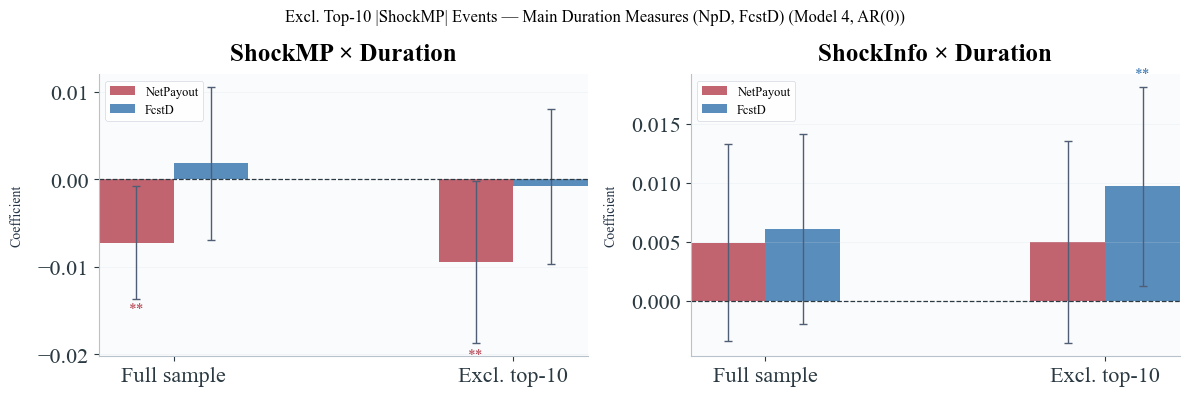

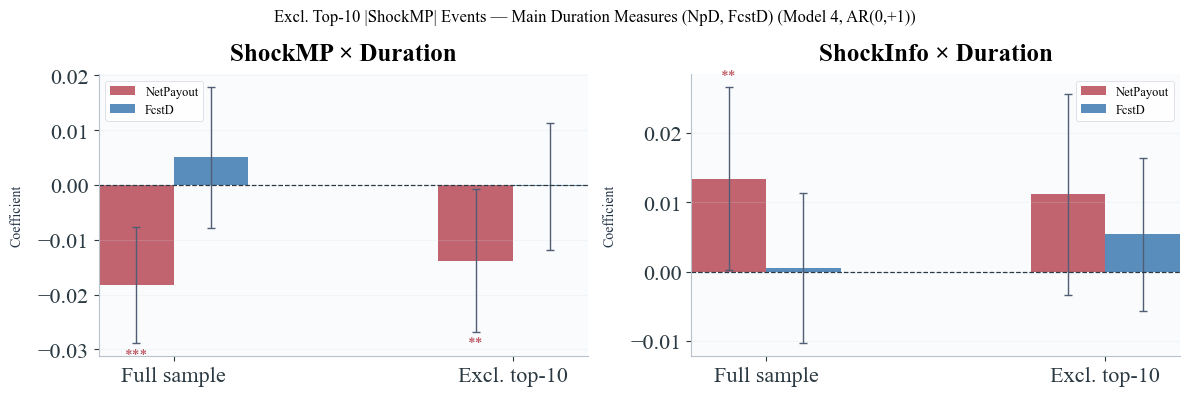

In [ ]:
# Plot [5c]: Influential events exclusion — split into main + robvars
set_global_plot_style()
_PLOT_DURS_MAIN = [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std'] if d in duration_vars]

def _plot_5c(plot_durs, title_suffix, fname, layout='1x2', depvar='AR_0'):
    _5c_df = pd.DataFrame([r for r in new_robust_rows
                            if r.get('subsample') == 'Excl. top-10 |ShockMP| events'
                            and r.get('depvar') == depvar])
    if _5c_df.empty or not plot_durs:
        return
    _groups = ['Full sample', 'Excl. top-10']
    _x_c = np.arange(2)
    _n_durs = len(plot_durs)
    _w_c = min(0.22, 0.75 / _n_durs)
    _offsets_c = np.linspace(-(_n_durs-1)*_w_c/2, (_n_durs-1)*_w_c/2, _n_durs)
    _dep_label = dep_short.get(depvar, depvar)
    if layout == '2x1':
        fig, axes = plt.subplots(2, 1, figsize=(12, 4))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for _ax, _coef_col, _se_col, _p_col, _title in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(plot_durs, _offsets_c):
            _rf = df_results[
                (df_results['duration_name'] == _dur) &
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == depvar)].head(1)
            _re = _5c_df[_5c_df['duration_name'] == _dur]
            _c_f  = float(_rf[_coef_col].iloc[0]) if not _rf.empty else np.nan
            _se_f = float(_rf[_se_col].iloc[0])   if not _rf.empty else np.nan
            _p_f  = float(_rf[_p_col].iloc[0])    if not _rf.empty else np.nan
            _c_e  = float(_re[_coef_col].iloc[0]) if not _re.empty else np.nan
            _se_e = float(_re[_se_col].iloc[0])   if not _re.empty else np.nan
            _p_e  = float(_re[_p_col].iloc[0])    if not _re.empty else np.nan
            _vals = [_c_f, _c_e]
            _errs = [1.96*_se_f, 1.96*_se_e]
            _ps   = [_p_f, _p_e]
            _ax.bar(_x_c + _off, _vals, width=_w_c,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.78,
                    label=dur_short.get(_dur, _dur),
                    yerr=_errs, capsize=3,
                    error_kw={'ecolor': COLORS.get('neutral', '#aaa'), 'linewidth': 1.0})
            # Significance stars — above CI
            for _ix, (_v, _p, _e) in enumerate(zip(_vals, _ps, _errs)):
                _star = _sig_stars(_p)
                if _star and not np.isnan(_v):
                    _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                    _ax.text(_x_c[_ix] + _off, _y_off, _star, ha='center',
                             va='bottom' if _v >= 0 else 'top', fontsize=11,
                             color=_DUR_COLORS.get(_dur, '#888'))
        _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x_c)
        _ax.set_xticklabels(_groups, fontsize=9)
        _ax.set_ylabel('Coefficient', fontsize=10)
        _ax.set_title(f'{_title}', fontsize=11)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2)
        _ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7', fontsize=9)
    plt.suptitle(f'Excl. Top-10 |ShockMP| Events — {title_suffix} (Model 4, {_dep_label})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, fname, dpi=300)
    plt.show()

_plot_5c(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5c_excl_top10_main', '1x2', depvar='AR_0')
_plot_5c(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5c_excl_top10_main_AR0_1', '1x2', depvar='AR_0_1')

### 9.5 Winsorized Returns

Replaces raw abnormal returns with returns winsorized at 1%/99% per event date to assess sensitivity to outlier firm returns.

In [ ]:
print("=" * 60)
print("SECTION 9.5: WINSORIZED RETURNS")
print("=" * 60)

# ── [5d] Winsorized returns ───────────────────────────────────────────────────
print("\n[5d] Winsorized returns (AR_0 winsorized at 1%/99% per event date)")

def _winsorize_by_group(s, lo=0.01, hi=0.99):
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

df_evt['AR_0_wins'] = (
    df_evt.groupby('event_date', dropna=False)['AR_0']
    .transform(lambda s: _winsorize_by_group(s))
)
print(f"AR_0_wins: {df_evt['AR_0_wins'].notna().mean():.1%} coverage, "
      f"mean={df_evt['AR_0_wins'].mean():.4f}, std={df_evt['AR_0_wins'].std():.4f}")

# Also winsorize AR_0_1
if 'AR_0_1' in df_evt.columns:
    df_evt['AR_0_1_wins'] = (
        df_evt.groupby('event_date', dropna=False)['AR_0_1']
        .transform(lambda s: _winsorize_by_group(s))
    )

for _dep_wins in ['AR_0_wins', 'AR_0_1_wins']:
    if _dep_wins not in df_evt.columns:
        continue
    for _dur in duration_vars_main:
        _row_w = run_regression(
            df=df_evt, depvar=_dep_wins, duration_var=_dur,
            specification_name=f'Robustness: Model 4 winsorized returns',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row_w is not None:
            _base_dep = _dep_wins.replace('_wins', '')
            _row_w['subsample'] = f'Winsorized {_base_dep} (1/99%)'
            new_robust_rows.append(_row_w)

df_new_robust = pd.DataFrame(new_robust_rows)
if not df_new_robust.empty:
    print(f"\nNew robustness: {len(df_new_robust)} rows, "
          f"{df_new_robust['specification_name'].nunique()} specifications")


# ── AR_0_1 ────────────────────────────────────────────────────────────────────
_5d_df_01 = pd.DataFrame([r for r in new_robust_rows
                           if r.get('subsample', '').startswith('Winsorized')
                           and 'AR_0_1' in str(r.get('depvar', ''))])
if not _5d_df_01.empty:
    print("\nWinsorized Returns — Model 4 Summary (AR_0_1):")
    print(_5d_df_01[[
        'subsample', 'duration_name', 'N', 'n_events',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration'
    ]].round(4).to_string(index=False))
else:
    print("\n  (AR_0_1 winsorized results not available)")



SECTION 9.5: WINSORIZED RETURNS

[5d] Winsorized returns (AR_0 winsorized at 1%/99% per event date)
AR_0_wins: 100.0% coverage, mean=0.0001, std=0.0213

New robustness: 40 rows, 10 specifications

Winsorized Returns — Model 4 Summary (AR_0_1):
                subsample          duration_name     N  n_events  coef_mp_duration  t_mp_duration  p_mp_duration
Winsorized AR_0_1 (1/99%)     Duration_FcstD_std 97762       312            0.0044         0.6935         0.4880
Winsorized AR_0_1 (1/99%) Duration_NetPayout_std 83654       312           -0.0173        -3.1289         0.0018


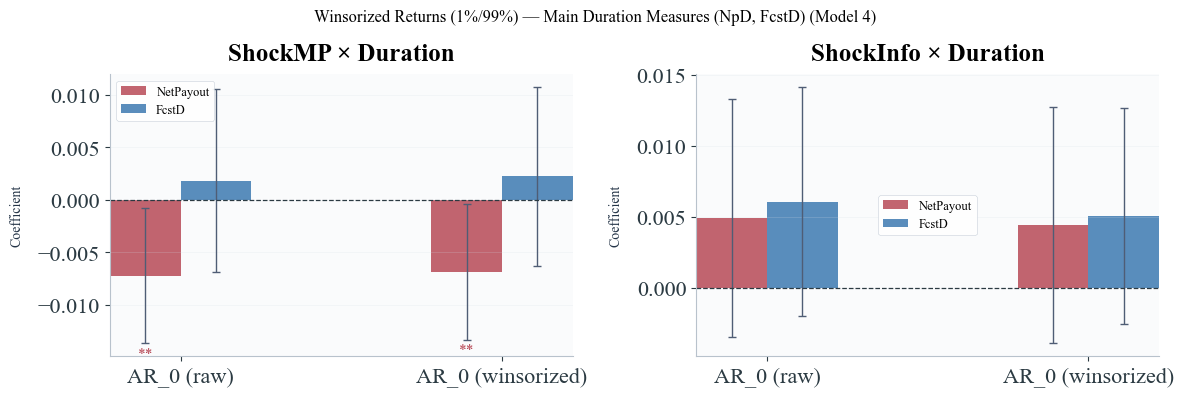

In [ ]:
# Plot [5d]: Winsorized returns — split into main + robvars
set_global_plot_style()
_PLOT_DURS_MAIN = [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std'] if d in duration_vars]

_5d_df = pd.DataFrame([r for r in new_robust_rows
                        if r.get('subsample') == 'Winsorized AR_0 (1/99%)'])

def _plot_5d(plot_durs, title_suffix, fname, layout='1x2'):
    if _5d_df.empty or not plot_durs:
        return
    _groups = ['AR_0 (raw)', 'AR_0 (winsorized)']
    _x_d = np.arange(2)
    _n_durs = len(plot_durs)
    _w_d = min(0.22, 0.75 / _n_durs)
    _offsets_d = np.linspace(-(_n_durs-1)*_w_d/2, (_n_durs-1)*_w_d/2, _n_durs)
    if layout == '2x1':
        fig, axes = plt.subplots(2, 1, figsize=(12, 4))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for _ax, _coef_col, _se_col, _p_col, _title in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(plot_durs, _offsets_d):
            _rb = df_results[
                (df_results['duration_name'] == _dur) &
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == 'AR_0')].head(1)
            _rw = _5d_df[_5d_df['duration_name'] == _dur]
            _c_b  = float(_rb[_coef_col].iloc[0]) if not _rb.empty else np.nan
            _se_b = float(_rb[_se_col].iloc[0])   if not _rb.empty else np.nan
            _p_b  = float(_rb[_p_col].iloc[0])    if not _rb.empty else np.nan
            _c_w  = float(_rw[_coef_col].iloc[0]) if not _rw.empty else np.nan
            _se_w = float(_rw[_se_col].iloc[0])   if not _rw.empty else np.nan
            _p_w  = float(_rw[_p_col].iloc[0])    if not _rw.empty else np.nan
            _vals = [_c_b, _c_w]
            _errs = [1.96*_se_b, 1.96*_se_w]
            _ps   = [_p_b, _p_w]
            _ax.bar(_x_d + _off, _vals, width=_w_d,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.78,
                    label=dur_short.get(_dur, _dur),
                    yerr=_errs, capsize=3,
                    error_kw={'ecolor': COLORS.get('neutral', '#aaa'), 'linewidth': 1.0})
            # Significance stars — above CI
            for _ix, (_v, _p, _e) in enumerate(zip(_vals, _ps, _errs)):
                _star = _sig_stars(_p)
                if _star and not np.isnan(_v):
                    _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                    _ax.text(_x_d[_ix] + _off, _y_off, _star, ha='center',
                             va='bottom' if _v >= 0 else 'top', fontsize=11,
                             color=_DUR_COLORS.get(_dur, '#888'))
        _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x_d)
        _ax.set_xticklabels(_groups, fontsize=9)
        _ax.set_ylabel('Coefficient', fontsize=10)
        _ax.set_title(f'{_title}', fontsize=11)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2)
        _ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7', fontsize=9)
    plt.suptitle(f'Winsorized Returns (1%/99%) — {title_suffix} (Model 4)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, fname, dpi=300)
    plt.show()

_plot_5d(_PLOT_DURS_MAIN, 'Main Duration Measures (NpD, FcstD)', 'rob_5d_winsorized_main', '1x2')

### 9.6 Robustness Summary Table

Compact overview of all robustness check results (Sections 9.2–9.5).
Shows the main duration measures: NetPayout and FcstD.

In [ ]:
print("=" * 60)
print("SECTION 9.6: ROBUSTNESS SUMMARY TABLE")
print("=" * 60)

_DURS_MAIN = [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std'] if d in duration_vars]

def _build_rob_summary(show_durs, label):
    if 'df_new_robust' not in dir() or df_new_robust.empty:
        print(f"  df_new_robust not available for {label}.")
        return pd.DataFrame()
    _rob_show = df_new_robust[df_new_robust['duration_name'].isin(show_durs)].copy()
    if _rob_show.empty:
        print(f"  No results for {label}.")
        return pd.DataFrame()
    _rob_show['MP_coef_t'] = (
        _rob_show['coef_mp_duration'].round(4).astype(str) + ' (' +
        _rob_show['t_mp_duration'].round(2).astype(str) + ')')
    _rob_show['Info_coef_t'] = (
        _rob_show['coef_info_duration'].round(4).astype(str) + ' (' +
        _rob_show['t_info_duration'].round(2).astype(str) + ')')
    _rob_show['Check'] = _rob_show['subsample']
    _rob_show['Duration'] = _rob_show['duration_name'].map(dur_short)
    _cols = ['depvar', 'Check', 'Duration', 'N', 'MP_coef_t', 'Info_coef_t']
    return _rob_show[_cols].sort_values(['depvar', 'Check', 'Duration']).reset_index(drop=True)

# Table A: Main duration measures (NpD, FcstD)
_summary_main = _build_rob_summary(_DURS_MAIN, 'Main Measures')
if not _summary_main.empty:
    print("\nTable A: Robustness Summary — Main Duration Measures (NpD, FcstD):")
    print(_summary_main.to_string(index=False))
    _summary_main.to_csv(TABLE_DIR / 'regression_results_robustness_main.csv', index=False)
    print(f"Saved: {TABLE_DIR / 'regression_results_robustness_main.csv'}")

    print(f"Saved: {TABLE_DIR / 'regression_results_robustness_vars.csv'}")

SECTION 9.6: ROBUSTNESS SUMMARY TABLE
  df_new_robust not available for Main Measures.


### 9.7 Extreme Duration Portfolios (Q20 vs Q80)

Rationale: The continuous interaction of shocks with standardized duration may dilute the signal by including firms near the center of the duration distribution. This section follows the portfolio-sort logic of Goncalves (2020) by restricting the sample to firms in the bottom 20% (short duration) and top 20% (long duration) of the cross-sectional distribution, computed separately for each event year (year_pred). A Long-Short indicator variable is assigned: +1 for long-duration firms (Q80), -1 for short-duration firms (Q20), and firms in between are excluded. The regression then estimates whether short-duration firms react more strongly to monetary policy shocks than long-duration firms. Using Q20/Q80 (instead of Q25/Q75) focuses on more extreme tails of the duration distribution, sharpening the contrast between long- and short-duration portfolios.

In [ ]:
print("=" * 60)
print("SECTION 9.7: EXTREME DURATION PORTFOLIOS (Q20 vs Q80)")
print("=" * 60)

QUANTILE_LO = 0.20
QUANTILE_HI = 0.80

# Duration measures to use for portfolio sort
_port_dur_map = {
    'Duration_NetPayout': 'port_ls_NetPayout',
    'Duration_FcstD':     'port_ls_FcstD',
}

# Assign +1 (long = Q80) / -1 (short = Q20) / NaN (middle) per year
for _raw_col, _ls_col in _port_dur_map.items():
    if _raw_col not in df_evt.columns:
        print(f"WARNING: {_raw_col} not found — skipping.")
        continue

    def _assign_ls(s):
        s = pd.to_numeric(s, errors='coerce')
        q_lo = s.quantile(QUANTILE_LO)
        q_hi = s.quantile(QUANTILE_HI)
        out  = pd.Series(np.nan, index=s.index)
        out[s <= q_lo] = -1.0   # short duration
        out[s >= q_hi] =  1.0   # long duration
        return out

    df_evt[_ls_col] = df_evt.groupby('year_pred')[_raw_col].transform(_assign_ls)

    _n_long  = (df_evt[_ls_col] ==  1.0).sum()
    _n_short = (df_evt[_ls_col] == -1.0).sum()
    _n_mid   = df_evt[_ls_col].isna().sum()
    print(f"{_raw_col}: long (Q80)={_n_long:,}  short (Q20)={_n_short:,}  "
          f"excluded (middle)={_n_mid:,}")

_ls_vars = [c for c in _port_dur_map.values() if c in df_evt.columns]
print(f"\nLong-Short portfolio variables: {_ls_vars}")

# ── Portfolio regression helper ──────────────────────────────────────────────
def _run_port_reg(df_sub, ls_var, depvar, spec_name, subsample_label=None):
    _ctrl_cols = ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
    _needed = ([depvar, 'ShockMP', 'ShockInfo', ls_var, 'event_date', 'firm_id']
               + [c for c in _ctrl_cols if c in df_sub.columns])
    _work = df_sub[_needed].dropna().copy()
    _work = _work[_work[ls_var].isin([1.0, -1.0])].copy()
    if len(_work) < 100 or _work['event_date'].nunique() < 10:
        return None

    _ctrl_terms = []
    for _c in _ctrl_cols:
        if _c in _work.columns:
            _ctrl_terms += [f'ShockMP:{_c}', f'ShockInfo:{_c}']

    _formula = (f'{depvar} ~ ShockMP:{ls_var} + ShockInfo:{ls_var} '
                + ('+ ' + ' + '.join(_ctrl_terms) if _ctrl_terms else '')
                + ' + C(event_date)')

    _model  = smf.ols(formula=_formula, data=_work)
    _groups = pd.Categorical(_work['event_date']).codes
    _res    = _model.fit(cov_type='cluster', cov_kwds={'groups': _groups})

    _mp_term   = f'ShockMP:{ls_var}'
    _info_term = f'ShockInfo:{ls_var}'

    _row = {
        'ls_var':               ls_var,
        'depvar':               depvar,
        'specification':        spec_name,
        'subsample':            subsample_label or 'Full sample',
        'N':                    int(_res.nobs),
        'n_short':              int((_work[ls_var] == -1.0).sum()),
        'n_long':               int((_work[ls_var] ==  1.0).sum()),
        'n_events':             int(_work['event_date'].nunique()),
        'n_clusters':           int(_work['event_date'].nunique()),
        'coef_mp':              _safe_get(_res.params,  _mp_term),
        'se_mp':                _safe_get(_res.bse,     _mp_term),
        't_mp':                 _safe_get(_res.tvalues, _mp_term),
        'p_mp':                 _safe_get(_res.pvalues, _mp_term),
        'coef_info':            _safe_get(_res.params,  _info_term),
        'se_info':              _safe_get(_res.bse,     _info_term),
        't_info':               _safe_get(_res.tvalues, _info_term),
        'p_info':               _safe_get(_res.pvalues, _info_term),
        'r_squared_adj':        float(_res.rsquared_adj),
        'model_obj':            _res,
    }
    return _row

# ── Full sample only — AR_0 and AR_0_1 ──────────────────────────────────────
_port_rows = []
for _ls in _ls_vars:
    for _dep in depvars_main:
        _r = _run_port_reg(df_evt, _ls, _dep,
                           'Q20 vs Q80: Full sample (Event FE)')
        if _r: _port_rows.append(_r)

df_port = pd.DataFrame(_port_rows)

# ── Print summary ────────────────────────────────────────────────────────────
print("\nQ20 vs Q80 Portfolio Regression Results (Full Sample):")
print("Long duration = +1, short duration = -1.")
print("Expected sign: NEGATIVE (tightening hurts long duration more).\n")

if not df_port.empty:
    _print_df = df_port.copy()
    _print_df['stars_mp']   = _print_df['p_mp'].apply(_sig_stars)
    _print_df['stars_info'] = _print_df['p_info'].apply(_sig_stars)
    _print_df['MP_coef_t']   = _print_df.apply(
        lambda r: f"{r['coef_mp']:.4f}{r['stars_mp']} ({r['t_mp']:.2f})", axis=1)
    _print_df['Info_coef_t'] = _print_df.apply(
        lambda r: f"{r['coef_info']:.4f}{r['stars_info']} ({r['t_info']:.2f})", axis=1)
    print(_print_df[['ls_var','depvar','N','n_short','n_long','n_events',
                      'MP_coef_t','Info_coef_t']].to_string(index=False))
else:
    print("No portfolio regressions succeeded.")


SECTION 9.7: EXTREME DURATION PORTFOLIOS (Q20 vs Q80)
Duration_NetPayout: long (Q80)=17,223  short (Q20)=17,213  excluded (middle)=95,074
Duration_FcstD: long (Q80)=20,409  short (Q20)=20,435  excluded (middle)=88,666

Long-Short portfolio variables: ['port_ls_NetPayout', 'port_ls_FcstD']

Q20 vs Q80 Portfolio Regression Results (Full Sample):
Long duration = +1, short duration = -1.
Expected sign: NEGATIVE (tightening hurts long duration more).

           ls_var depvar     N  n_short  n_long  n_events         MP_coef_t    Info_coef_t
port_ls_NetPayout   AR_0 33885    17040   16845       312  -0.0089* (-1.67)  0.0043 (0.62)
port_ls_NetPayout AR_0_1 33694    16943   16751       312 -0.0219** (-2.41) 0.0175* (1.73)
    port_ls_FcstD   AR_0 39539    19854   19685       312     0.0053 (0.83)  0.0093 (1.43)
    port_ls_FcstD AR_0_1 39269    19724   19545       312     0.0042 (0.54)  0.0038 (0.48)


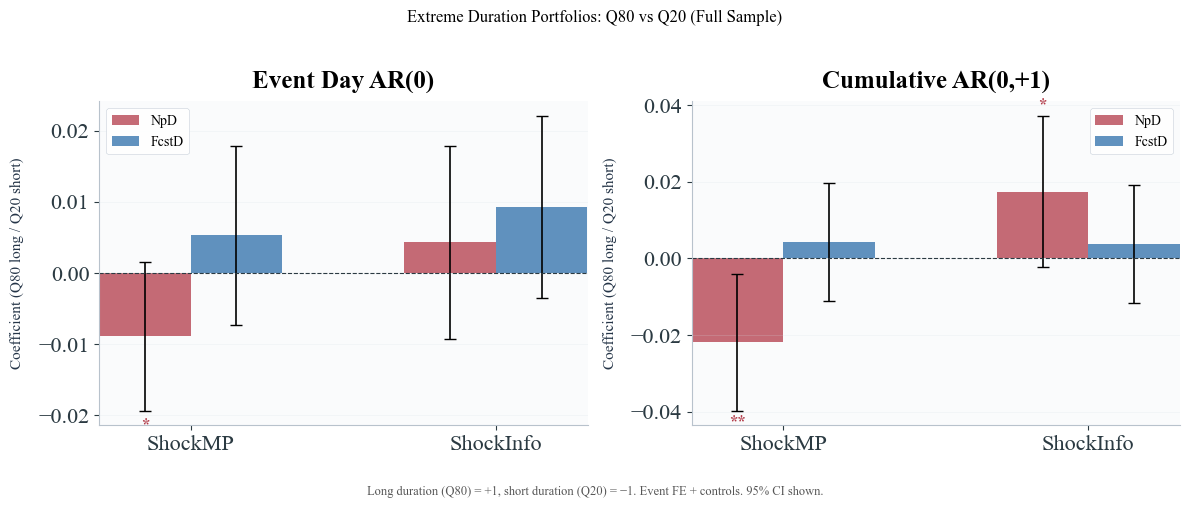

Saved: regression_results_portfolio_q20q80.csv (4 rows)


In [ ]:
# ── Plot: Q20 vs Q80 coefficients (full sample only) ─────────────────────────
set_global_plot_style()

try:
    if df_port.empty:
        raise ValueError("df_port is empty — no portfolio regressions succeeded.")

    _ls_labels = {
        'port_ls_NetPayout': 'NpD',
        'port_ls_FcstD':     'FcstD',
    }
    _ls_colors = {
        'port_ls_NetPayout': COLORS.get('accent', '#e07b39'),
        'port_ls_FcstD':     COLORS.get('blue', '#1f77b4'),
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    for ax_idx, (_dep, _dep_label) in enumerate(
            [('AR_0', 'Event Day AR(0)'), ('AR_0_1', 'Cumulative AR(0,+1)')]):
        ax = axes[ax_idx]
        _pdf = df_port[df_port['depvar'] == _dep].copy()
        if _pdf.empty:
            ax.set_visible(False)
            continue

        # One bar group per shock type, two bars per group (NpD, FcstD)
        _shock_labels = ['ShockMP', 'ShockInfo']
        _x = np.arange(len(_shock_labels))
        _w = 0.3

        for j, _ls in enumerate(_ls_vars):
            _row_data = _pdf[_pdf['ls_var'] == _ls]
            if _row_data.empty:
                continue
            _r = _row_data.iloc[0]
            _coefs = [_r['coef_mp'], _r['coef_info']]
            _ses   = [_r['se_mp'],   _r['se_info']]
            _ps    = [_r['p_mp'],    _r['p_info']]
            _offset = -_w/2 + j * _w

            bars = ax.bar(
                _x + _offset, _coefs, _w,
                yerr=[1.96 * s for s in _ses],
                color=_ls_colors.get(_ls, '#888'),
                alpha=0.75, capsize=4,
                label=_ls_labels.get(_ls, _ls),
                error_kw={'lw': 1.2}
            )
            # Significance stars
            for ix, (_c, _p, _s) in enumerate(zip(_coefs, _ps, _ses)):
                star = _sig_stars(_p)
                if star:
                    _y = _c + 1.96 * _s + 0.001 if _c >= 0 else _c - 1.96 * _s - 0.001
                    _va = 'bottom' if _c >= 0 else 'top'
                    ax.text(_x[ix] + _offset, _y, star, ha='center', va=_va,
                            fontsize=12, fontweight='bold',
                            color=_ls_colors.get(_ls, '#888'))

        ax.axhline(0, color=COLORS.get('reference', '#888'), ls='--', lw=0.8)
        ax.set_xticks(_x)
        ax.set_xticklabels(_shock_labels, fontsize=12)
        ax.set_ylabel('Coefficient (Q80 long / Q20 short)', fontsize=11)
        ax.set_title(_dep_label, fontsize=13)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)
        ax.legend(fontsize=10)

    fig.suptitle('Extreme Duration Portfolios: Q80 vs Q20 (Full Sample)',
                 fontsize=15, fontweight='bold')
    fig.tight_layout(rect=[0, 0.06, 1, 0.95])
    fig.text(0.5, 0.01,
             'Long duration (Q80) = +1, short duration (Q20) = −1. '
             'Event FE + controls. 95% CI shown.',
             ha='center', fontsize=9, color='#555555')
    save_figure(fig, 'rob_8_7_portfolio_q20q80', dpi=300)
    plt.show()

    # Export
    _port_export = df_port.drop(columns=['model_obj'], errors='ignore').copy()
    _port_export.to_csv(
        TABLE_DIR / 'regression_results_portfolio_q20q80.csv', index=False)
    print(f"Saved: regression_results_portfolio_q20q80.csv ({len(_port_export)} rows)")

except (ValueError, KeyError, AttributeError) as _e:
    print(f"WARNING: Section 8.7 plot skipped — {_e}")


### 9.8 Shock-Sign Asymmetry: Tightening vs. Easing Subsamples

Tests whether the Duration × ShockMP interaction differs between
**tightening surprises** (ShockMP > 0) and **easing surprises** (ShockMP < 0).

Under duration theory, tightening shocks raise discount rates, causing
proportionally larger price declines for long-duration equities. For
easing shocks the mirror effect should hold, but may be weaker if
investors respond asymmetrically or if nominal lower bounds create
non-linearities (Caballero & Farhi, 2018).

We estimate **Model 4 (Event FE + all controls)** separately on each
subsample for the two main duration measures (FcstD, NetPayout).

In [ ]:
# ── 8.8 Shock-Sign Asymmetry ─────────────────────────────────────────────────
# Split events into tightening (ShockMP > 0) vs. easing (ShockMP < 0),
# then run Model 4 on each subsample for main duration measures.
# ShockMP == 0 events are excluded from both subsamples (typically < 5 events).

_sign_rows = []

def _run_sign_split(df, sign_label, dur_var, depvar):
    """
    Run Model 4 (Event FE + all controls) on a shock-sign subsample.
    Returns a dict row, or None if estimation fails.
    """
    import warnings
    # Select subsample
    if sign_label == 'Tightening (ShockMP > 0)':
        mask = df['ShockMP'] > 0
    elif sign_label == 'Easing (ShockMP < 0)':
        mask = df['ShockMP'] < 0
    else:
        return None

    sub = df[mask].copy()
    sub = sub.dropna(subset=[depvar, dur_var, 'ShockMP', 'ShockInfo'])
    sub = sub.dropna(subset=['beta_std', 'log_mcap_std', 'leverage_std',
                              'bm_std'], how='all')

    n_events = sub['event_date'].nunique()
    if n_events < 20:
        print(f"  SKIP {sign_label} / {dur_var} / {depvar}: "
              f"only {n_events} events")
        return None

    # Build controls string (same as Model 4)
    ctrl_parts = []
    for c in ['beta_std', 'log_mcap_std', 'leverage_std']:
        if c in sub.columns and sub[c].notna().any():
            ctrl_parts.append(f'ShockMP:{c} + ShockInfo:{c}')
    if 'bm_std' in sub.columns and sub['bm_std'].notna().any():
        ctrl_parts.append(f'ShockMP:bm_std + ShockInfo:bm_std')

    rhs = (f'ShockMP:{dur_var} + ShockInfo:{dur_var}'
           + ((' + ' + ' + '.join(ctrl_parts)) if ctrl_parts else '')
           + ' + C(event_date)')
    formula = f'{depvar} ~ {rhs}'

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _model = smf.ols(formula, data=sub)
            _groups = pd.Categorical(sub.loc[_model.data.row_labels, 'event_date']).codes
            mod = _model.fit(
                cov_type='cluster',
                cov_kwds={'groups': _groups}
            )
    except Exception as e:
        print(f"  ERROR {sign_label} / {dur_var} / {depvar}: {e}")
        return None

    key_mp   = f'ShockMP:{dur_var}'
    key_info = f'ShockInfo:{dur_var}'

    def _safe(attr, key):
        try:
            return float(getattr(mod, attr)[key])
        except Exception:
            return float('nan')

    return {
        'sign_group':    sign_label,
        'duration_name': dur_var,
        'depvar':        depvar,
        'N':             int(mod.nobs),
        'n_events':      n_events,
        'coef_mp':       _safe('params',   key_mp),
        'se_mp':         _safe('bse',      key_mp),
        't_mp':          _safe('tvalues',  key_mp),
        'p_mp':          _safe('pvalues',  key_mp),
        'coef_info':     _safe('params',   key_info),
        'se_info':       _safe('bse',      key_info),
        't_info':        _safe('tvalues',  key_info),
        'p_info':        _safe('pvalues',  key_info),
        'r_squared_adj': float(mod.rsquared_adj),
    }


_sign_labels = ['Tightening (ShockMP > 0)', 'Easing (ShockMP < 0)']
_sign_dur_vars = [d for d in ['Duration_FcstD_std', 'Duration_NetPayout_std']
                  if d in df_evt.columns]
_sign_depvars = ['AR_0', 'AR_0_1']

for _dep in _sign_depvars:
    for _dur in _sign_dur_vars:
        for _sign in _sign_labels:
            _r = _run_sign_split(df_evt, _sign, _dur, _dep)
            if _r:
                _sign_rows.append(_r)

df_sign = pd.DataFrame(_sign_rows)

# ── Print summary ─────────────────────────────────────────────────────────────
def _stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

print("\nShock-Sign Asymmetry — Model 4 (Event FE + all controls)")
print("Hypothesis: Duration × ShockMP effect is stronger for tightening shocks")
print("Expected sign: NEGATIVE (tightening + long duration → lower AR)\n")

_cols_print = ['sign_group', 'duration_name', 'depvar', 'N', 'n_events',
               'coef_mp', 't_mp', 'p_mp', 'coef_info', 't_info', 'p_info']
_prt = df_sign[_cols_print].copy()
_prt['MP_coef_t']   = _prt.apply(
    lambda r: f"{r['coef_mp']:.4f}{_stars(r['p_mp'])} ({r['t_mp']:.2f})", axis=1)
_prt['Info_coef_t'] = _prt.apply(
    lambda r: f"{r['coef_info']:.4f}{_stars(r['p_info'])} ({r['t_info']:.2f})", axis=1)

print(_prt[['sign_group', 'duration_name', 'depvar', 'N', 'n_events',
            'MP_coef_t', 'Info_coef_t']].to_string(index=False))

# ── Event counts per sign group ───────────────────────────────────────────────
_n_tight = (df_evt['ShockMP'] > 0).sum()
_n_ease  = (df_evt['ShockMP'] < 0).sum()
_n_zero  = (df_evt['ShockMP'] == 0).sum()
_ev_tight = df_evt[df_evt['ShockMP'] > 0]['event_date'].nunique()
_ev_ease  = df_evt[df_evt['ShockMP'] < 0]['event_date'].nunique()
print(f"\nEvent-firm obs — Tightening: {_n_tight:,}  |  Easing: {_n_ease:,}"
      f"  |  Zero: {_n_zero:,}")
print(f"Unique events  — Tightening: {_ev_tight}  |  Easing: {_ev_ease}")


Shock-Sign Asymmetry — Model 4 (Event FE + all controls)
Hypothesis: Duration × ShockMP effect is stronger for tightening shocks
Expected sign: NEGATIVE (tightening + long duration → lower AR)

              sign_group          duration_name depvar     N  n_events          MP_coef_t     Info_coef_t
Tightening (ShockMP > 0)     Duration_FcstD_std   AR_0 51837       165      0.0040 (0.73)  0.0090* (1.76)
    Easing (ShockMP < 0)     Duration_FcstD_std   AR_0 46556       147    -0.0028 (-0.47)   0.0026 (0.47)
Tightening (ShockMP > 0) Duration_NetPayout_std   AR_0 44698       165    -0.0057 (-1.49)   0.0066 (1.09)
    Easing (ShockMP < 0) Duration_NetPayout_std   AR_0 39406       147    -0.0092 (-1.60)   0.0027 (0.46)
Tightening (ShockMP > 0)     Duration_FcstD_std AR_0_1 51388       165      0.0082 (0.97)   0.0084 (1.31)
    Easing (ShockMP < 0)     Duration_FcstD_std AR_0_1 46374       147    -0.0010 (-0.13) -0.0100 (-1.31)
Tightening (ShockMP > 0) Duration_NetPayout_std AR_0_1 44334   

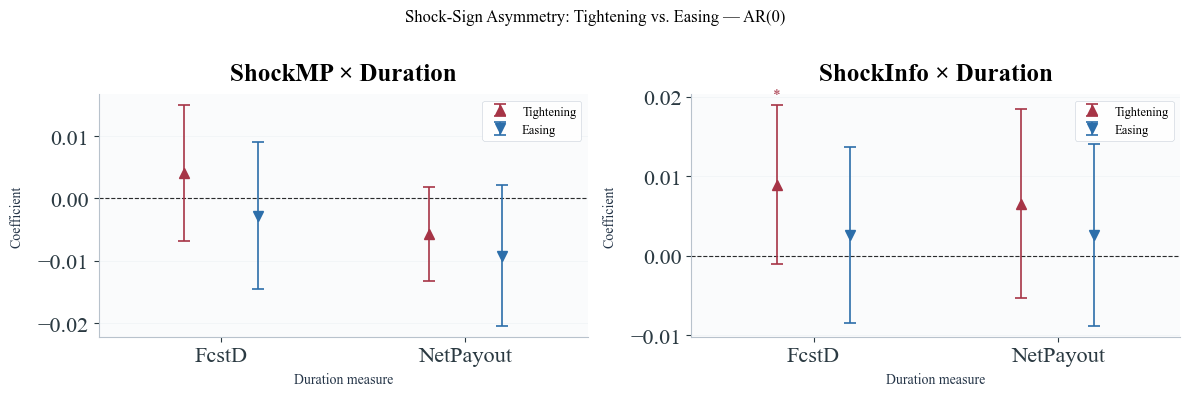

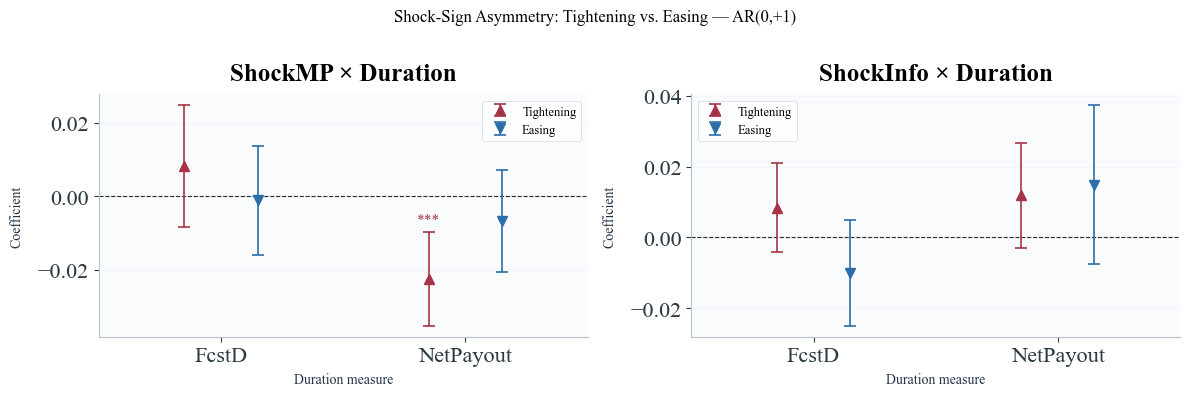

Exported: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_sign_asymmetry.csv  (8 rows)


In [ ]:
# ── 8.8 Plot: Tightening vs. Easing coefficients ─────────────────────────────
# Side-by-side coefficient plots for ShockMP×Duration and ShockInfo×Duration,
# separated by tightening/easing, for AR_0 and AR_0_1.

if df_sign.empty:
    print("No sign-split results to plot.")
else:
    _sign_colors = {
        'Tightening (ShockMP > 0)': COLORS.get('red', '#d62728'),
        'Easing (ShockMP < 0)':     COLORS.get('blue', '#1f77b4'),
    }
    _sign_markers = {
        'Tightening (ShockMP > 0)': '^',
        'Easing (ShockMP < 0)':     'v',
    }
    _sign_short = {
        'Tightening (ShockMP > 0)': 'Tightening',
        'Easing (ShockMP < 0)':     'Easing',
    }

    _shock_types = [('coef_mp', 'se_mp', 'p_mp', 'ShockMP × Duration'),
                    ('coef_info', 'se_info', 'p_info', 'ShockInfo × Duration')]

    for _dep in ['AR_0', 'AR_0_1']:
        _sub = df_sign[df_sign['depvar'] == _dep]
        if _sub.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

        for ax, (c_col, se_col, p_col, shock_label) in zip(axes, _shock_types):
            x_positions = []
            x_labels    = []
            _offset_map = {
                'Tightening (ShockMP > 0)': -0.15,
                'Easing (ShockMP < 0)':      0.15,
            }

            for i, _dur in enumerate(_sign_dur_vars):
                _dur_label = dur_short.get(_dur, _dur)
                x_positions.append(i)
                x_labels.append(_dur_label)

                for _sign in _sign_labels:
                    _r = _sub[(_sub['duration_name'] == _dur) &
                               (_sub['sign_group'] == _sign)]
                    if _r.empty:
                        continue
                    _r = _r.iloc[0]
                    _x  = i + _offset_map[_sign]
                    _c  = _r[c_col]
                    _se = _r[se_col]
                    _p  = _r[p_col]
                    _col = _sign_colors[_sign]
                    _mk  = _sign_markers[_sign]

                    ax.errorbar(
                        _x, _c, yerr=1.96 * _se,
                        fmt=_mk, color=_col, markersize=7,
                        capsize=4, capthick=1.2, linewidth=1.2,
                        label=_sign_short[_sign] if i == 0 else '_nolegend_',
                        zorder=3
                    )
                    # Significance stars — above CI upper bound
                    _st = _stars(_p)
                    if _st:
                        _y_off = _c + 1.96 * _se + abs(_c) * 0.05 if not np.isnan(_se) else _c * 1.1
                        ax.text(_x, _y_off, _st,
                                ha='center', va='bottom', fontsize=11,
                                color=_col)

            ax.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=1)
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, fontsize=9)
            ax.set_xlim(-0.5, len(x_positions) - 0.5)
            ax.set_xlabel('Duration measure', fontsize=10)
            ax.set_ylabel('Coefficient', fontsize=10)
            ax.set_title(shock_label, fontsize=11)
            style_axes(ax, grid_axis='y', grid_alpha=0.2)
            ax.legend(frameon=True, facecolor=(1,1,1,0.85), edgecolor='#C4CDD7',
                      fontsize=9, loc='best')

        _dep_label = dep_short.get(_dep, _dep)
        fig.suptitle(
            f'Shock-Sign Asymmetry: Tightening vs. Easing — {_dep_label}',
            fontsize=16, fontweight='bold'
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])

        _fname = f'rob_8_8_sign_asymmetry_{_dep}'
        save_figure(fig, _fname, dpi=300)
        plt.show()

# ── Export ────────────────────────────────────────────────────────────────────
if not df_sign.empty:
    _sign_out = TABLE_DIR / 'regression_results_sign_asymmetry.csv'
    df_sign.to_csv(_sign_out, index=False)
    print(f"Exported: {_sign_out}  ({len(df_sign)} rows)")

### 9.9 Formal Asymmetry Test: Triple Interaction

Section 9.8 estimates the Duration × ShockMP coefficient separately for
tightening and easing subsamples. This section tests whether the difference
is statistically significant using a **triple interaction**:

    AR ~ ShockMP × Duration × Tight + ShockInfo × Duration + controls + Event FE

where `Tight = 1` if ShockMP > 0, else 0.

The coefficient on `ShockMP × Duration × Tight` (β₃) tests
H₀: β_tightening = β_easing directly. A significantly negative β₃
would confirm that long-duration equities suffer disproportionately
more during tightening surprises than easing surprises — consistent
with the duration-based discount-rate channel.

Note: Events with ShockMP = 0 are excluded. Raw `Tight` and `ShockMP × Tight`
are included as additional controls to avoid omitted-variable bias in the
triple interaction.

In [ ]:
# ── 8.9 Formal Asymmetry Test — Triple Interaction ───────────────────────────
# NOTE: Event FE cannot be used here because Tight = I(ShockMP > 0) is a
# deterministic function of the event — C(event_date) would perfectly absorb
# it, collapsing SEs to NaN. Solution: No Event FE; include raw ShockMP and
# ShockInfo levels as controls (Model 5 logic). This is standard in the
# asymmetry/state-dependence literature (e.g. Tenreyro & Thwaites 2016).

import warnings

_asym_rows = []

def _run_triple_interaction(df, dur_var, depvar):
    """
    Triple interaction without Event FE:
      AR ~ ShockMP:Duration:Tight          ← key test coefficient
           + ShockMP:Duration              ← main interaction (= β_easing)
           + ShockInfo:Duration
           + ShockMP:Tight + Tight         ← lower-order terms (required)
           + ShockMP + ShockInfo           ← raw shock levels (no Event FE)
           + ShockMP:controls + ShockInfo:controls
    Clustered SEs by event_date.
    """
    sub = df[df['ShockMP'] != 0].copy()
    sub['Tight'] = (sub['ShockMP'] > 0).astype(float)

    sub = sub.dropna(subset=[depvar, dur_var, 'ShockMP', 'ShockInfo', 'Tight'])
    for c in ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']:
        if c not in sub.columns:
            sub[c] = float('nan')

    n_events = sub['event_date'].nunique()
    if n_events < 30:
        print(f"  SKIP {dur_var} / {depvar}: only {n_events} events")
        return None

    # Controls (same interaction structure as Model 5)
    ctrl_parts = []
    for c in ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']:
        if sub[c].notna().any():
            ctrl_parts.append(f'ShockMP:{c} + ShockInfo:{c}')

    rhs = (
        f'ShockMP:{dur_var}:Tight'    # triple interaction — key coefficient
        f' + ShockMP:{dur_var}'       # main interaction (implied β_easing)
        f' + ShockInfo:{dur_var}'
        f' + ShockMP:Tight'          # lower-order
        f' + Tight'                  # lower-order
        f' + ShockMP + ShockInfo'    # raw shock levels (replaces Event FE)
        + ((' + ' + ' + '.join(ctrl_parts)) if ctrl_parts else '')
    )
    formula = f'{depvar} ~ {rhs}'

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _model = smf.ols(formula, data=sub)
            _groups = pd.Categorical(sub.loc[_model.data.row_labels, 'event_date']).codes
            mod = _model.fit(
                cov_type='cluster',
                cov_kwds={'groups': _groups}
            )
    except Exception as e:
        print(f"  ERROR {dur_var} / {depvar}: {e}")
        return None

    def _safe(attr, key):
        try:
            return float(getattr(mod, attr)[key])
        except Exception:
            return float('nan')

    key_triple = f'ShockMP:{dur_var}:Tight'
    key_main   = f'ShockMP:{dur_var}'
    key_info   = f'ShockInfo:{dur_var}'

    c_main   = _safe('params', key_main)
    c_triple = _safe('params', key_triple)

    return {
        'duration_name':           dur_var,
        'depvar':                  depvar,
        'N':                       int(mod.nobs),
        'n_events':                n_events,
        'coef_triple':             c_triple,
        'se_triple':               _safe('bse',     key_triple),
        't_triple':                _safe('tvalues', key_triple),
        'p_triple':                _safe('pvalues', key_triple),
        'coef_main':               c_main,
        't_main':                  _safe('tvalues', key_main),
        'p_main':                  _safe('pvalues', key_main),
        'coef_tightening_implied': c_main + c_triple,
        'coef_info':               _safe('params',  key_info),
        't_info':                  _safe('tvalues', key_info),
        'p_info':                  _safe('pvalues', key_info),
        'r_squared_adj':           float(mod.rsquared_adj),
    }


_asym_dur_vars = [d for d in ['Duration_FcstD_std', 'Duration_NetPayout_std']
                  if d in df_evt.columns]
_asym_depvars  = ['AR_0', 'AR_0_1']

for _dep in _asym_depvars:
    for _dur in _asym_dur_vars:
        _r = _run_triple_interaction(df_evt, _dur, _dep)
        if _r:
            _asym_rows.append(_r)

df_asym = pd.DataFrame(_asym_rows)

# ── Print summary ─────────────────────────────────────────────────────────────
print("\nFormal Asymmetry Test — Triple Interaction (No Event FE)")
print("Specification: Model 5 logic — raw ShockMP/ShockInfo replace Event FE")
print("Key coefficient: ShockMP × Duration × Tight")
print("H₀: β_tightening = β_easing  (coef_triple = 0)")
print("Negative coef_triple → tightening effect MORE negative than easing\n")

if not df_asym.empty:
    for _, _r in df_asym.iterrows():
        _dur_s = dur_short.get(_r['duration_name'], _r['duration_name'])
        _dep_s = dep_short.get(_r['depvar'], _r['depvar'])
        _st    = _stars(_r['p_triple'])
        print(f"  {_dur_s} / {_dep_s}:")
        print(f"    β_triple (H₀ test):    "
              f"{_r['coef_triple']:+.4f}{_st}  "
              f"(t={_r['t_triple']:.2f}, p={_r['p_triple']:.3f})")
        print(f"    β_easing  (implied):   {_r['coef_main']:+.4f}  "
              f"(t={_r['t_main']:.2f})")
        print(f"    β_tight   (implied):   "
              f"{_r['coef_tightening_implied']:+.4f}")
        print(f"    N={_r['N']:,}  events={_r['n_events']}  "
              f"Adj.R²={_r['r_squared_adj']:.4f}")
        print()


Formal Asymmetry Test — Triple Interaction (No Event FE)
Specification: Model 5 logic — raw ShockMP/ShockInfo replace Event FE
Key coefficient: ShockMP × Duration × Tight
H₀: β_tightening = β_easing  (coef_triple = 0)
Negative coef_triple → tightening effect MORE negative than easing

  FcstD / AR(0):
    β_triple (H₀ test):    +0.0096  (t=0.96, p=0.337)
    β_easing  (implied):   -0.0047  (t=-0.67)
    β_tight   (implied):   +0.0049
    N=98,393  events=312  Adj.R²=0.0226

  NetPayout / AR(0):
    β_triple (H₀ test):    +0.0054  (t=0.76, p=0.449)
    β_easing  (implied):   -0.0109  (t=-1.74)
    β_tight   (implied):   -0.0055
    N=84,104  events=312  Adj.R²=0.0264

  FcstD / AR(0,+1):
    β_triple (H₀ test):    +0.0149  (t=1.13, p=0.257)
    β_easing  (implied):   -0.0049  (t=-0.55)
    β_tight   (implied):   +0.0100
    N=97,762  events=312  Adj.R²=0.0090

  NetPayout / AR(0,+1):
    β_triple (H₀ test):    -0.0128  (t=-1.35, p=0.176)
    β_easing  (implied):   -0.0092  (t=-1.16)
  

In [ ]:
# ── Export ────────────────────────────────────────────────────────────────────
if not df_asym.empty:
    _asym_out = TABLE_DIR / 'regression_results_asymmetry_triple.csv'
    df_asym.to_csv(_asym_out, index=False)
    print(f"Exported: {_asym_out}  ({len(df_asym)} rows)")

    # Sanity check: implied betas should match Section 8.8 subsample estimates
    print("\nSanity check — compare implied betas to Section 8.8 subsample results:")
    print("(Values should be close but not identical: different samples due to")
    print(" ShockMP=0 exclusion and control availability)")
    for _, _r in df_asym.iterrows():
        _dur_s = dur_short.get(_r['duration_name'], _r['duration_name'])
        _dep_s = dep_short.get(_r['depvar'], _r['depvar'])
        print(f"  {_dur_s} / {_dep_s}: "
              f"β_tight={_r['coef_tightening_implied']:+.4f}  "
              f"β_ease={_r['coef_main']:+.4f}")

Exported: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_asymmetry_triple.csv  (4 rows)

Sanity check — compare implied betas to Section 8.8 subsample results:
(Values should be close but not identical: different samples due to
 ShockMP=0 exclusion and control availability)
  FcstD / AR(0): β_tight=+0.0049  β_ease=-0.0047
  NetPayout / AR(0): β_tight=-0.0055  β_ease=-0.0109
  FcstD / AR(0,+1): β_tight=+0.0100  β_ease=-0.0049
  NetPayout / AR(0,+1): β_tight=-0.0220  β_ease=-0.0092


### 9.10 CAPM-Adjusted Abnormal Returns

The main results use **simple market-adjusted** abnormal returns
($AR_{i,t} = R_{i,t} - R_{m,t}$). This section re-estimates **Model 4**
using **CAPM-adjusted** abnormal returns
($AR^{CAPM}_{i,t} = R_{i,t} - r_{f,t} - \hat\beta_i (R_{m,t} - r_{f,t})$)
as the dependent variable.

If the duration interaction coefficients are stable, this confirms that
the main results are not driven by systematic beta differences between
long- and short-duration firms.

In [ ]:
# ── 9.10 CAPM-Adjusted Abnormal Returns ──────────────────────────

# Step 1: Check if capm_abnormal_return is available in the returns parquet
_capm_col = 'capm_abnormal_return'
_ret_check = pd.read_parquet(RET_PATH, columns=['date', 'firm_id',
                                                  'abnormal_return',
                                                  'capm_abnormal_return']
                              ) if True else None

_capm_available = (
    _capm_col in _ret_check.columns and
    _ret_check[_capm_col].notna().mean() > 0.10
)
print(f"capm_abnormal_return available: {_capm_available}")
if _capm_available:
    print(f"  Coverage: {_ret_check[_capm_col].notna().mean():.1%} "
          f"({_ret_check[_capm_col].notna().sum():,} rows)")

if not _capm_available:
    print("SKIP: capm_abnormal_return not available or insufficient coverage.")
    df_capm_results = pd.DataFrame()
else:
    # Step 2: Build CAPM-AR event panel
    # Re-read returns with CAPM column, build AR_0 and AR_0_1 equivalents
    _ret_capm = pd.read_parquet(RET_PATH)
    _ret_capm['date'] = pd.to_datetime(_ret_capm['date'],
                                        errors='coerce').dt.normalize()
    if 'firm_id' not in _ret_capm.columns:
        _ret_capm['firm_id'] = _ret_capm.get('RIC', pd.NA)
    _ret_capm['firm_id'] = _ret_capm['firm_id'].astype('string').str.strip()

    # Build capm AR windows (same logic as main panel)
    _ret_capm = _ret_capm.sort_values(['firm_id', 'date'])
    _ret_capm['capm_AR_0'] = pd.to_numeric(
        _ret_capm[_capm_col], errors='coerce')
    _ret_capm['capm_AR_lead1'] = (_ret_capm
        .groupby('firm_id', dropna=False)['capm_AR_0']
        .shift(-1))
    _ret_capm['capm_AR_0_1'] = (_ret_capm['capm_AR_0'] +
                                  _ret_capm['capm_AR_lead1'])

    # Restrict to event dates
    _evt_capm = _ret_capm[_ret_capm['date'].isin(event_dates)].copy()
    _evt_capm = _evt_capm.merge(
        df_shock[['date', 'ShockMP', 'ShockInfo']],
        on='date', how='left', validate='m:1'
    )
    _evt_capm['event_date'] = _evt_capm['date']
    _evt_capm['year_pred'] = (_evt_capm['date'].dt.year - 1).astype('Int64')

    # Exclude Financials
    _evt_capm = _evt_capm[
        _evt_capm['firm_id'].isin(NON_FINANCIAL_FIRMS)].copy()

    # Merge duration variables (same as main panel — reuse existing merge logic)
    # NpD — use same column resolution + filter as main pipeline
    _np_src_capm = df_np.copy()
    _np_dur_col_capm = first_existing(
        _np_src_capm,
        ['Duration_NetPayout', 'Duration_NP',
         'Duration_NetPayout_trim', 'Duration_NP_trim'],
        label='NetPayout duration (8.10)'
    )
    if _np_dur_col_capm is not None:
        if 'duration_usable' in _np_src_capm.columns:
            _usable = _np_src_capm['duration_usable'].fillna(False).astype(bool)
            _np_src_capm.loc[~_usable, _np_dur_col_capm] = np.nan
        _np_feat, _ = build_asof_feature_table(
            _np_src_capm,
            {_np_dur_col_capm: 'Duration_NetPayout'},
            source_name='NetPayout_capm'
        )
        _evt_capm, _ = merge_last_available_feature(
            _evt_capm, _np_feat, 'Duration_NetPayout',
            event_date_col='date', max_age_days=365
        )

    # FcstD — use same column + pv_fit_poor filter as main pipeline
    _fcst_src_capm = df_fcst.copy()
    if 'pv_fit_poor' in _fcst_src_capm.columns:
        _poor = _fcst_src_capm['pv_fit_poor'].fillna(False).astype(bool)
        _fcst_src_capm.loc[_poor, 'Duration_FcstD'] = np.nan
    _fcst_feat, _ = build_asof_feature_table(
        _fcst_src_capm,
        {'Duration_FcstD': 'Duration_FcstD'},
        source_name='FcstD_capm'
    )
    _evt_capm, _ = merge_last_available_feature(
        _evt_capm, _fcst_feat, 'Duration_FcstD',
        event_date_col='date', max_age_days=365
    )

    # Merge controls from main event panel (beta, size, leverage, bm)
    _ctrl_cols = [c for c in ['beta_std', 'log_mcap_std',
                               'leverage_std', 'bm_std']
                  if c in df_evt.columns]
    _evt_capm = _evt_capm.merge(
        df_evt[['firm_id', 'event_date'] + _ctrl_cols].drop_duplicates(
            ['firm_id', 'event_date']),
        on=['firm_id', 'event_date'],
        how='left'
    )

    # Cross-sectional standardisation (same as main panel)
    for _col, _std_col in [('Duration_NetPayout', 'Duration_NetPayout_std'),
                             ('Duration_FcstD',     'Duration_FcstD_std')]:
        if _col not in _evt_capm.columns:
            continue
        _evt_capm[_col] = pd.to_numeric(_evt_capm[_col], errors='coerce')
        _evt_capm[_std_col] = (
            _evt_capm.groupby('year_pred')[_col]
            .transform(lambda s: (s - s.mean()) / s.std(ddof=1))
        )

    print(f"\nCAP-AR event panel: {len(_evt_capm):,} rows, "
          f"{_evt_capm['event_date'].nunique()} events")
    print(f"  capm_AR_0 non-null:   "
          f"{_evt_capm['capm_AR_0'].notna().sum():,}")
    print(f"  capm_AR_0_1 non-null: "
          f"{_evt_capm['capm_AR_0_1'].notna().sum():,}")

    # Step 3: Run Model 4 for both duration measures and both dep vars
    _capm_rows = []
    _capm_depvars = ['capm_AR_0', 'capm_AR_0_1']
    _capm_dur_vars = [d for d in ['Duration_FcstD_std',
                                   'Duration_NetPayout_std']
                      if d in _evt_capm.columns]

    for _dep in _capm_depvars:
        for _dur in _capm_dur_vars:
            _r = run_regression(
                df=_evt_capm,
                depvar=_dep,
                duration_var=_dur,
                specification_name='Model 4: Event FE + all controls',
                include_event_fe=True,
                include_raw_shocks=False,
                controls=[c.replace('_std', '') for c in _ctrl_cols
                           if c not in ['bm_std']
                           and c.replace('_std', '') in
                           ['beta', 'size', 'leverage']],
                cluster='event',
                include_bm=('bm_std' in _ctrl_cols),
            )
            if _r is not None:
                _r['depvar_label'] = _dep
                _capm_rows.append(_r)

    df_capm_results = pd.DataFrame(_capm_rows)

    # Step 4: Side-by-side comparison
    print("\n" + "="*65)
    print("CAPM-AR vs. Market-AR: Model 4 Comparison")
    print("="*65)
    print(f"{'Measure':<12} {'Dep var':<14} {'Benchmark':<10} "
          f"{'CAPM-AR':<10}  {'Diff'}")
    print("-"*65)

    for _dur in _capm_dur_vars:
        _dur_s = dur_short.get(_dur, _dur)
        for _dep_base, _dep_capm in [('AR_0',   'capm_AR_0'),
                                      ('AR_0_1', 'capm_AR_0_1')]:
            # Main result
            _main = df_results[
                (df_results['specification_name'] ==
                 'Model 4: Event FE + all controls') &
                (df_results['duration_name'] == _dur) &
                (df_results['depvar'] == _dep_base)
            ]
            # CAPM result
            _capm = df_capm_results[
                (df_capm_results['duration_name'] == _dur) &
                (df_capm_results['depvar'] == _dep_capm)
            ] if not df_capm_results.empty else pd.DataFrame()

            if _main.empty:
                continue
            _c_main = float(_main['coef_mp_duration'].iloc[0])
            _t_main = float(_main['t_mp_duration'].iloc[0])
            _st_main = _stars(_main['p_mp_duration'].iloc[0])

            if _capm.empty:
                print(f"  {_dur_s:<12} {_dep_base:<14} "
                      f"{_c_main:+.4f}{_st_main} ({_t_main:.2f})  "
                      f"{'n/a':<10}")
                continue

            _c_capm = float(_capm['coef_mp_duration'].iloc[0])
            _t_capm = float(_capm['t_mp_duration'].iloc[0])
            _st_capm = _stars(_capm['p_mp_duration'].iloc[0])
            _diff = _c_capm - _c_main

            print(f"  {_dur_s:<12} {_dep_base:<14} "
                  f"{_c_main:+.4f}{_st_main} ({_t_main:.2f})  "
                  f"{_c_capm:+.4f}{_st_capm} ({_t_capm:.2f})  "
                  f"{_diff:+.5f}")

capm_abnormal_return available: True
  Coverage: 92.9% (3,213,067 rows)

CAP-AR event panel: 129,510 rows, 312 events
  capm_AR_0 non-null:   123,336
  capm_AR_0_1 non-null: 122,467

CAPM-AR vs. Market-AR: Model 4 Comparison
Measure      Dep var        Benchmark  CAPM-AR     Diff
-----------------------------------------------------------------
  FcstD        AR_0           +0.0018 (0.41)  +0.0044 (1.16)  +0.00262
  FcstD        AR_0_1         +0.0050 (0.77)  +0.0085 (1.53)  +0.00346
  NetPayout    AR_0           -0.0072** (-2.19)  -0.0143** (-2.48)  -0.00705
  NetPayout    AR_0_1         -0.0183*** (-3.37)  -0.0228*** (-2.74)  -0.00452


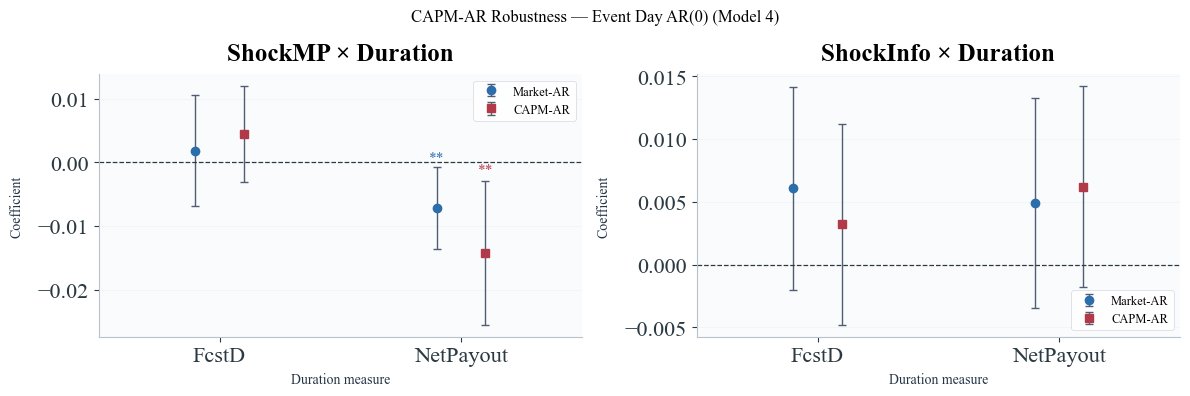

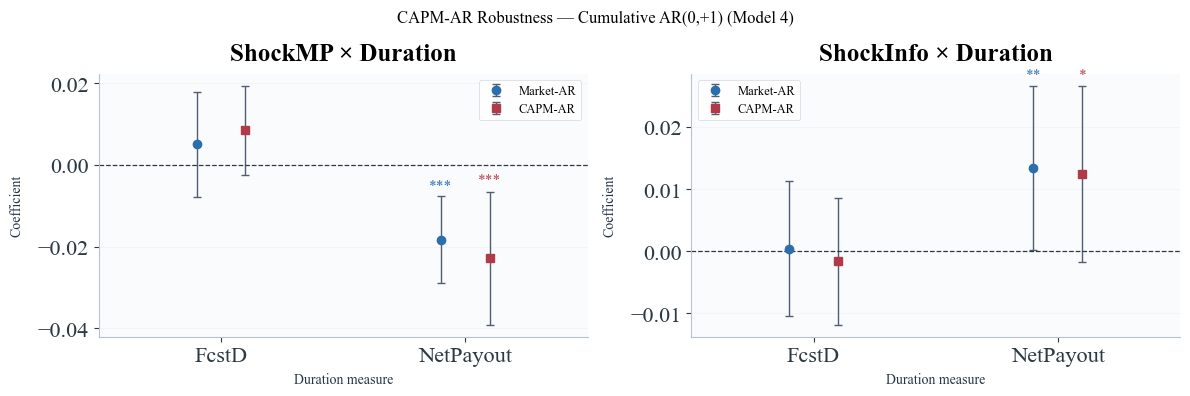

In [ ]:
# ── 9.10 Plot: Market-AR vs CAPM-AR ──────────────────────────────────────────
if df_capm_results.empty:
    print("No CAPM-AR results to plot.")
else:
    set_global_plot_style()
    _capm_dur_list = [d for d in ['Duration_FcstD_std', 'Duration_NetPayout_std']
                      if d in df_capm_results['duration_name'].values]
    _capm_dep_map = {'AR_0': 'capm_AR_0', 'AR_0_1': 'capm_AR_0_1'}

    _color_market = COLORS.get('blue',   '#1f77b4')
    _color_capm   = COLORS.get('accent', '#d62728')
    _marker_market = 'o'
    _marker_capm   = 's'

    n_dur = len(_capm_dur_list)
    w = 0.20
    _offsets = {'Market-AR': -w/2, 'CAPM-AR': +w/2}

    for _dep_base, _dep_label, _fname in [
        ('AR_0',   'Event Day AR(0)',    'rob_8_10_capm_ar_AR0'),
        ('AR_0_1', 'Cumulative AR(0,+1)', 'rob_8_10_capm_ar_AR0_1'),
    ]:
        _dep_capm = _capm_dep_map[_dep_base]

        # Main results for this depvar
        _main_df = df_results[
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == _dep_base)
        ]
        # CAPM results for this depvar
        _capm_df = df_capm_results[
            df_capm_results['depvar'] == _dep_capm
        ]

        if _main_df.empty and _capm_df.empty:
            continue

        x = np.arange(n_dur)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

        for ax, coef_col, se_col, p_col, shock_label in [
            (axes[0], 'coef_mp_duration',   'se_mp_duration',   'p_mp_duration',   'ShockMP × Duration'),
            (axes[1], 'coef_info_duration', 'se_info_duration', 'p_info_duration', 'ShockInfo × Duration'),
        ]:
            for _label, _src_df, _col, _mk in [
                ('Market-AR', _main_df, _color_market, _marker_market),
                ('CAPM-AR',   _capm_df, _color_capm,   _marker_capm),
            ]:
                _coefs, _ses, _ps = [], [], []
                for _dur in _capm_dur_list:
                    _r = _src_df[_src_df['duration_name'] == _dur]
                    if _r.empty:
                        _coefs.append(np.nan)
                        _ses.append(np.nan)
                        _ps.append(np.nan)
                    else:
                        _coefs.append(float(_r[coef_col].iloc[0]))
                        _ses.append(float(_r[se_col].iloc[0]))
                        _ps.append(float(_r[p_col].iloc[0]))

                _coefs_arr = np.array(_coefs, dtype=float)
                _ses_arr   = np.array(_ses, dtype=float)
                _off = _offsets[_label]

                ax.errorbar(
                    x + _off, _coefs_arr, yerr=1.96 * _ses_arr,
                    fmt=_mk, color=_col,
                    ecolor=COLORS.get('neutral', '#aaa'),
                    capsize=3, markersize=6,
                    label=_label
                )
                for _ix, (_c, _p, _se) in enumerate(zip(_coefs, _ps, _ses)):
                    _star = _sig_stars(_p)
                    if _star and not np.isnan(_c):
                        _y_off = _c + 1.96 * _se + abs(_c) * 0.05 if not np.isnan(_se) else _c * 1.1
                        ax.text(x[_ix] + _off, _y_off, _star,
                                ha='center', va='bottom',
                                fontsize=11, color=_col)

            ax.axhline(0, color=COLORS.get('reference', '#888'),
                       linewidth=0.9, linestyle='--')
            ax.set_xticks(x)
            ax.set_xticklabels([dur_short.get(d, d) for d in _capm_dur_list],
                               fontsize=9)
            ax.set_xlim(-0.5, n_dur - 0.5)
            ax.set_xlabel('Duration measure', fontsize=10)
            ax.set_ylabel('Coefficient', fontsize=10)
            ax.set_title(f'{shock_label}', fontsize=11)
            style_axes(ax, grid_axis='y', grid_alpha=0.2)
            ax.legend(frameon=True, facecolor=(1,1,1,0.85),
                      edgecolor='#C4CDD7', fontsize=9)

        plt.suptitle(
            f'CAPM-AR Robustness — {_dep_label} (Model 4)',
            fontsize=16, fontweight='bold')
        plt.tight_layout()
        save_figure(fig, _fname, dpi=300)
        plt.show()

In [ ]:
if not df_capm_results.empty:
    _capm_out = TABLE_DIR / 'regression_results_capm_ar.csv'
    df_capm_results.to_csv(_capm_out, index=False)
    print(f"Exported: {_capm_out}  ({len(df_capm_results)} rows)")
else:
    print("No CAPM-AR results to export.")

Exported: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_capm_ar.csv  (4 rows)


## 10. Build Tidy Results Tables

In [ ]:
print("=" * 60)
print("SECTION 10: BUILD TIDY RESULTS TABLES")
print("=" * 60)

def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration']      = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE']      = tbl['event_FE']
tbl['Controls']      = tbl['controls']

for c in ['coef_mp_duration', 't_mp_duration', 'p_mp_duration',
          'coef_info_duration', 't_info_duration', 'p_info_duration',
          'r_squared_adj']:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'n_clusters', 'r_squared_adj',
]
col_rename = {
    'coef_mp_duration':   'ShockMP x Duration',
    't_mp_duration':      't-stat MP',
    'p_mp_duration':      'p-value MP',
    'coef_info_duration': 'ShockInfo x Duration',
    't_info_duration':    't-stat Info',
    'p_info_duration':    'p-value Info',
    'n_events':           'Events',
    'n_clusters':         'Clusters',
    'r_squared_adj':      'Adj. R2',
}

TABLE_A = tbl[tbl['depvar'] == 'AR_0'][table_cols].rename(columns=col_rename).copy()
TABLE_B = tbl[tbl['depvar'] == 'AR_0_1'][table_cols].rename(columns=col_rename).copy()

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP x Duration', 't-stat MP', 'p-value MP',
              'ShockInfo x Duration', 't-stat Info', 'p-value Info', 'Adj. R2']:
        if c in _t.columns:
            _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

# Reader table: coef*** (t-stat) format
reader = tbl.copy()
reader['ShockMP x Duration'] = reader.apply(
    lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']),
    axis=1)
reader['ShockInfo x Duration'] = reader.apply(
    lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']),
    axis=1) 
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls',
                         'ShockMP x Duration', 'ShockInfo x Duration',
                         'N', 'n_events', 'n_clusters', 'r_squared_adj']].rename(
    columns={'depvar': 'Return window', 'n_events': 'Events',
             'n_clusters': 'Clusters', 'r_squared_adj': 'Adj. R2'})

print('TABLE A: AR_0 (event-day return)')
display(TABLE_A)
print('\nTABLE B: AR_0_1 (cumulative 2-day return)')
display(TABLE_B)
print('\nReader table — coef*** (t-stat):')
display(TABLE_READER)

SECTION 10: BUILD TIDY RESULTS TABLES
TABLE A: AR_0 (event-day return)


,Duration,Specification,Event FE,Controls,ShockMP x Duration,t-stat MP,p-value MP,ShockInfo x Duration,t-stat Info,p-value Info,N,Events,Clusters,Adj. R2
0,FcstD,Model 1: Baseline,No,None,0.0028,0.5197,0.6033,0.0085,1.6724,0.0944,101364,312,312,0.0131
1,FcstD,Model 2: + beta,No,beta,0.0044,0.8192,0.4127,0.0057,1.1723,0.2411,99994,312,312,0.0186
2,FcstD,Model 3: + size/leverage,No,"beta, size, leverage",0.0021,0.4797,0.6314,0.0058,1.4076,0.1592,98415,312,312,0.0218
3,FcstD,Model 4: Event FE + all controls,Yes,"beta, size, leverage",0.0018,0.4112,0.6809,0.0061,1.4721,0.1410,98393,312,312,0.0767
4,FcstD,Model 5: No Event FE + all controls,No,"beta, size, leverage",0.0021,0.4825,0.6294,0.0057,1.3936,0.1634,98393,312,312,0.0218
5,NetPayout,Model 1: Baseline,No,None,-0.0041,-1.0157,0.3098,0.0037,0.8147,0.4152,85350,312,312,0.0158
6,NetPayout,Model 2: + beta,No,beta,-0.0099,-3.6646,0.0002,0.0096,2.4126,0.0158,84104,312,312,0.0224
7,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0068,-2.1630,0.0305,0.0052,1.1835,0.2366,84104,312,312,0.0257
8,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0072,-2.1943,0.0282,0.0049,1.1563,0.2476,84104,312,312,0.0856
9,NetPayout,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0071,-2.1470,0.0318,0.0045,1.0552,0.2913,84104,312,312,0.0257



TABLE B: AR_0_1 (cumulative 2-day return)


,Duration,Specification,Event FE,Controls,ShockMP x Duration,t-stat MP,p-value MP,ShockInfo x Duration,t-stat Info,p-value Info,N,Events,Clusters,Adj. R2
35,FcstD,Model 1: Baseline,No,None,0.0048,0.6527,0.5139,0.0028,0.4423,0.6583,100693,312,312,0.0045
36,FcstD,Model 2: + beta,No,beta,0.0070,0.9420,0.3462,0.0002,0.0294,0.9765,99343,312,312,0.0078
37,FcstD,Model 3: + size/leverage,No,"beta, size, leverage",0.0056,0.8643,0.3874,0.0002,0.0302,0.9759,97784,312,312,0.0087
38,FcstD,Model 4: Event FE + all controls,Yes,"beta, size, leverage",0.0050,0.7696,0.4415,0.0004,0.0811,0.9354,97762,312,312,0.0677
39,FcstD,Model 5: No Event FE + all controls,No,"beta, size, leverage",0.0055,0.8648,0.3872,0.0001,0.0156,0.9876,97762,312,312,0.0088
40,NetPayout,Model 1: Baseline,No,None,-0.0106,-2.1970,0.0280,0.0107,1.5465,0.1220,84881,312,312,0.0048
41,NetPayout,Model 2: + beta,No,beta,-0.0176,-3.8842,0.0001,0.0169,2.5923,0.0095,83654,312,312,0.0095
42,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0157,-3.4659,0.0005,0.0131,1.9664,0.0493,83654,312,312,0.0104
43,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0183,-3.3724,0.0007,0.0134,1.9838,0.0473,83654,312,312,0.0753
44,NetPayout,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0182,-3.3165,0.0009,0.0127,1.8865,0.0592,83654,312,312,0.0105



Reader table — coef*** (t-stat):


,Return window,Duration,Specification,Event FE,Controls,ShockMP x Duration,ShockInfo x Duration,N,Events,Clusters,Adj. R2
0,AR_0,FcstD,Model 1: Baseline,No,None,0.0028 (0.52),0.0085* (1.67),101364,312,312,0.013084
1,AR_0,FcstD,Model 2: + beta,No,beta,0.0044 (0.82),0.0057 (1.17),99994,312,312,0.018644
2,AR_0,FcstD,Model 3: + size/leverage,No,"beta, size, leverage",0.0021 (0.48),0.0058 (1.41),98415,312,312,0.021759
3,AR_0,FcstD,Model 4: Event FE + all controls,Yes,"beta, size, leverage",0.0018 (0.41),0.0061 (1.47),98393,312,312,0.076651
4,AR_0,FcstD,Model 5: No Event FE + all controls,No,"beta, size, leverage",0.0021 (0.48),0.0057 (1.39),98393,312,312,0.021819
...,...,...,...,...,...,...,...,...,...,...,...
65,AR_0_1,EP_rob,Model 1: Baseline,No,None,0.0056 (1.02),-0.0048 (-0.83),119921,312,312,0.005409
66,AR_0_1,EP_rob,Model 2: + beta,No,beta,0.0022 (0.42),-0.0010 (-0.18),116596,312,312,0.008990
67,AR_0_1,EP_rob,Model 3: + size/leverage,No,"beta, size, leverage",0.0046 (0.98),0.0006 (0.11),114444,312,312,0.010157
68,AR_0_1,EP_rob,Model 4: Event FE + all controls,Yes,"beta, size, leverage",0.0061 (1.32),0.0033 (0.52),113589,312,312,0.073210


## 11. Side-by-Side Comparison Tables

In [ ]:
print("=" * 60)
print("SECTION 11: COMPARISON TABLES")
print("=" * 60)

compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE',
               'coef_mp_duration', 'coef_info_duration',
               't_mp_duration', 't_info_duration',
               'p_mp_duration', 'p_info_duration']].copy()

compact['mp_reader']   = compact.apply(
    lambda r: make_reader_entry(r['coef_mp_duration'],   r['t_mp_duration'],   r['p_mp_duration']),   axis=1)
compact['info_reader'] = compact.apply(
    lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)

# CMP_1: All duration measures side by side (AR_0)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'],
                 columns='duration_name',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# CMP_2: AR_0 vs AR_0_1 (same duration, same specification)
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'],
                 columns='depvar',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# CMP_3: Event FE (Model 4) vs No Event FE (Model 5)
_cmp3_base = compact[compact['specification_name'].isin([
    'Model 4: Event FE + all controls',
    'Model 5: No Event FE + all controls',])].copy()
CMP_3 = (
    _cmp3_base
    .pivot_table(index=['depvar', 'duration_name'],
                 columns='specification_name',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: All duration measures (AR_0)')
display(CMP_1)
print('\nComparison Table 2: Event Day (AR_0) vs Cumulative (AR_0_1)')
display(CMP_2)
print('\nComparison Table 3: Event FE (M4) vs No Event FE (M5)')
display(CMP_3)

SECTION 11: COMPARISON TABLES
Comparison Table 1: All duration measures (AR_0)


info_reader                                                                                                   \
duration_name                                              BM_rob_std Duration_FcstD_std Duration_NetPayout_std          EPP_std         EP_rob_std    SY_div_only_std   
depvar specification_name                  event_FE                                                                                                                      
AR_0   Model 1: Baseline                   No         -0.0043 (-0.65)     0.0085* (1.67)          0.0037 (0.81)   0.0136* (1.95)  -0.0092** (-2.42)  -0.0123** (-2.18)   
       Model 2: + beta                     No        -0.0114* (-1.70)      0.0057 (1.17)        0.0096** (2.41)  0.0170** (2.55)    -0.0052 (-1.37)  -0.0112** (-2.20)   
       Model 3: + size/leverage            No         -0.0046 (-0.87)      0.0058 (1.41)          0.0052 (1.18)  0.0132** (2.47)    -0.0036 (-0.93)  -0.0085** (-2.01)   
       Model 4: Event FE + all controls    Yes          0.0144 (1.60)      0.0061 (1.47)          0.0049 (1.16)  0.0168** (2.10)    -0.0030 (-0.75)  -0.0077** (-1.98)   
       Model 5: No Event FE + all controls No          0.0148* (1.65)      0.0057 (1.39)          0.0045 (1.06)   0.0146* (1.80)    -0.0029 (-0.72)   -0.0075* (-1.93)   

                                                                            mp_reader                                                                              \
duration_name                                           SY_gross_std       BM_rob_std Duration_FcstD_std Duration_NetPayout_std          EPP_std       EP_rob_std   
depvar specification_name                  event_FE                                                                                                                 
AR_0   Model 1: Baseline                   No        -0.0024 (-0.51)  -0.0064 (-0.80)      0.0028 (0.52)        -0.0041 (-1.02)    0.0025 (0.35)  0.0074** (2.02)   
       Model 2: + beta                     No        -0.0046 (-0.97)  -0.0035 (-0.41)      0.0044 (0.82)     -0.0099*** (-3.66)    0.0022 (0.29)    0.0034 (0.99)   
       Model 3: + size/leverage            No        -0.0014 (-0.35)  -0.0011 (-0.21)      0.0021 (0.48)      -0.0068** (-2.16)  -0.0022 (-0.49)  0.0065** (2.11)   
       Model 4: Event FE + all controls    Yes       -0.0002 (-0.06)  -0.0126 (-1.47)      0.0018 (0.41)      -0.0072** (-2.19)  -0.0007 (-0.13)  0.0067** (2.12)   
       Model 5: No Event FE + all controls No        -0.0005 (-0.13)  -0.0126 (-1.46)      0.0021 (0.48)      -0.0071** (-2.15)  -0.0019 (-0.33)  0.0067** (2.18)   

                                                                                        
duration_name                                        SY_div_only_std      SY_gross_std  
depvar specification_name                  event_FE                                     
AR_0   Model 1: Baseline                   No        -0.0029 (-0.47)   -0.0044 (-0.92)  
       Model 2: + beta                     No        -0.0046 (-0.85)   -0.0063 (-1.30)  
       Model 3: + size/leverage            No        -0.0023 (-0.63)   -0.0054 (-1.47)  
       Model 4: Event FE + all controls    Yes       -0.0023 (-0.71)   -0.0056 (-1.61)  
       Model 5: No Event FE + all controls No        -0.0024 (-0.74)  -0.0058* (-1.66)


Comparison Table 2: Event Day (AR_0) vs Cumulative (AR_0_1)


info_reader                             mp_reader                    
depvar                                                                            AR_0            AR_0_1                AR_0              AR_0_1
duration_name          specification_name                  event_FE                                                                             
BM_rob_std             Model 1: Baseline                   No          -0.0043 (-0.65)   -0.0056 (-0.57)     -0.0064 (-0.80)     -0.0106 (-0.98)
                       Model 2: + beta                     No         -0.0114* (-1.70)   -0.0130 (-1.37)     -0.0035 (-0.41)     -0.0073 (-0.64)
                       Model 3: + size/leverage            No          -0.0046 (-0.87)   -0.0080 (-1.05)     -0.0011 (-0.21)     -0.0061 (-0.74)
                       Model 4: Event FE + all controls    Yes           0.0144 (1.60)     0.0075 (0.64)     -0.0126 (-1.47)     -0.0140 (-1.53)
                       Model 5: No Event FE + all controls No           0.0148* (1.65)     0.0075 (0.63)     -0.0126 (-1.46)     -0.0136 (-1.47)
Duration_FcstD_std     Model 1: Baseline                   No           0.0085* (1.67)     0.0028 (0.44)       0.0028 (0.52)       0.0048 (0.65)
                       Model 2: + beta                     No            0.0057 (1.17)     0.0002 (0.03)       0.0044 (0.82)       0.0070 (0.94)
                       Model 3: + size/leverage            No            0.0058 (1.41)     0.0002 (0.03)       0.0021 (0.48)       0.0056 (0.86)
                       Model 4: Event FE + all controls    Yes           0.0061 (1.47)     0.0004 (0.08)       0.0018 (0.41)       0.0050 (0.77)
                       Model 5: No Event FE + all controls No            0.0057 (1.39)     0.0001 (0.02)       0.0021 (0.48)       0.0055 (0.86)
Duration_NetPayout_std Model 1: Baseline                   No            0.0037 (0.81)     0.0107 (1.55)     -0.0041 (-1.02)   -0.0106** (-2.20)
                       Model 2: + beta                     No          0.0096** (2.41)  0.0169*** (2.59)  -0.0099*** (-3.66)  -0.0176*** (-3.88)
                       Model 3: + size/leverage            No            0.0052 (1.18)   0.0131** (1.97)   -0.0068** (-2.16)  -0.0157*** (-3.47)
                       Model 4: Event FE + all controls    Yes           0.0049 (1.16)   0.0134** (1.98)   -0.0072** (-2.19)  -0.0183*** (-3.37)
                       Model 5: No Event FE + all controls No            0.0045 (1.06)    0.0127* (1.89)   -0.0071** (-2.15)  -0.0182*** (-3.32)
EPP_std                Model 1: Baseline                   No           0.0136* (1.95)     0.0105 (1.12)       0.0025 (0.35)       0.0058 (0.58)
                       Model 2: + beta                     No          0.0170** (2.55)    0.0149* (1.72)       0.0022 (0.29)       0.0060 (0.58)
                       Model 3: + size/leverage            No          0.0132** (2.47)    0.0120* (1.73)     -0.0022 (-0.49)       0.0033 (0.44)
                       Model 4: Event FE + all controls    Yes         0.0168** (2.10)     0.0117 (1.17)     -0.0007 (-0.13)       0.0017 (0.25)
                       Model 5: No Event FE + all controls No           0.0146* (1.80)     0.0103 (1.03)     -0.0019 (-0.33)       0.0011 (0.16)
EP_rob_std             Model 1: Baseline                   No        -0.0092** (-2.42)   -0.0048 (-0.83)     0.0074** (2.02)       0.0056 (1.02)
                       Model 2: + beta                     No          -0.0052 (-1.37)   -0.0010 (-0.18)       0.0034 (0.99)       0.0022 (0.42)
                       Model 3: + size/leverage            No          -0.0036 (-0.93)     0.0006 (0.11)     0.0065** (2.11)       0.0046 (0.98)
                       Model 4: Event FE + all controls    Yes         -0.0030 (-0.75)     0.0033 (0.52)     0.0067** (2.12)       0.0061 (1.32)
                       Model 5: No Event FE + all controls No          -0.0029 (-0.72)     0.0032 (0.50)     0.0067** (2.18)       0.0056 (1.23)
SY_div_only_std


Comparison Table 3: Event FE (M4) vs No Event FE (M5)


info_reader                                                            mp_reader                                    
specification_name            Model 4: Event FE + all controls Model 5: No Event FE + all controls Model 4: Event FE + all controls Model 5: No Event FE + all controls
depvar duration_name                                                                                                                                                   
AR_0   BM_rob_std                                0.0144 (1.60)                      0.0148* (1.65)                  -0.0126 (-1.47)                     -0.0126 (-1.46)
       Duration_FcstD_std                        0.0061 (1.47)                       0.0057 (1.39)                    0.0018 (0.41)                       0.0021 (0.48)
       Duration_NetPayout_std                    0.0049 (1.16)                       0.0045 (1.06)                -0.0072** (-2.19)                   -0.0071** (-2.15)
       EPP_std                                 0.0168** (2.10)                      0.0146* (1.80)                  -0.0007 (-0.13)                     -0.0019 (-0.33)
       EP_rob_std                              -0.0030 (-0.75)                     -0.0029 (-0.72)                  0.0067** (2.12)                     0.0067** (2.18)
       SY_div_only_std                       -0.0077** (-1.98)                    -0.0075* (-1.93)                  -0.0023 (-0.71)                     -0.0024 (-0.74)
       SY_gross_std                            -0.0002 (-0.06)                     -0.0005 (-0.13)                  -0.0056 (-1.61)                    -0.0058* (-1.66)
AR_0_1 BM_rob_std                                0.0075 (0.64)                       0.0075 (0.63)                  -0.0140 (-1.53)                     -0.0136 (-1.47)
       Duration_FcstD_std                        0.0004 (0.08)                       0.0001 (0.02)                    0.0050 (0.77)                       0.0055 (0.86)
       Duration_NetPayout_std                  0.0134** (1.98)                      0.0127* (1.89)               -0.0183*** (-3.37)                  -0.0182*** (-3.32)
       EPP_std                                   0.0117 (1.17)                       0.0103 (1.03)                    0.0017 (0.25)                       0.0011 (0.16)
       EP_rob_std                                0.0033 (0.52)                       0.0032 (0.50)                    0.0061 (1.32)                       0.0056 (1.23)
       SY_div_only_std                        -0.0107* (-1.66)                    -0.0108* (-1.69)                  -0.0033 (-0.65)                     -0.0036 (-0.72)
       SY_gross_std                              0.0027 (0.58)                       0.0027 (0.59)                 -0.0072* (-1.72)                    -0.0071* (-1.70)

## 12. Professional LaTeX Table

Two-panel booktabs table (Panel A: ShockMP × Duration, Panel B: ShockInfo × Duration).
Columns: FcstD | NetPayout | EPP. Footer rows: Event FE, N, Adj. R².
Generates two tables: one for AR_0 and one for AR_0_1.
Saves to `regression_table_main_AR0.tex` and `regression_table_main_AR0_1.tex`.

In [ ]:
print("=" * 60)
print("SECTION 12: PROFESSIONAL LaTeX TABLE")
print("=" * 60)

def _tex_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '$^{***}$'
    if p < 0.05:   return '$^{**}$'
    if p < 0.10:   return '$^{*}$'
    return ''

def build_latex_table(results_df, depvar='AR_0', outpath=None):
    _dep_label = {'AR_0': r'AR$_{0}$ (event day)',
                  'AR_0_1': r'AR$_{0,1}$ (cumulative 2-day)'}
    _df    = results_df[results_df['depvar'] == depvar].copy()
    _specs = [s for s in ['Model 1: Baseline', 'Model 2: + beta',
                           'Model 3: + size/leverage',
                           'Model 4: Event FE + all controls',
                           'Model 5: No Event FE + all controls']
              if s in _df['specification_name'].values]
    _durs  = [d for d in ['Duration_FcstD_std', 'Duration_NetPayout_std', 'EPP_std']
              if d in _df['duration_name'].values]
    _dur_labels_tex = [dur_short.get(d, d) for d in _durs]
    _spec_labels_tex = {
        'Model 1: Baseline':                 'M1: Baseline',
        'Model 2: + beta':                   'M2: + beta',
        'Model 3: + size/leverage':          'M3: + size/leverage',
        'Model 4: Event FE + all controls':  'M4: Event FE',
        'Model 5: No Event FE + all controls': 'M5: No FE + all controls',
    }
    _n_d = len(_durs)
    L = []
    L.append(r'\begin{table}[htbp]')
    L.append(r'\centering\small')
    L.append(
        r'\caption{Equity Duration and ECB Monetary Policy Shocks. '
        r'Dependent variable: ' + _dep_label.get(depvar, depvar) + r'. '
        r'ShockMP (monetary policy surprise, \texttt{MP\_median}) and ShockInfo '
        r'(central bank information shock, \texttt{CBI\_median}) from the ECB MPD '
        r'dataset. Duration measures: NpD captures payout timing via a VAR-based '
        r'net payout model; FcstD captures earnings timing via analyst forecast-based '
        r'residual income valuation. '
        r'All measures standardized cross-sectionally by year '
        r'(sample s.d., ddof\,=\,1). '
        r'Standard errors clustered by event date in parentheses. '
        r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.}')
    L.append(r'\label{tab:main_regression_' + depvar.lower() + r'}')
    _col_spec = 'l' + 'cc' * _n_d
    L.append(r'\begin{tabular}{' + _col_spec + r'}')
    L.append(r'\toprule')
    L.append(' & ' + ' & '.join(
        [r'\multicolumn{2}{c}{' + _dl + r'}' for _dl in _dur_labels_tex]) + r' \\')
    L.append(' '.join(
        [r'\cmidrule(lr){' + str(2 + 2*i) + r'-' + str(3 + 2*i) + r'}' for i in range(_n_d)]))
    L.append(' & ' + ' & '.join([r'Coef. & (SE)'] * _n_d) + r' \\')
    L.append(r'\midrule')

    for _panel, _coef_c, _se_c, _p_c in [
        (r'\textit{Panel A: ShockMP $\times$ Duration}',
         'coef_mp_duration', 'se_mp_duration', 'p_mp_duration'),
        (r'\textit{Panel B: ShockInfo $\times$ Duration}',
         'coef_info_duration', 'se_info_duration', 'p_info_duration'),
    ]:
        L.append(r'\multicolumn{' + str(1 + 2*_n_d) + r'}{l}{' + _panel + r'} \\')
        for _spec in _specs:
            _cells = [_spec_labels_tex.get(_spec, _spec)]
            for _dur in _durs:
                _r = _df[(_df['specification_name'] == _spec) & (_df['duration_name'] == _dur)]
                if _r.empty:
                    _cells.extend(['', ''])
                else:
                    _c = _r[_coef_c].iloc[0]
                    _s = _r[_se_c].iloc[0]
                    _p = _r[_p_c].iloc[0]
                    _cells.append(f'{_c:.4f}{_tex_stars(_p)}' if pd.notna(_c) else '')
                    _cells.append(f'({_s:.4f})' if pd.notna(_s) else '')
            L.append(' & '.join(_cells) + r' \\')
        L.append(r'\midrule')
        _fe_row, _n_row, _r2_row = ['Event FE'], ['$N$'], ['Adj.\\ $R^{2}$']
        for _dur in _durs:
            _rm4 = _df[(_df['specification_name'] == 'Model 4: Event FE + all controls') &
                       (_df['duration_name'] == _dur)]
            _fe_row.extend(['Yes', ''] if not _rm4.empty else ['No', ''])
            _nv  = int(_rm4['N'].iloc[0]) if not _rm4.empty and pd.notna(_rm4['N'].iloc[0]) else ''
            _n_row.extend([f'{_nv:,}', ''] if _nv != '' else ['', ''])
            _r2v = _rm4['r_squared_adj'].iloc[0] if not _rm4.empty else np.nan
            _r2_row.extend([f'{_r2v:.4f}', ''] if pd.notna(_r2v) else ['', ''])
        L.append(' & '.join(_fe_row)  + r' \\')
        L.append(' & '.join(_n_row)   + r' \\')
        L.append(' & '.join(_r2_row)  + r' \\')
        if _panel.startswith(r'\textit{Panel A'):
            L.append(r'\midrule')
    L.append(r'\bottomrule')
    L.append(r'\end{tabular}')
    L.append(r'\end{table}')
    _latex = '\n'.join(L)
    if outpath:
        Path(outpath).write_text(_latex, encoding='utf-8')
        print(f"Saved: {outpath}")
    return _latex

# Generate both tables
for _dep, _fname in [('AR_0', 'regression_table_main_AR0.tex'),
                      ('AR_0_1', 'regression_table_main_AR0_1.tex')]:
    _tex = build_latex_table(df_results, depvar=_dep,
                             outpath=TABLE_DIR / _fname)
    if _dep == 'AR_0':
        print(_tex[:2000])

SECTION 12: PROFESSIONAL LaTeX TABLE
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_table_main_AR0.tex
\begin{table}[htbp]
\centering\small
\caption{Equity Duration and ECB Monetary Policy Shocks. Dependent variable: AR$_{0}$ (event day). ShockMP (monetary policy surprise, \texttt{MP\_median}) and ShockInfo (central bank information shock, \texttt{CBI\_median}) from the ECB MPD dataset. Duration measures: NpD captures payout timing via a VAR-based net payout model; FcstD captures earnings timing via analyst forecast-based residual income valuation. All measures standardized cross-sectionally by year (sample s.d., ddof\,=\,1). Standard errors clustered by event date in parentheses. $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.}
\label{tab:main_regression_ar_0}
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{2}{c}{FcstD} & \multicolumn{2}{c}{NetPayout} & \multicolumn{2}{c}{EPP} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cm

## 13. Export output tables

In [ ]:
print("=" * 60)
print("SECTION 13: EXPORT OUTPUT TABLES")
print("=" * 60)

# ── Wald tests ────────────────────────────────────────────────────────────────
wald_rows = []
for _, r in df_results.iterrows():
    res       = r['model_obj']
    dur       = r['duration_name']
    mp_term   = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue
    names    = list(res.params.index)
    n_params = len(names)

    # Wald test 1: H0: beta_MP_duration = beta_Info_duration (equality test)
    R1 = np.zeros((1, n_params))
    R1[0, names.index(mp_term)]   =  1.0
    R1[0, names.index(info_term)] = -1.0
    wt1 = res.wald_test(R1, scalar=True)

    # Wald test 2: H0: beta_MP_duration = 0 AND beta_Info_duration = 0 (joint significance)
    R2 = np.zeros((2, n_params))
    R2[0, names.index(mp_term)]   = 1.0
    R2[1, names.index(info_term)] = 1.0
    wt2 = res.wald_test(R2, scalar=False)

    beta_mp   = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration':                  dur.replace('_std', '').replace('Duration_', ''),
        'Return window':             r['depvar'],
        'Specification':             r['specification_name'],
        'beta_MP':                   beta_mp,
        'beta_Info':                 beta_info,
        'difference':                beta_mp - beta_info,
        'Wald1_p (MP=Info)':         float(wt1.pvalue),
        'Wald2_p (MP=0 & Info=0)':   float(wt2.pvalue),
    })

TABLE_DIR.mkdir(parents=True, exist_ok=True)

regression_results_main   = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald   = pd.DataFrame(wald_rows)

# Combined robustness results
_all_robust = []
if 'df_robust' in dir() and not df_robust.empty:
    _all_robust.append(df_robust.drop(columns=['model_obj'], errors='ignore').copy())
if 'df_new_robust' in dir() and not df_new_robust.empty:
    _all_robust.append(df_new_robust.drop(columns=['model_obj'], errors='ignore').copy())
regression_results_robust = (pd.concat(_all_robust, ignore_index=True)
                             if _all_robust else pd.DataFrame())

# Write CSVs
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)
if not regression_results_robust.empty:
    regression_results_robust.to_csv(TABLE_DIR / 'regression_results_robust.csv', index=False)

print('Exported CSV files:')
for _f in ['regression_results_main.csv', 'regression_results_reader.csv',
           'regression_results_wald.csv', 'regression_results_robust.csv',
           'regression_table_main_AR0.tex', 'regression_table_main_AR0_1.tex']:
    _fp = TABLE_DIR / _f
    _status = f'{_fp.stat().st_size:,} bytes' if _fp.exists() else 'not created'
    print(f'  {_f}: {_status}')

display(regression_results_wald.round(4))

SECTION 13: EXPORT OUTPUT TABLES
Exported CSV files:
  regression_results_main.csv: 26,316 bytes
  regression_results_reader.csv: 8,861 bytes
  regression_results_wald.csv: 10,172 bytes
  regression_results_robust.csv: 22,592 bytes
  regression_table_main_AR0.tex: 2,254 bytes
  regression_table_main_AR0_1.tex: 2,266 bytes


,Duration,Return window,Specification,beta_MP,beta_Info,difference,Wald1_p (MP=Info),Wald2_p (MP=0 & Info=0)
0,FcstD,AR_0,Model 1: Baseline,0.0028,0.0085,-0.0057,0.4502,0.2062
1,FcstD,AR_0,Model 2: + beta,0.0044,0.0057,-0.0013,0.8685,0.3078
2,FcstD,AR_0,Model 3: + size/leverage,0.0021,0.0058,-0.0037,0.5613,0.3023
3,FcstD,AR_0,Model 4: Event FE + all controls,0.0018,0.0061,-0.0042,0.5066,0.2862
4,FcstD,AR_0,Model 5: No Event FE + all controls,0.0021,0.0057,-0.0036,0.5697,0.3086
...,...,...,...,...,...,...,...,...
65,EP_rob,AR_0_1,Model 1: Baseline,0.0056,-0.0048,0.0104,0.2577,0.5186
66,EP_rob,AR_0_1,Model 2: + beta,0.0022,-0.0010,0.0032,0.7169,0.9138
67,EP_rob,AR_0_1,Model 3: + size/leverage,0.0046,0.0006,0.0039,0.6313,0.5920
68,EP_rob,AR_0_1,Model 4: Event FE + all controls,0.0061,0.0033,0.0028,0.7218,0.3593


In [ ]:
print("=" * 60)
print("FINAL REGRESSION DIAGNOSTICS SUMMARY")
print("=" * 60)

print(f"\nTotal unique events used: {df_evt['event_date'].nunique()}")

# Model 4 diagnostics for NpD, FcstD, EPP — both AR_0 and AR_0_1
print("\nModel 4 — Main duration measures:")
for _dep in depvars_main:
    print(f"\n  Dependent variable: {_dep}")
    for _dur in ['Duration_FcstD_std', 'Duration_NetPayout_std', 'EPP_std']:
        if _dur not in duration_vars:
            continue
        _m4 = df_results[(df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                         (df_results['duration_name'] == _dur) &
                         (df_results['depvar'] == _dep)]
        if not _m4.empty:
            print(f"    {dur_short.get(_dur, _dur)}: N={int(_m4['N'].iloc[0]):,}, "
                  f"n_events={int(_m4['n_events'].iloc[0])}, "
                  f"Adj.R2={float(_m4['r_squared_adj'].iloc[0]):.4f}")

# Robustness variable diagnostics (Model 4)
_rob_dur_vars = [d for d in ['EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
                 if d in duration_vars]
if _rob_dur_vars:
    print("\nModel 4 — Robustness duration variables:")
    for _dep in depvars_main:
        print(f"\n  Dependent variable: {_dep}")
        for _dur in _rob_dur_vars:
            _m4 = df_results[(df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                             (df_results['duration_name'] == _dur) &
                             (df_results['depvar'] == _dep)]
            if not _m4.empty:
                _c_mp = float(_m4['coef_mp_duration'].iloc[0])
                _t_mp = float(_m4['t_mp_duration'].iloc[0])
                _c_in = float(_m4['coef_info_duration'].iloc[0])
                _t_in = float(_m4['t_info_duration'].iloc[0])
                print(f"    {dur_short.get(_dur, _dur)}: N={int(_m4['N'].iloc[0]):,}, "
                      f"MP coef={_c_mp:.4f} (t={_t_mp:.2f}), "
                      f"Info coef={_c_in:.4f} (t={_t_in:.2f})")

# Coverage comparison: FcstD vs NetPayout in event panel
print("\nDuration coverage in merged event panel:")
for _col in ['Duration_FcstD', 'Duration_NetPayout']:
    if _col in df_evt.columns:
        _n = df_evt[_col].notna().sum()
        print(f"  {_col}: {_n:,} / {len(df_evt):,} ({100*_n/len(df_evt):.1f}%)")

# Correlation between FcstD and NetPayout (sanity check)
if 'Duration_FcstD_std' in df_evt.columns and 'Duration_NetPayout_std' in df_evt.columns:
    _both = df_evt[['Duration_FcstD_std', 'Duration_NetPayout_std']].dropna()
    if len(_both) > 50:
        _corr = _both['Duration_FcstD_std'].corr(_both['Duration_NetPayout_std'])
        print(f"\nCorrelation FcstD_std vs NetPayout_std: {_corr:.4f} (N={len(_both):,})")
        print("  (FcstD = earnings timing, NpD = payout timing)")

# Portfolio Q20/Q80 — N per portfolio group
if 'df_port' in dir() and not df_port.empty:
    print("\nPortfolio Q20/Q80 — N per group (Full sample, AR_0):")
    _pf = df_port[(df_port['subsample'] == 'Full sample') & (df_port['depvar'] == 'AR_0')]
    for _, _r in _pf.iterrows():
        print(f"  {_r['ls_var']}: N={_r['N']:,} (short={_r['n_short']:,}, long={_r['n_long']:,}, "
              f"events={_r['n_events']})")

print("\nCluster count summary across all specifications:")
for _dep in depvars_main:
    _dep_res = df_results[df_results['depvar'] == _dep]
    if 'n_clusters' in _dep_res.columns:
        _nc = _dep_res['n_clusters'].dropna().astype(int)
        print(f"  {_dep}: Min={_nc.min()}  Median={_nc.median():.0f}  Max={_nc.max()}")

print("\nNaN standard error check:")
_nan_se = df_results[df_results['se_mp_duration'].isna() | df_results['se_info_duration'].isna()]
if not _nan_se.empty:
    print("  WARNING: NaN SEs in:")
    for _, _r in _nan_se.iterrows():
        print(f"    {_r['specification_name']} / {_r['duration_name']}")
else:
    print("  No NaN standard errors detected.")

print("\n" + "=" * 60)
print("THESIS EXPORT COMPLETE")
print("=" * 60)
for _f in ['regression_results_main.csv', 'regression_results_reader.csv',
           'regression_results_wald.csv', 'regression_results_robust.csv',
           'regression_results_robustness_main.csv', 'regression_results_robustness_vars.csv',
           'regression_table_main_AR0.tex', 'regression_table_main_AR0_1.tex',
           'regression_results_portfolio_q20q80.csv',
           'regression_results_sign_asymmetry.csv',
           'regression_results_asymmetry_triple.csv']:
    _fp = TABLE_DIR / _f
    if _fp.exists():
        _rows = ''
        if _f.endswith('.csv'):
            try:
                _rows = f"{len(pd.read_csv(_fp))} rows, "
            except Exception:
                pass
        print(f"  {_f}: {_rows}{_fp.stat().st_size:,} bytes")
    else:
        print(f"  {_f}: NOT FOUND")

print("\nGraph files:")
for _g in ['duration_coverage_by_event.png', 'coef_plot_main_AR0.png',
           'coef_plot_main_AR0_1.png',
           'rob_5a_shock_terciles_main.png', 'rob_5a_shock_terciles_robvars.png',
           'rob_5a_shock_terciles_main_AR0_1.png', 'rob_5a_shock_terciles_robvars_AR0_1.png',
           'rob_5b_5e_time_main.png', 'rob_5b_5e_time_robvars.png',
           'rob_5b_5e_time_main_AR0_1.png', 'rob_5b_5e_time_robvars_AR0_1.png',
           'rob_5c_excl_top10_main.png', 'rob_5c_excl_top10_robvars.png',
           'rob_5c_excl_top10_main_AR0_1.png', 'rob_5c_excl_top10_robvars_AR0_1.png',
           'rob_5d_winsorized_main.png', 'rob_5d_winsorized_robvars.png',
           'rob_8_7_portfolio_q20q80_AR_0.png', 'rob_8_7_portfolio_q20q80_AR_0_1.png',
           'rob_8_8_sign_asymmetry_AR_0.png', 'rob_8_8_sign_asymmetry_AR_0_1.png']:
    _gp = GRAPH_DIR / _g
    _st = f"{_gp.stat().st_size:,} bytes" if _gp.exists() else "not created"
    print(f"  {_g}: {_st}")

FINAL REGRESSION DIAGNOSTICS SUMMARY

Total unique events used: 312

Model 4 — Main duration measures:

  Dependent variable: AR_0
    FcstD: N=98,393, n_events=312, Adj.R2=0.0767
    NetPayout: N=84,104, n_events=312, Adj.R2=0.0856
    EPP: N=111,699, n_events=312, Adj.R2=0.0833

  Dependent variable: AR_0_1
    FcstD: N=97,762, n_events=312, Adj.R2=0.0677
    NetPayout: N=83,654, n_events=312, Adj.R2=0.0753
    EPP: N=110,966, n_events=312, Adj.R2=0.0737

Model 4 — Robustness duration variables:

  Dependent variable: AR_0
    EPP: N=111,699, MP coef=-0.0007 (t=-0.13), Info coef=0.0168 (t=2.10)
    SY (gross): N=105,822, MP coef=-0.0056 (t=-1.61), Info coef=-0.0002 (t=-0.06)
    SY (div): N=98,352, MP coef=-0.0023 (t=-0.71), Info coef=-0.0077 (t=-1.98)
    B/M: N=114,622, MP coef=-0.0126 (t=-1.47), Info coef=0.0144 (t=1.60)
    E/P: N=114,377, MP coef=0.0067 (t=2.12), Info coef=-0.0030 (t=-0.75)

  Dependent variable: AR_0_1
    EPP: N=110,966, MP coef=0.0017 (t=0.25), Info coef=0.01

## Interpretation Notes

- `ShockMP × Duration`: under tightening surprises, a more negative coefficient is consistent with stronger losses for long-duration equities.
- `ShockInfo × Duration`: sign is ambiguous a priori because information shocks can combine discount-rate and cash-flow effects.
- **FcstD** (analyst-based forecast duration) captures the timing of expected earnings — firms with earnings growth further in the future have longer duration.
- **NpD** (net payout duration) captures the timing of expected cash payouts — firms whose payout streams are concentrated further in the future have longer duration.
- **AR_0** captures the immediate event-day price reaction; **AR_0_1** captures the cumulative 2-day reaction (event day + next day), reflecting potential delayed processing.
- Event FE models isolate within-event cross-sectional variation across firms.
- No Event FE models additionally use cross-event variation in shock magnitudes.